# Clasificación de sentimiento en reseñas de productos — Parte 1 (ML clásico)
## Modelo v3c: ensemble v1 + estructural robusto + est_lr + stk_nb6_anc

**Curso Aprendizaje de Máquina 2026-20 · Universidad de los Andes**

**Equipo en Kaggle:** Grupo 24

**Integrantes:** _(completar)_

## Objetivo
Predecir el sentimiento global (`negativo`, `neutral`, `positivo`) de reseñas en español usando **solo** representaciones clásicas de texto (bolsa de palabras, TF-IDF, n-gramas), ingeniería de rasgos con reglas, expresiones regulares y léxicos, y clasificadores de **scikit-learn**. No usamos redes neuronales, transformers ni embeddings preentrenados.

## Resumen de resultados
Accuracy en validación cruzada estratificada de 5 folds sobre `train.csv`. Todas las predicciones *out-of-fold* (OOF) usan la misma partición (`random_state=42`), así que las comparaciones son pareadas. La columna "selección anidada" estima la accuracy del ensemble descontando el sobreajuste de elegir los pesos con esas mismas OOF.

| Iteración | Modelo | Accuracy OOF | Selección anidada | Kaggle público |
|---|---|---|---|---|
| 0 | Línea base: TF-IDF de palabras sobre el texto completo + regresión logística | 0.7408 | | |
| 1–4 | Bloques de texto según los conectores + LR / SVM / stacking | 0.895 – 0.901 | | |
| 5 | **Ensemble v1** (voto suave de 4 modelos) → `submission.csv` | 0.9069 | 0.9067 | 0.90111 |
| 6 | Componente **estructural** (parser de plantillas + HistGradientBoosting) | 0.9075 | | |
| 7 | Componente **est_lr** (polaridad por fragmento + regresión logística) | 0.9126 | | |
| 8 | Componente **stk_nb6_anc** (stacking de NB-LR sobre bloques anclados en las opiniones) | 0.9112 | | |
| 9 | **Ensemble v3a** = v1 + estructural + stk_nb6_anc → `submission_v3a.csv` | 0.9183 | 0.9160 | 0.90555 |
| 10 | **Ensemble v3b** = v1 + estructural + est_lr → `submission_v3b.csv` | 0.9180 | 0.9169 | 0.90777 |
| 11 | Componente **estructural robusto** (el mismo parser con 3 reglas genéricas, sección 10.1) | 0.9076 | | |
| 12 | **Ensemble v3c** = v1 + estructural robusto + est_lr + stk_nb6_anc → `submission_v3c.csv` | **0.9192** | **0.9169** | _(por enviar)_ |

Filas 9 y 10: los componentes de los dos modelos ya enviados, recalculados aquí y con los pesos elegidos con el procedimiento de la sección 12 (el v3a enviado eligió los suyos con la media de dos particiones).

**Qué es v3c.** Junta los dos componentes alternativos de los modelos anteriores (`est_lr` de v3b y `stk_nb6_anc` de v3a) y cambia el parser del componente estructural por una versión **robusta** a giros que el inventario no contenía: adverbios en *-mente*, otras flexiones de los verbos copulativos y perífrasis como *"terminó resultando"* (sección 10.1).

**Qué dice la validación cruzada.** v3c mejora a v1 en **+1.02 pts** con selección anidada en la partición 42 y **+1.12** en la 2024; repitiendo la selección con 3 semillas en las 2 particiones (sección 13.1) gana **+0.99 pts de media** (entre +0.76 y +1.12), con McNemar anidado significativo en las 6 combinaciones. Pero **no mejora a v3b en CV**: su selección anidada empata con la de v3b con la partición 42 (0.9169 frente a 0.9169), la supera en +0.10 pts con la 2024, y su ganancia media es prácticamente la misma que la de v3b con el parser robusto (+1.03 pts). Dentro de v3c ningún componente nuevo tiene un aporte marginal distinguible de cero: los tres capturan casi la misma estructura de plantillas.

**Por qué v3c.** Lo que gana es **robustez**. En la prueba de estrés 2 (sección 13.3, solo con train), cuando las opiniones aparecen con un adverbio en *-mente*, el estructural con el parser original pasa de 0.9075 a 0.4816 de accuracy y arrastra al ensemble tipo v3b (0.57 pts menos con la partición 42 y 2.38 con la 2024); con el parser robusto el componente se queda en 0.9065 y v3c pierde 0.07 y 0.10 pts. Además, el modelo final reparte el peso entre más componentes que fallan de forma distinta y depende menos del parser (sección 13.2).

**Transparencia.** La idea del parser robusto vino de un diagnóstico de **solo lectura** de la cobertura del parser en los textos de `eval.csv`, hecho en una auditoría externa a este notebook: `eval` usa algunos intensificadores y perífrasis que el inventario no cubría. La corrección **no usa ninguna palabra ni frase de `eval`**: son reglas morfológicas genéricas del español, validadas exclusivamente con train (cobertura y falsos positivos en neutrales, OOF en dos particiones y pruebas de estrés). Ver secciones 10.1 y 20.

**Ideas clave**
1. **Orden (v1).** En las reseñas mixtas, un conector adversativo fuerte (*pero, aun así, con todo…*) hace que mande la opinión que viene después. Vectorizar por separado los fragmentos del texto (*bloques*) lleva la bolsa de palabras de 0.7408 a 0.9069.
2. **Dos familias de plantillas (v3a, v3b).** Los datos son sintéticos y sus opiniones salen de dos plantillas. Si alguna opinión es del tipo **A** (*"la batería se mantuvo buenísima"*: aspecto + verbo copulativo + adjetivo), en una reseña mixta **gana la última opinión** casi siempre, sea cual sea el conector. Si todas son **frases hechas B** (*"superó todas mis expectativas"*, *"no vale lo que cuesta"*), la etiqueta de una reseña mixta es **una moneda al aire**: son el 17.0 % del train y fijan un techo de ~0.915–0.92.
3. **Tres componentes que aprovechan esa estructura** con reglas, regex, léxicos y modelos de scikit-learn: un **parser determinista de las plantillas** (`estructural`), un **clasificador de fragmentos con supervisión débil** (`est_lr`) y un **stacking NB-LR sobre bloques anclados en las opiniones** (`stk_nb6_anc`). Todo lo que aprenden se ajusta dentro de cada fold de entrenamiento. En CV son redundantes, pero fallan de forma distinta: combinados, el ensemble depende menos del inventario del parser.
4. **Parser robusto (v3c).** Tres reglas genéricas del español que apenas cambian nada en train (0.9076 frente a 0.9075 de accuracy OOF del componente), pero evitan que el estructural se equivoque con confianza ante esos giros.

**Archivos generados:** `modelo_v3c.joblib` (modelo final) y `submission_v3c.csv` (predicciones de `eval.csv`). Tiempo de ejecución: ~31 min con `N_JOBS = 3`.

### Contenido
1. Configuración · 2. Datos · 3. Preprocesamiento · 4. Línea base · 5. Análisis del error: conectores · 6. Bloques de texto · 7. Modelos base de v1 · 8. Ensemble v1 · **9. Hallazgo: dos familias de plantillas** · **10. Componente estructural** (**10.1 parser robusto**) · **11. Componentes est_lr y stk_nb6_anc** · **12. Ensemble v3c** · **13. Verificación con la partición 2024, robustez y pruebas de estrés** · 14. ¿Dónde mejora? · 15. Iteraciones · 16. Experimentos que no funcionaron · 17. Modelo final · 18. Submission · 19. Cumplimiento de las reglas · 20. Conclusiones y limitaciones

## 1. Configuración
- **Semillas y particiones fijas** para que todos los resultados sean replicables: `CV` es la validación cruzada estratificada de 5 folds con `random_state=42` que usan todos los modelos.
- **`N_JOBS = 3`**: número de procesos en paralelo (folds o modelos a la vez). Solo cambia la velocidad.
- **Hilos por proceso fijos (4).** `HistGradientBoosting` usa OpenMP y la regresión logística usa BLAS; ambos suman en paralelo, y con otro número de hilos el orden de esas sumas cambia en el último bit. El optimizador de la LR puede detenerse entonces en un punto ligeramente distinto: en un modelo lineal eso cambia 0-5 predicciones de 12 000, pero el stacking lo amplifica (su meta-modelo de árboles corta sobre esas probabilidades) y su accuracy OOF llega a variar hasta 4 décimas (sección 8). Sin fijarlos, `joblib` asigna a cada proceso `núcleos / N_JOBS` hilos de BLAS y `N_JOBS` cambiaría los resultados; fijándolos antes de importar NumPy y scikit-learn, una nueva ejecución reproduce exactamente estos números.
- **`VERIFICAR_2024 = True`** repite toda la validación cruzada con una segunda partición (`random_state=2024`) para comprobar que la mejora no depende de la partición 42 (unos 8 minutos más, incluidas las pruebas de robustez y de estrés de las secciones 13.1 a 13.3 con esa partición).

In [1]:
import os
# Hilos por proceso fijos ANTES de importar NumPy/scikit-learn (OpenMP: HistGradientBoosting; BLAS: regresión
# logística). Los procesos de joblib heredan estas variables, así que N_JOBS ya no cambia ningún resultado.
for _variable in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ[_variable] = '4'

import re
import sys
import time
import math
import itertools
import unicodedata
import collections
import warnings

import numpy as np
import pandas as pd
import joblib
from joblib import Parallel, delayed
from scipy.sparse import hstack
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

threadpool_limits(limits=4)      # el mismo límite en este proceso, por si alguna librería ya estaba cargada
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_colwidth', 200)

DATA_DIR = 'data'
SEED = 42                  # partición principal de la validación cruzada (la misma de todo el proyecto)
SEED_VERIFICACION = 2024   # segunda partición, solo para verificar que la elección no depende de la primera
VERIFICAR_2024 = True      # False ahorra ~10 minutos (no repite el CV ni las pruebas de robustez y estrés con la partición 2024)
N_JOBS = 3                 # procesos en paralelo: solo cambia la velocidad, no los resultados
CLASES = np.array(['negativo', 'neutral', 'positivo'])   # orden alfabético = orden de las columnas de predict_proba
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
T_INICIO = time.time()

print('scikit-learn', sklearn.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


In [2]:
# Estilo de las gráficas (paleta sobria, texto en tinta neutra)
SUPERFICIE, TINTA, TINTA2, TENUE, REJILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, AQUA, GRIS = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
RAMPA_AZUL = LinearSegmentedColormap.from_list('azul', ['#f4f8fd', '#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({
    'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'axes.edgecolor': EJE, 'axes.labelcolor': TINTA2, 'xtick.color': TENUE, 'ytick.color': TINTA2,
    'text.color': TINTA, 'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': REJILLA, 'grid.linestyle': '-', 'grid.linewidth': 0.8,
    'axes.titlelocation': 'left', 'axes.titlesize': 12, 'font.size': 10,
    'font.family': ['Segoe UI', 'DejaVu Sans'],
})
print('Paleta de series:', {'azul': AZUL, 'naranja': NARANJA, 'aqua': AQUA, 'gris': GRIS})

Paleta de series: {'azul': '#2a78d6', 'naranja': '#eb6834', 'aqua': '#1baf7a', 'gris': '#c3c2b7'}


## 2. Carga y exploración de los datos
`eval.csv` solo se carga para comprobar su formato frente a `sample_submission.csv`; no se usa para nada más hasta la predicción final (sección 17).

In [3]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
evaluacion = pd.read_csv(f'{DATA_DIR}/eval.csv')
muestra = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra.shape)
print('Nulos en train:', train.isna().sum().sum(), '| textos duplicados en train:', train.text.duplicated().sum())
print('Los ids de eval coinciden con sample_submission:', (evaluacion.id.values == muestra.id.values).all())
print()
print(train.label.value_counts().to_frame('n').assign(proporcion=lambda d: (d.n / d.n.sum()).round(3)))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Nulos en train: 0 | textos duplicados en train: 0
Los ids de eval coinciden con sample_submission: True

             n  proporcion
label                     
positivo  4212       0.351
negativo  4212       0.351
neutral   3576       0.298


In [4]:
tiene_tilde = lambda s: bool(re.search('[áéíóúñü]', s.lower()))
pd.DataFrame({
    'longitud media (caracteres)': train.groupby('label').text.apply(lambda s: s.str.len().mean()),
    'oraciones por reseña': train.groupby('label').text.apply(lambda s: s.str.count(r'[.!?]').mean()),
    '% reseñas con tildes/ñ': train.groupby('label').text.apply(lambda s: 100 * s.map(tiene_tilde).mean()),
}).round(1)

,longitud media (caracteres),oraciones por reseña,% reseñas con tildes/ñ
label,,,
negativo,283.7,3.8,68.8
neutral,271.0,3.9,67.0
positivo,287.9,3.9,70.1


In [5]:
for etiqueta in CLASES:
    print(f'===== {etiqueta}')
    for t in train[train.label == etiqueta].text.sample(3, random_state=1):
        print('  -', t)

===== negativo
  - Les cuento como me fue con esta compra. Llego en unos cuatro dias a mi casa aqui en Guadalajara y la compre en color azul, que al final el color es igual al de las fotos. La uso casi todos los dias para salir a correr por las mananas antes del trabajo, y por cierto la autonomia se mantuvo redonda al final de cuentas, o sea aguanta lo que dice en la descripcion. Lei las instrucciones y segun tiene sellado para sumergirla, pero la resistencia al agua me resulto ser defectuosa con el tiempo.
  - Le puse tres pilas AAA comunes y arrancó sin problema, lo compré hace unos meses para llevar de acá para allá. La verdad, la batería se mantuvo buenísima después de tanto trajín, eso me gustó. Eso sí, la portabilidad se ve floja en mi experiencia, no la puedo mover de un lado a otro con la facilidad que yo pensaba.
  - Me animo a comentar porque la pedí hace un par de semanas por internet y llegó en tres días. La tapa no vale lo que cuesta, la verdad. Por otro lado, el manual de

**Observaciones:**
- Las clases están casi balanceadas (35 % negativo, 30 % neutral, 35 % positivo): la accuracy es una métrica adecuada y no hace falta reponderar clases.
- Las reseñas neutrales son algo más cortas (≈271 caracteres frente a ≈285 de las polares), una diferencia pequeña: la longitud por sí sola apenas informa de la etiqueta.
- **≈31 % de las reseñas están escritas sin tildes** (*"llego"*, *"dia"*, *"diseno"*) y hay **errores de tipeo** (*"lleego"*, *"epsectacular"*). Lo tendremos en cuenta en el preprocesamiento.
- Las reseñas **neutrales** solo contienen hechos (envío, peso, garantía, pilas). Las positivas y negativas suelen mezclar **una opinión a favor y otra en contra**, unidas por conectores (*"Aun así"*, *"Eso sí"*, *"Por otro lado"*). Ahí está la dificultad del problema.

## 3. Preprocesamiento
- **Minúsculas y eliminación de tildes** (normalización Unicode NFKD): unifica *"llegó"* y *"llego"*, que en los datos aparecen indistintamente.
- **No eliminamos stopwords**: palabras como *"pero"*, *"no"*, *"aunque"* o *"aun así"* son justamente las que determinan el sentimiento global.
- **No aplicamos stemming ni lematización**: los n-gramas de caracteres capturan la morfología (*"decepcionó"/"decepcionante"*) y toleran los typos. (Los componentes nuevos de las secciones 10 y 11 añaden además un corrector de typos ajustado dentro de cada fold.)

In [6]:
def normalizar(texto):
    # Minúsculas y sin tildes: 'Llegó RÁPIDO' -> 'llego rapido'
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    return ''.join(c for c in texto if not unicodedata.combining(c))

print(normalizar('La batería es excelente, pero la cámara resultó DECEPCIONANTE.'))

la bateria es excelente, pero la camara resulto decepcionante.


## 4. Línea base: bolsa de palabras sobre el texto completo
TF-IDF de unigramas y bigramas sobre la reseña completa + regresión logística. Usamos `cross_val_predict` para obtener predicciones *out-of-fold* de todo `train` y analizar los errores.

In [7]:
X = train.text.values
y = train.label.values

linea_base = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(C=10, max_iter=5000)),
])
P_base = cross_val_predict(linea_base, X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
pred_base = CLASES[P_base.argmax(1)]
print(f'Accuracy línea base (CV 5 folds): {accuracy_score(y, pred_base):.4f}\n')
print(classification_report(y, pred_base, digits=3))

Accuracy línea base (CV 5 folds): 0.7408

              precision    recall  f1-score   support

    negativo      0.640     0.627     0.634      4212
     neutral      0.980     0.998     0.989      3576
    positivo      0.633     0.636     0.635      4212

    accuracy                          0.741     12000
   macro avg      0.751     0.754     0.752     12000
weighted avg      0.739     0.741     0.740     12000



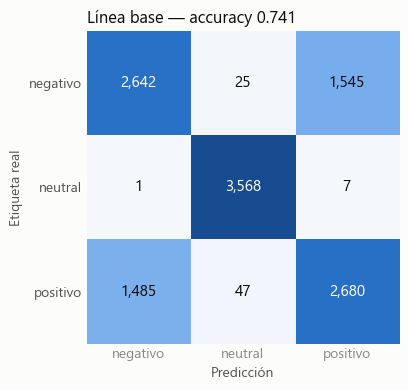

In [8]:
def graficar_confusion(ax, y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, labels=CLASES)
    ax.imshow(cm, cmap=RAMPA_AZUL, vmin=0, vmax=cm.sum(1).max())
    for i in range(3):
        for j in range(3):
            oscuro = cm[i, j] > 0.55 * cm.sum(1).max()
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11, color='white' if oscuro else TINTA)
    ax.set_xticks(range(3), CLASES); ax.set_yticks(range(3), CLASES)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')
    ax.set_title(titulo, color=TINTA)
    ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

fig, ax = plt.subplots(figsize=(4.6, 4))
graficar_confusion(ax, y, pred_base, f'Línea base — accuracy {accuracy_score(y, pred_base):.3f}')
plt.tight_layout(); plt.show()

**Diagnóstico:** la clase `neutral` está prácticamente resuelta (~99.8 % de recall), pero entre `positivo` y `negativo` la línea base acierta solo ≈63 %. Casi todo el error son confusiones positivo↔negativo en **reseñas mixtas**: la bolsa de palabras ve *"excelente"* y *"pésimo"* a la vez y no sabe cuál pesa más, porque descarta el orden.

## 5. Análisis del error: ¿qué opinión decide la etiqueta?
Para entender la regla que siguen las reseñas mixtas:
1. Partimos cada reseña en **cláusulas** (oraciones, y dentro de ellas en *", pero"*, *", aunque"*, *", y"*, …).
2. Entrenamos, dentro de cada fold y sin mirar el fold de validación, dos modelos auxiliares a nivel de documento: un **detector de opinión** (reseña polar frente a neutral) y un **modelo de polaridad** (positivo frente a negativo). Aplicados a cada cláusula, indican cuáles expresan opinión y con qué signo.
3. En las reseñas con opiniones de signo contrario medimos con qué frecuencia la etiqueta coincide con la **primera** opinión, con la **última** o con la **más intensa**, según el conector que introduce la última opinión.

In [9]:
FUERTES = ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
           'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
           'ahora bien', 'aunque']                        # conectores adversativos "fuertes"
DEBILES = ['eso si', 'igual', 'total', 'en fin', 'en cambio']   # adversativos "débiles"
ADITIVOS = ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'y']

def oraciones(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t) if s] or ['']

RE_CLAUSULA = re.compile(r',\s*(?=(?:pero|aunque|y|eso si|en cambio|sin embargo|mientras que|aun asi)\b)|;\s*')
def clausulas(t):
    return [p.strip() for s in oraciones(t) for p in RE_CLAUSULA.split(s) if p.strip()]

RE_CONECTOR = re.compile(r'\b(' + '|'.join(re.escape(c) for c in sorted(FUERTES + DEBILES + ADITIVOS, key=len, reverse=True)) + r')\b')
def conector_de(clausula):
    m = RE_CONECTOR.search(clausula[:45])
    return m.group(1) if m else '(sin conector)'

def grupo_de(conector):
    if conector in FUERTES: return 'adversativo fuerte'
    if conector in DEBILES: return 'adversativo débil'
    return 'aditivo / sin conector'

print(f'{len(FUERTES)} conectores adversativos fuertes, {len(DEBILES)} débiles y {len(ADITIVOS)} aditivos')

15 conectores adversativos fuertes, 5 débiles y 7 aditivos


In [10]:
Xn = np.array([normalizar(t) for t in X])
filas = []
for tr_idx, va_idx in CV.split(Xn, y):
    v_op = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    detector = LogisticRegression(C=5, max_iter=5000).fit(v_op.fit_transform(Xn[tr_idx]), y[tr_idx] != 'neutral')
    polares = tr_idx[y[tr_idx] != 'neutral']
    v_pol = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    polaridad = LogisticRegression(C=5, max_iter=5000).fit(v_pol.fit_transform(Xn[polares]), y[polares] == 'positivo')

    idx = [i for i in va_idx if y[i] != 'neutral']
    cls = [clausulas(Xn[i]) for i in idx]
    planas = [c for cc in cls for c in cc]
    s_op = detector.decision_function(v_op.transform(planas)) - detector.intercept_[0]
    s_pol = polaridad.decision_function(v_pol.transform(planas))
    k = 0
    for i, cc in zip(idx, cls):
        so, spol = s_op[k:k + len(cc)], s_pol[k:k + len(cc)]; k += len(cc)
        ops = [(c, p) for c, o, p in zip(cc, so, spol) if o > 3]          # cláusulas con opinión
        if len(ops) < 2 or np.sign(ops[0][1]) == np.sign(ops[-1][1]) or min(abs(ops[0][1]), abs(ops[-1][1])) < 1:
            continue                                                    # solo reseñas mixtas claras
        es_pos = y[i] == 'positivo'
        mas_intensa = ops[0][1] if abs(ops[0][1]) > abs(ops[-1][1]) else ops[-1][1]
        con = conector_de(ops[-1][0])
        filas.append(dict(conector=con, grupo=grupo_de(con), primera=es_pos == (ops[0][1] > 0),
                          ultima=es_pos == (ops[-1][1] > 0), intensa=es_pos == (mas_intensa > 0)))

mixtas = pd.DataFrame(filas)
print(f'Reseñas mixtas analizadas: {len(mixtas)} de {(y != "neutral").sum()} polares\n')
agg = dict(n=('ultima', 'size'), etiqueta_igual_primera=('primera', 'mean'),
           etiqueta_igual_ultima=('ultima', 'mean'), etiqueta_igual_mas_intensa=('intensa', 'mean'))
por_grupo = mixtas.groupby('grupo').agg(**agg).round(3)
por_conector = mixtas.groupby(['conector', 'grupo']).agg(**agg).query('n >= 12').sort_values('etiqueta_igual_ultima', ascending=False).round(3)
display(por_grupo)
display(por_conector)

Reseñas mixtas analizadas: 1701 de 8424 polares



,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
grupo,,,,
aditivo / sin conector,1039,0.480,0.520,0.494
adversativo débil,387,0.388,0.612,0.545
adversativo fuerte,275,0.084,0.916,0.636


,,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
conector,grupo,,,,
con todo,adversativo fuerte,23,0.043,0.957,0.522
pero al final,adversativo fuerte,20,0.050,0.950,1.000
aun asi,adversativo fuerte,78,0.051,0.949,0.513
pero,adversativo fuerte,64,0.094,0.906,0.797
aunque,adversativo fuerte,32,0.094,0.906,0.688
al final,adversativo fuerte,21,0.143,0.857,0.571
lo que si,adversativo fuerte,16,0.188,0.812,0.688
igual,adversativo débil,16,0.250,0.750,0.750
y,aditivo / sin conector,48,0.292,0.708,0.438


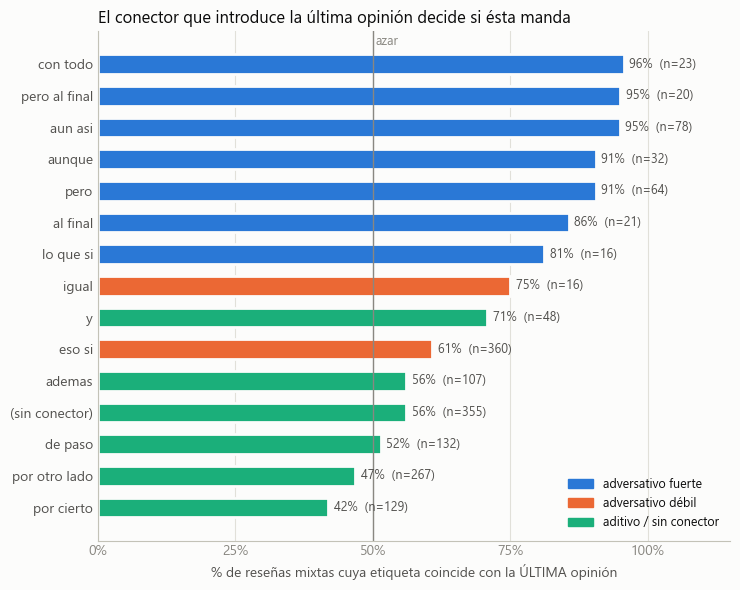

In [11]:
COLOR_GRUPO = {'adversativo fuerte': AZUL, 'adversativo débil': NARANJA, 'aditivo / sin conector': AQUA}
d = por_conector.reset_index().sort_values('etiqueta_igual_ultima')
fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(d) + 1.2))
ax.barh(d.conector, 100 * d.etiqueta_igual_ultima, height=0.62, color=[COLOR_GRUPO[g] for g in d.grupo],
        edgecolor=SUPERFICIE, linewidth=2)
for yy, (v, n) in enumerate(zip(d.etiqueta_igual_ultima, d.n)):
    ax.text(100 * v + 1, yy, f'{100 * v:.0f}%  (n={n})', va='center', fontsize=9, color=TINTA2)
ax.axvline(50, color=TENUE, linewidth=1)
ax.text(50.5, len(d) - 0.4, 'azar', color=TENUE, fontsize=9)
ax.set_xlim(0, 115); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('El conector que introduce la última opinión decide si ésta manda', color=TINTA)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_GRUPO.values()], labels=list(COLOR_GRUPO),
          loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Hallazgos:**
- Con un **conector adversativo fuerte** (*con todo, aun así, pero al final, aunque, pero…*) la etiqueta sigue a la **última** opinión en el 92 % de los casos: es la regla de *recencia* que menciona el enunciado.
- Con *"eso sí"* (el conector más frecuente) la última opinión gana solo el 61 % de las veces.
- Con conectores **aditivos** (*por otro lado, además, de paso, por cierto*) o sin conector, la etiqueta coincide con la primera opinión el 48 % de las veces, con la última el 52 % y con la más intensa el 49 %: con este detector de cláusulas **no aparece ninguna señal de orden**.

**Consecuencias para el modelado:**
1. La representación debe saber **dónde** aparece cada palabra: antes o después del último conector adversativo, y si está en la última oración (sección 6).
2. Una parte de las reseñas mixtas parece impredecible. En la sección 9, con un análisis más fino de las plantillas, veremos que la explicación no es el conector sino el **tipo de opinión**, y cuantificaremos el ruido irreducible.

## 6. Representación consciente del orden: bloques de texto
El transformador `Bloques` (sin parámetros entrenables) convierte cada reseña en varias "vistas" del texto, y **cada bloque se vectoriza por separado con TF-IDF**. Así la misma palabra pesa distinto según dónde aparece: *"pésimo"* en el segmento que sigue a *"aun así"* pesa mucho más que *"pésimo"* antes del conector.

| Bloque | Contenido |
|---|---|
| `completo` | toda la reseña normalizada (bolsa de palabras clásica) |
| `post` | desde el **último conector adversativo** (fuerte o débil) hasta el final |
| `post_fuerte` | desde el último conector adversativo **fuerte** hasta el final |
| `post_debil` | desde el último conector adversativo **débil** (*eso sí, igual…*) hasta el final |
| `ultima` | la última oración |
| `penultima` | la penúltima oración |

Sigue siendo una representación de bolsa de palabras y n-gramas: solo cambia **qué fragmento** se vectoriza.

In [12]:
def _regex_conectores(lista):
    # Conector al inicio del texto o después de un signo de puntuación
    return re.compile(r'(?:^|(?<=[.!?,;])\s*)(?:' + '|'.join(re.escape(c) for c in sorted(lista, key=len, reverse=True)) + r')\b')

RE_FUERTE, RE_DEBIL, RE_ADVERSATIVO = _regex_conectores(FUERTES), _regex_conectores(DEBILES), _regex_conectores(FUERTES + DEBILES)

def desde_ultimo(texto, regex):
    # Fragmento desde la última aparición del conector hasta el final ('' si no hay conector)
    m = list(regex.finditer(texto))
    return texto[m[-1].start():] if m else ''


class Bloques(TransformerMixin, BaseEstimator):
    # Convierte textos crudos en un DataFrame con una columna de texto por bloque
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        T = [normalizar(t) for t in X]
        O = [oraciones(t) for t in T]
        return pd.DataFrame({
            'completo': T,
            'post': [desde_ultimo(t, RE_ADVERSATIVO) for t in T],
            'post_fuerte': [desde_ultimo(t, RE_FUERTE) for t in T],
            'post_debil': [desde_ultimo(t, RE_DEBIL) for t in T],
            'ultima': [o[-1] for o in O],
            'penultima': [o[-2] if len(o) > 1 else '' for o in O],
        })


ejemplo = train.text[2]
print(ejemplo, '\n')
Bloques().transform([ejemplo]).T.rename(columns={0: 'contenido'})

Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo. 



,contenido
completo,"lo pedi a mediados de mes y me llego en tres dias, en su caja normal sin nada fuera de lo comun. lo uso en la oficina casi a diario desde entonces. el diseno se sintio durable desde el primer dia...."
post,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_fuerte,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_debil,
ultima,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
penultima,el diseno se sintio durable desde el primer dia.


In [13]:
B = Bloques().transform(X)
print('% de reseñas con conector adversativo fuerte:', round(100 * (B.post_fuerte != '').mean(), 1))
print('% de reseñas con conector adversativo débil :', round(100 * (B.post_debil != '').mean(), 1))

% de reseñas con conector adversativo fuerte: 26.0
% de reseñas con conector adversativo débil : 17.6


## 7. Modelos base del ensemble v1
Todos se evalúan con la **misma** validación cruzada y guardamos sus probabilidades OOF para construir después el ensemble sin fuga de información.

- **`lr_palabras`**: TF-IDF de palabras (1-2 gramas) en los bloques `completo`, `post` y `ultima` + regresión logística.
- **`lr_pal_car`**: lo mismo con n-gramas de caracteres (`char_wb`, 2-5) en cada bloque: robusto a typos y tildes faltantes.
- **`svc_pal_car`**: misma representación con SVM lineal; `CalibratedClassifierCV` le da probabilidades para el voto suave.
- **`stacking`**: una regresión logística **por bloque** (los 6 bloques, palabras + caracteres) y un **HistGradientBoosting** como meta-clasificador sobre sus probabilidades. Al no ser lineal, el meta-modelo aprende reglas como *"si el bloque tras el conector fuerte es muy negativo, ignorar lo anterior"*. `StackingClassifier` genera internamente las predicciones de los modelos base por validación cruzada, así que el meta-modelo no ve predicciones sobreajustadas.

Los hiperparámetros (C de la regresión logística en {2, 5, 10, 20}, C del SVM en {0.1, 0.3, 1}, rangos de n-gramas, bloques) se eligieron con esta misma validación cruzada; una búsqueda aleatoria posterior de 87 configuraciones confirmó que ya eran óptimos (±0.1 pts).

In [14]:
def tfidf_palabras():
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)

def tfidf_caracteres():
    return TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3)

def vectorizar(bloques, vectorizadores):
    # Un vectorizador independiente por cada (bloque, tipo de n-grama)
    return ColumnTransformer([(f'{b}_{i}', v(), b) for b in bloques for i, v in enumerate(vectorizadores)])

BLOQUES_LINEALES = ['completo', 'post', 'ultima']
BLOQUES_STACKING = ['completo', 'post', 'post_fuerte', 'post_debil', 'ultima', 'penultima']

def modelo_lr_palabras():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])

def modelo_lr_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])

def modelo_svc_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', CalibratedClassifierCV(LinearSVC(C=0.3, random_state=SEED), cv=3))])

def modelo_stacking():
    por_bloque = [(b, Pipeline([('vec', vectorizar([b], [tfidf_palabras, tfidf_caracteres])),
                                ('clf', LogisticRegression(C=5, max_iter=5000))]))
                  for b in BLOQUES_STACKING]
    meta = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          early_stopping=False, random_state=0)
    return Pipeline([('bloques', Bloques()),
                     ('stack', StackingClassifier(por_bloque, final_estimator=meta, stack_method='predict_proba',
                                                  cv=StratifiedKFold(5, shuffle=True, random_state=1)))])

FABRICAS_V1 = {'stacking': modelo_stacking, 'lr_palabras': modelo_lr_palabras,
               'lr_pal_car': modelo_lr_pal_car, 'svc_pal_car': modelo_svc_pal_car}

pd.DataFrame({
    'bloques': [', '.join(BLOQUES_STACKING)] + [', '.join(BLOQUES_LINEALES)] * 3,
    'n-gramas': ['palabras 1-2 + caracteres 2-5', 'palabras 1-2', 'palabras 1-2 + caracteres 2-5',
                 'palabras 1-2 + caracteres 2-5'],
    'clasificador': ['6 LR (una por bloque) -> HistGradientBoosting', 'LogisticRegression(C=5)',
                     'LogisticRegression(C=5)', 'LinearSVC(C=0.3) calibrado'],
}, index=list(FABRICAS_V1))

,bloques,n-gramas,clasificador
stacking,"completo, post, post_fuerte, post_debil, ultima, penultima",palabras 1-2 + caracteres 2-5,6 LR (una por bloque) -> HistGradientBoosting
lr_palabras,"completo, post, ultima",palabras 1-2,LogisticRegression(C=5)
lr_pal_car,"completo, post, ultima",palabras 1-2 + caracteres 2-5,LogisticRegression(C=5)
svc_pal_car,"completo, post, ultima",palabras 1-2 + caracteres 2-5,LinearSVC(C=0.3) calibrado


In [15]:
OOF = {}            # probabilidades out-of-fold de cada componente con la partición 42
SEGUNDOS = {}
for nombre, fabrica in FABRICAS_V1.items():
    t0 = time.time()
    OOF[nombre] = cross_val_predict(fabrica(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
    SEGUNDOS[nombre] = time.time() - t0
    print(f'{nombre:12s} accuracy CV = {accuracy_score(y, CLASES[OOF[nombre].argmax(1)]):.4f}   ({SEGUNDOS[nombre]:.0f} s)')

def acc_oof(P):
    return accuracy_score(y, CLASES[np.asarray(P).argmax(1)])

stacking     accuracy CV = 0.9012   (136 s)


lr_palabras  accuracy CV = 0.8951   (5 s)


lr_pal_car   accuracy CV = 0.8981   (19 s)


svc_pal_car  accuracy CV = 0.8998   (16 s)


## 8. Ensemble v1: voto suave ponderado
El ensemble promedia las probabilidades de los modelos con pesos $w_i \ge 0$, $\sum_i w_i = 1$:

$$\hat{p}(c \mid x) = \sum_i w_i \, p_i(c \mid x), \qquad \hat{y} = \arg\max_c \hat{p}(c \mid x)$$

Buscamos los pesos en una **rejilla de paso 0.1** maximizando la accuracy de las probabilidades OOF. Como elegir pesos mirando esas mismas OOF puede sobreajustar, estimamos además la **accuracy con selección anidada**: elegimos los pesos con 4/5 de las filas OOF y medimos en el 1/5 restante (`StratifiedKFold(5, shuffle=True, random_state=123)` sobre las filas). Las funciones de esta celda se reutilizan con los 7 componentes de v3c en la sección 12.

In [16]:
# Herramientas para combinar modelos a partir de sus probabilidades OOF (se reutilizan en las secciones 12 y 13)
from functools import lru_cache


@lru_cache(maxsize=None)
def rejilla_pesos(k, paso=0.1):
    # Todas las combinaciones de k pesos múltiplos de `paso` que suman 1, en orden lexicográfico
    n = int(round(1 / paso))
    return np.array([c for c in itertools.product(range(n + 1), repeat=k) if sum(c) == n], dtype=float) / n


def apilar(P):
    nombres = list(P)
    return nombres, np.stack([np.asarray(P[n], dtype=float) for n in nombres])     # (k, N, 3)


def prob_ensemble(P, pesos):
    # Voto suave: suma ponderada de las probabilidades de los componentes
    nombres, A = apilar({n: P[n] for n in pesos})
    return np.tensordot(np.array([pesos[n] for n in nombres]), A, axes=1)


def mejores_pesos(P, y, filas=None, paso=0.1):
    """Combinación de la rejilla con mayor accuracy sobre las OOF (opcionalmente, solo en `filas`).
    Ante empates gana la primera en orden lexicográfico. Devuelve (pesos, accuracy, rejilla, accuracy de cada fila)."""
    nombres, A = apilar(P)
    yi = np.searchsorted(CLASES, y)
    if filas is not None:
        A, yi = A[:, filas], yi[filas]
    W = rejilla_pesos(len(nombres), paso)
    acc = np.array([(np.tensordot(w, A, axes=1).argmax(1) == yi).mean() for w in W])
    i = int(np.argmax(acc))
    return dict(zip(nombres, map(float, W[i]))), float(acc[i]), W, acc


def seleccion_anidada(P, y, semilla=123, paso=0.1):
    """Validación anidada de la selección de pesos: se eligen con 4/5 de las filas OOF y se mide la accuracy en el
    1/5 restante, 5 veces. Estima cuánto rinden los pesos elegidos en reseñas que no participaron en elegirlos."""
    filas = []
    for a, b in StratifiedKFold(5, shuffle=True, random_state=semilla).split(y, y):
        pesos, _, _, _ = mejores_pesos(P, y, a, paso)
        P_b = prob_ensemble({n: np.asarray(P[n])[b] for n in P}, pesos)
        filas.append({**pesos, 'accuracy_parte_no_vista': accuracy_score(y[b], CLASES[P_b.argmax(1)])})
    return pd.DataFrame(filas)


def mcnemar(pred_nuevo, pred_base, y):
    # Prueba exacta de McNemar (binomial de dos colas) sobre las reseñas en que los dos modelos discrepan en acierto
    a, b = (pred_nuevo == y), (pred_base == y)
    gana, pierde = int((a & ~b).sum()), int((~a & b).sum())
    n, k = gana + pierde, min(gana, pierde)
    p = min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0
    return dict(gana=gana, pierde=pierde, p=p)


def oof_por_fold(crear_modelo, X, y, cv, n_jobs=N_JOBS):
    """Igual que cross_val_predict(..., method='predict_proba'): para cada fold k entrena crear_modelo(k) con el
    resto de los datos y predice el fold. La única diferencia es que el modelo puede depender de k."""
    y_cod = LabelEncoder().fit(CLASES).transform(y)          # etiquetas 0/1/2, como hace cross_val_predict

    def un_fold(k, entrenamiento, validacion):
        modelo = crear_modelo(k).fit(X[entrenamiento], y_cod[entrenamiento])
        return validacion, modelo.predict_proba(X[validacion])

    P = np.zeros((len(y), len(CLASES)))
    tareas = (delayed(un_fold)(k, a, b) for k, (a, b) in enumerate(cv.split(X, y)))
    for validacion, Pk in Parallel(n_jobs=n_jobs)(tareas):
        P[validacion] = Pk
    return P


print(f'Rejilla de paso 0.1: {len(rejilla_pesos(4))} combinaciones con 4 componentes y {len(rejilla_pesos(6))} con 6')

Rejilla de paso 0.1: 286 combinaciones con 4 componentes y 3003 con 6


In [17]:
NOMBRES_V1 = list(FABRICAS_V1)
aciertos = pd.DataFrame({n: CLASES[OOF[n].argmax(1)] == y for n in NOMBRES_V1})
print('Correlación de aciertos entre modelos (más baja = más complementarios):')
display(aciertos.corr().round(2))

OOF_V1 = {n: OOF[n] for n in NOMBRES_V1}
pesos_v1, oof_v1, W4, acc_W4 = mejores_pesos(OOF_V1, y)
mejores = np.argsort(-acc_W4, kind='stable')[:10]
print(f'Combinaciones evaluadas: {len(W4)}. Las 10 mejores:')
display(pd.DataFrame(W4[mejores], columns=NOMBRES_V1).assign(accuracy_oof=acc_W4[mejores].round(4)))

Correlación de aciertos entre modelos (más baja = más complementarios):


,stacking,lr_palabras,lr_pal_car,svc_pal_car
stacking,1.00,0.54,0.56,0.56
lr_palabras,0.54,1.00,0.82,0.82
lr_pal_car,0.56,0.82,1.00,0.86
svc_pal_car,0.56,0.82,0.86,1.00


Combinaciones evaluadas: 286. Las 10 mejores:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_oof
0,0.5,0.4,0.0,0.1,0.9069
1,0.5,0.3,0.1,0.1,0.9067
2,0.5,0.3,0.0,0.2,0.9066
3,0.5,0.4,0.1,0.0,0.9063
4,0.5,0.5,0.0,0.0,0.9063
5,0.5,0.2,0.2,0.1,0.9060
6,0.5,0.2,0.0,0.3,0.9058
7,0.5,0.3,0.2,0.0,0.9058
8,0.6,0.4,0.0,0.0,0.9058
9,0.5,0.2,0.1,0.2,0.9057


In [18]:
anidado_v1 = seleccion_anidada(OOF_V1, y)
display(anidado_v1.round(4))
pred_v1 = CLASES[prob_ensemble(OOF_V1, pesos_v1).argmax(1)]

PESOS_ENVIADOS = {'stacking': 0.5, 'lr_palabras': 0.1, 'lr_pal_car': 0.3, 'svc_pal_car': 0.1}   # submission.csv
oof_v1_enviado = acc_oof(prob_ensemble(OOF_V1, PESOS_ENVIADOS))
print(f'Ensemble v1: accuracy OOF {oof_v1:.4f} con pesos {pesos_v1}')
print(f'             selección de pesos anidada {anidado_v1.accuracy_parte_no_vista.mean():.4f}')
print(f'Pesos del modelo enviado a Kaggle {PESOS_ENVIADOS}: accuracy OOF {oof_v1_enviado:.4f}')

,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_parte_no_vista
0,0.5,0.4,0.0,0.1,0.9029
1,0.5,0.4,0.0,0.1,0.9108
2,0.5,0.3,0.1,0.1,0.9071
3,0.5,0.4,0.0,0.1,0.9129
4,0.5,0.4,0.0,0.1,0.8996


Ensemble v1: accuracy OOF 0.9069 con pesos {'stacking': 0.5, 'lr_palabras': 0.4, 'lr_pal_car': 0.0, 'svc_pal_car': 0.1}
             selección de pesos anidada 0.9067
Pesos del modelo enviado a Kaggle {'stacking': 0.5, 'lr_palabras': 0.1, 'lr_pal_car': 0.3, 'svc_pal_car': 0.1}: accuracy OOF 0.9054


**Interpretación:** la superficie de pesos es muy plana: las 10 mejores combinaciones difieren en apenas 0.12 puntos y la selección anidada (0.9067) queda prácticamente igual que la accuracy OOF (0.9069). El modelo enviado a Kaggle (`submission.csv`, **0.90111** en la tabla pública) usaba los pesos 0.5 / 0.1 / 0.3 / 0.1, elegidos en una ejecución anterior; con las OOF de esta ejecución esos pesos dan 0.9054, la misma accuracy dentro del ruido.

**Nota sobre reproducibilidad numérica.** Con el mismo código y la misma partición, la accuracy OOF del stacking fue 0.8973 en el notebook de v1 (`modelo_sentimiento.ipynb`, sin fijar hilos), 0.8983 con 6 hilos de BLAS por proceso y 0.9012 aquí (4 hilos). Lo comprobamos aparte: con 6 hilos la OOF se reproduce exactamente, predicción por predicción. No es un error sino sensibilidad numérica: el meta-HistGradientBoosting corta sobre probabilidades de regresiones logísticas cuyos coeficientes cambian en el último bit, y unas pocas reseñas cerca de un umbral cambian de lado. La consecuencia práctica es que las diferencias de hasta 3-4 décimas entre ensembles son del orden de este ruido; la mejora de v3b frente a v1 (≈ +1 punto) es bastante mayor.

¿Dónde se equivoca v1? Agrupando las reseñas por el tipo de conector:

In [19]:
tipo = np.select([y == 'neutral', B.post_fuerte != '', B.post_debil != '',
                  B.completo.str.contains(r'\b(?:por otro lado|por otra parte|ademas|de paso|por cierto|tambien)\b')],
                 ['neutral', 'con adversativo fuerte', 'con adversativo débil (eso sí…)', 'con conector aditivo'],
                 default='sin conector')
pd.DataFrame({'tipo': tipo, 'base': pred_base == y, 'v1': pred_v1 == y}).groupby('tipo').agg(
    n=('base', 'size'), acc_linea_base=('base', 'mean'), acc_ensemble_v1=('v1', 'mean'),
    errores_v1=('v1', lambda s: int((~s).sum()))).round(3).sort_values('acc_ensemble_v1', ascending=False)

,n,acc_linea_base,acc_ensemble_v1,errores_v1
tipo,,,,
neutral,3576,0.998,0.997,9
con adversativo fuerte,2917,0.585,0.971,85
sin conector,2650,0.737,0.892,285
con adversativo débil (eso sí…),1657,0.566,0.804,325
con conector aditivo,1200,0.604,0.656,413


v1 resuelve casi por completo las reseñas con conector adversativo fuerte y las neutrales. Los ~1 100 errores restantes se concentran en reseñas con *"eso sí"*, con conectores aditivos o sin conector. La siguiente sección explica por qué.

## 9. Hallazgo: dos familias de plantillas
Leyendo cientos de errores de v1 se ve que el corpus es **sintético**: cada reseña combina frases de relleno (envío, peso, garantía, *"la verdad"*) con 1-3 opiniones, y las opiniones salen de **dos plantillas** distintas:

| Familia | Forma | Ejemplos |
|---|---|---|
| **A** (adjetival) | *[aspecto] + verbo copulativo + (modificador) + ADJETIVO* | *"la batería se mantuvo buenísima"*, *"la portabilidad se ve floja"*, *"el diseño se sintió durable"* |
| **B** (frase hecha) | expresión fija sobre el producto | *"superó todas mis expectativas"*, *"no vale lo que cuesta"*, *"fue todo un acierto"* |

Para medir qué decide la etiqueta escribimos un **parser determinista** de esas plantillas (dos celdas siguientes): un inventario hecho a mano de verbos copulativos, adjetivos (con modificadores y negación: *"poco fiable"*, *"no es cómodo"*), frases hechas, conectores y cierres ambivalentes (*"cada quien que juzgue"*, *"ni fu ni fa"*), más un **corrector de typos** por distancia de edición. Este mismo parser es la base del componente `estructural` (sección 10) y de su versión robusta (sección 10.1), que le añade tres reglas genéricas del español.

En esta sección lo usamos solo para **describir** los datos: la polaridad de cada opinión es la semántica del inventario (prefijo `p_`/`a+` positivo, `n_`/`a-` negativo) y el corrector solo cuenta palabras, así que el análisis no ajusta nada a las etiquetas.

In [20]:
# ---------------------------------------------------------------- corrector de typos (se ajusta en cada fold)
LETRAS = 'abcdefghijklmnopqrstuvwxyzñ'


def _ediciones1(w):
    # Todas las cadenas a distancia de edición 1 de w: borrado, transposición, sustitución e inserción
    cortes = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transpuestos = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituidos = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    insertados = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transpuestos + sustituidos + insertados)


class CorrectorTypos:
    """Cambia cada palabra rara (< min_frec apariciones en los textos de entrenamiento, más de 3 letras) por la
    palabra frecuente más común a distancia de edición 1: 'lleego' -> 'llego', 'epsectacular' -> 'espectacular'."""

    def __init__(self, min_frec=5):
        self.min_frec = min_frec

    def fit(self, textos_normalizados):
        self.frecuencia = collections.Counter(w for t in textos_normalizados for w in re.findall(r'[a-zñ]+', t))
        self.vocabulario = {w for w, k in self.frecuencia.items() if k >= self.min_frec}
        self.cache = {}
        return self

    def palabra(self, w):
        if w in self.vocabulario or len(w) <= 3:
            return w
        if w not in self.cache:
            # candidatas en orden alfabético: el desempate entre frecuencias iguales no depende del azar del hash
            candidatas = sorted(v for v in _ediciones1(w) if v in self.vocabulario)
            self.cache[w] = max(candidatas, key=lambda v: self.frecuencia[v]) if candidatas else w
        return self.cache[w]

    def transform(self, texto):
        return re.sub(r'[a-zñ]+', lambda m: self.palabra(m.group()), texto)


# ---------------------------------------------------------------- inventario de las plantillas (escrito a mano)
# Plantilla A: "[aspecto] + verbo copulativo + (modificador) + ADJETIVO", p. ej. "la batería se mantuvo buenísima"
COPULAS = ['me parecio', 'me resulto ser', 'me resulto', 'resulto ser', 'resulto', 'quedo', 'se ve', 'se siente',
           'se sintio', 'se mantuvo', 'termino siendo', 'luce', 'es', 'esta', 'fue', 'me salio', 'salio',
           'me quedo', 'anda', 'se nota', 'se volvio', 'funciona', 'sigue siendo', 'sigue', 'me parece', 'parece',
           'me ha parecido', 'se ha mantenido', 'me termino pareciendo', 'termino pareciendo', 'vino', 'me resulta',
           'resulta', 'queda', 'se sigue viendo', 'estuvo']
ADJETIVOS_POS = ['robust[oa]', 'correct[oa]', 'nitid[oa]', 'impecable', 'liger[oa]', 'sobresaliente', 'optim[oa]',
                 'redond[oa]', 'durable', 'resistente', 'excelente', 'espectacular', 'comodisim[oa]', 'superior',
                 'decente', 'potente', 'agradable', 'estupend[oa]', 'eficiente', 'fiable', 'practic[oa]', 'solid[oa]',
                 'buenisim[oa]', 'precis[oa]', 'confiable', 'cumplidor[a]?', 'formidable', 'comod[oa]',
                 'rapidisim[oa]', 'veloz', 'funcional', 'complet[oa]', 'buen[oa]', 'notable', 'bien hech[oa]',
                 'bien lograd[oa]', 'bien construid[oa]', 'bien terminad[oa]', 'lograd[oa]', 'de maravilla', 'genial',
                 'perfect[oa]', 'ideal', 'brillante', 'increible', 'fantastic[oa]', 'bien', 'de buena calidad',
                 'de calidad', 'muy buen[oa]']
ADJETIVOS_NEG = ['defectuos[oa]', 'imprecis[oa]', 'ordinari[oa]', 'incomod[oa]', 'chapucer[oa]', 'aparatos[oa]',
                 'terrible', 'inconsistente', 'malisim[oa]', 'floj[oa]', 'pobre', 'olvidable', 'debil',
                 'lentisim[oa]', 'limitad[oa]', 'inestable', 'torpe', 'deficiente', 'delicad[oa]', 'mediocre',
                 'basic[oa]', 'pesim[oa]', 'fragil', 'ruidos[oa]', 'incumplidor[a]?', 'desagradable', 'corriente',
                 'endeble', 'decepcionante', 'mal hech[oa]', 'mal terminad[oa]', 'mal construid[oa]', 'horrible',
                 'bastante mal', 'mal', 'lent[oa]', 'malo', 'mala', 'de mala calidad', 'de lo peor']
MODIFICADORES = r'(?:(?P<mod>muy|bastante|demasiado|super|algo|un poco|poco|nada|tan|re)\s+)?'
RE_ADJETIVO = re.compile(r'\b(?P<cop>' + '|'.join(sorted(COPULAS, key=len, reverse=True)) + r')\s+' + MODIFICADORES +
                         r'(?P<adj>' + '|'.join(sorted(ADJETIVOS_POS + ADJETIVOS_NEG, key=len, reverse=True)) + r')\b')
RE_ADJETIVO_POSITIVO = re.compile(r'^(?:' + '|'.join(ADJETIVOS_POS) + r')$')

# Plantilla B: frases hechas. El prefijo p_/n_ es su polaridad semántica (solo respaldo: la polaridad que usa el
# modelo se aprende en cada fold con las reseñas de entrenamiento que tienen una sola opinión).
FRASES_FIJAS = {
    'p_cumple_sobra': r'cumple de sobra',
    'p_vida_facil': r'me hizo la vida (?:mas|muy) facil',
    'p_sorprendio_bien': r'me sorprendio para bien',
    'p_cada_peso': r'cada peso que pague por .{0,40}? valio la pena|cada peso que pague valio la pena|valio cada peso',
    'p_me_encanto': r'\bme encanto\b|\bme encantaron\b',
    'p_feliz': r'\bestoy feliz con|\btermine feliz con|\bquede feliz con|me tiene feliz|me dejo feliz|estoy feliz|sigo estando feliz|feliz con',
    'p_contento': r'me tiene content[oa]|me dejo content[oa]|muy content[oa]|quede content[oa]|estoy content[oa]',
    'p_satisfecho': r'mas que satisfech[oa]|quede satisfech[oa]|muy satisfech[oa]',
    'p_repetiria': r'repetiria la compra',
    'p_recomiendo_sin': r'l[oa] recomiendo sin (?:pensarlo|dudarlo)|recomiendo .{0,30}?sin dudarlo',
    'p_mucho_mejor': r'mucho mejor de lo que',
    'p_me_alegra': r'me alegra haber elegido|me alegra haberl[oa] elegido|me alegra haberl[oa] comprado',
    'p_tal_como': r'respondio tal como esperaba|tal como esperaba',
    'p_sola_queja': r'ni una sola queja',
    'p_supero': r'supero todas mis expectativas|supero mis expectativas',
    'p_vale_pena': r'vale totalmente la pena|vale la pena',
    'p_cinco_estrellas': r'cinco estrellas',
    'p_ojos_cerrados': r'con los ojos cerrados',
    'p_encantado': r'quede encantad[oa] con|quede encantad[oa]|quedo encantad[oa]|me quedo encantad[oa]',
    'p_sin_pensarlo': r'volveria a comprar\w* .{0,40}?sin pensarlo|volveria a comprar\w* sin pensarlo|sin pensarlo dos veces',
    'p_justo_buscando': r'justo lo que (?:estaba buscando|buscaba|necesitaba)',
    'p_acierto': r'todo un acierto',
    'p_encima_media': r'por encima de la media',
    'p_maravilla': r'funciona de maravilla|de maravilla',
    'p_dejo_encantado': r'me dejo encantad[oa]|me tiene encantad[oa]',
    'p_volvi_comprar': r'volvi a comprar',
    'p_con_creces': r'cumple con creces|con creces',
    'p_ni_una_queja': r'ni una queja|una sola queja|no tengo queja|no me quejo',
    'p_me_gusto': r'me gusto (?:bastante|mucho)|me gustaron|me termino gustando|termino gustandome|si me gusto|me gusto',
    'n_no_vale': r'no vale lo que cuesta',
    'n_dolor_cabeza': r'mas de un dolor de cabeza|dolor de cabeza',
    'n_para_nada': r'no es para nada lo que esperaba|para nada lo que esperaba',
    'n_se_dano': r'se dano antes de lo que esperaba|se dano',
    'n_defraudo': r'defraudo todas mis expectativas|defraudo',
    'n_tire_dinero': r'tire el dinero',
    'n_decepciono': r'me decepciono|me decepcionaron',
    'n_me_arrepiento': r'me arrepiento de haber|me arrepiento es de haber|me arrepenti de haber\w*',
    'n_arrepentido': r'arrepentid[oa] de haber',
    'n_problemas': r'no pare de tener problemas|no para de darme problemas|no paro de darme problemas|me ha dado problemas',
    'n_no_convencio': r'no me convencio|no me convence|no me termino de convencer',
    'n_mal_rato': r'mas de un mal rato',
    'n_debajo_aceptable': r'por debajo de lo aceptable',
    'n_peor_parece': r'las cosas que peor',
    'n_molesto': r'quede muy molest[oa]|quede molest[oa]',
    'n_no_recomiendo': r'no l[oa] le recomiendo|no le recomiendo|no se l[oa]s? recomiendo|no l[oa] recomiendo|no se l[oa]s? recomendaria|recomendaria a nadie',
    'n_dejo_molesto': r'me dejo (?:muy )?molest[oa]',
    'n_complicaciones': r'me trajo complicaciones|me dio problemas|dio problemas|me trajo problemas',
    'n_no_funciono': r'no me funciono como esperaba|nunca me funciono como esperaba',
    'n_desilusiono': r'me desilusiono',
    'n_fue_error': r'fue un error',
    'n_una_estrella': r'una sola estrella|una estrella',
    'n_queda_corto': r'se queda muy cort[oa]|se queda cort[oa]',
    'n_ni_regalado': r'ni regalad[oa]|ni aunque me l[oa] regal\w*|ni me l[oa] regalaron',
    'n_harto': r'termine hart[oa]|quede hart[oa]|termino hart[oa]',
    'n_error_compra': r'un error de compra',
    'n_debajo_media': r'por debajo de la media',
    'n_bastante_mal': r'funciona bastante mal',
    'n_no_gusto': r'no me gusto nada|no me gusto',
    'n_de_lo_peor': r'de lo peor',
}
RE_FRASES_FIJAS = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in FRASES_FIJAS.items()]

# Cierres ambivalentes: frases que dejan la decisión al lector (se buscan después de la última opinión)
CIERRES_AMBIVALENTES = {
    'c_juzgue': r'cada quien que juzgue|que cada quien juzgue|cada quien juzgue',
    'c_gustos': r'para gustos,? colores',
    'c_dudas': r'sigo con (?:dudas|la duda)|con la duda|me quede con la duda|sigo dudando|dudando',
    'c_fufa': r'ni fu ni fa',
    'c_criterio_cada': r'a criterio de cada uno',
    'c_criterio_tu': r'a tu criterio|a su criterio|a criterio',
    'c_no_sabria': r'no sabria (?:bien )?que (?:recomendar|pensar|decir)|no se bien que (?:pensar|decir|recomendar)|no se que (?:pensar|decir)',
    'c_hay_todo': r'hay de todo',
    'c_sopesalo': r'sopesalo|sopesenlo',
    'c_no_decido': r'no me decido|no me termino de decidir|sin decidirme|no termino de decidir',
    'c_mejor_peor': r'ni lo mejor ni lo peor',
    'c_bueno_malo': r'ni tan bueno ni tan malo',
    'c_ahi_dejo': r'ahi lo dejo|ahi queda',
    'c_sentimientos': r'sentimientos encontrados',
    'c_conclusiones': r'sacara sus conclusiones|saque sus conclusiones|sus propias conclusiones',
    'c_otras_no': r'otras no|lo uno y lo otro|unas cosas? (?:buenas?|mejor)|unos detalles mejor que otros',
    'c_vueltas': r'dandole vueltas|vuelta al asunto',
}
RE_CIERRES = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in CIERRES_AMBIVALENTES.items()]

# Conectores que introducen una opinión (se buscan en el contexto inmediatamente anterior)
CONECTORES_PLANTILLA = {
    'fuerte': ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
               'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
               'ahora bien', 'aunque', 'el detalle es que', 'lo curioso es que', 'mientras que', 'eso no quita'],
    'debil': ['eso si', 'igual', 'total', 'en fin', 'en cambio', 'ahora'],
    'aditivo': ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'aparte',
                'encima', 'y'],
}
_LISTA_CONECTORES = sorted([(c, t) for t, cs in CONECTORES_PLANTILLA.items() for c in cs], key=lambda x: -len(x[0]))
RE_CONECTOR_PLANTILLA = re.compile(r'\b(' + '|'.join(re.escape(c) for c, _ in _LISTA_CONECTORES) + r')\b')
TIPO_CONECTOR_PLANTILLA = {c: t for c, t in _LISTA_CONECTORES}


print(f'Inventario: {len(COPULAS)} verbos copulativos, {len(ADJETIVOS_POS)} + {len(ADJETIVOS_NEG)} adjetivos (+/-), '
      f'{len(FRASES_FIJAS)} frases hechas, {len(CIERRES_AMBIVALENTES)} tipos de cierre ambivalente, '
      f'{len(TIPO_CONECTOR_PLANTILLA)} conectores')

Inventario: 36 verbos copulativos, 50 + 40 adjetivos (+/-), 59 frases hechas, 17 tipos de cierre ambivalente, 34 conectores


In [21]:
def oraciones_plantilla(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t.strip()) if s] or ['']


# Cortes dentro de una oración: comas, punto y coma, ' y ' seguido de un nuevo sujeto, y antes de pero/aunque
RE_FRAGMENTO = re.compile(r',\s+|;\s+|\s+y\s+(?=(?:el|la|los|las|lo|le|me|no|estoy|quede|siento|termine|recomiendo|'
                          r'volveria|cada|ni)\b)|\s+(?=(?:pero|aunque|mientras que|sin embargo)\b)')


def fragmentos_oracion(s):
    # Lista de (inicio, fin, separador previo) de los fragmentos de una oración
    salida, pos, sep = [], 0, ''
    for m in RE_FRAGMENTO.finditer(s):
        salida.append((pos, m.start(), sep))
        sep = m.group(0).strip() or ' '
        pos = m.end()
    salida.append((pos, len(s), sep))
    return [(a, b, sp) for a, b, sp in salida if s[a:b].strip(' .!?')]


def opiniones_fragmento(f):
    # Núcleos de opinión (clave, inicio, fin) de un fragmento, sin solapes; ante empate gana el más largo
    hallazgos = []
    for clave, rx in RE_FRASES_FIJAS:
        for m in rx.finditer(f):
            hallazgos.append((clave, m.start(), m.end()))
    for m in RE_ADJETIVO.finditer(f):
        adj = m.group('adj')
        # 'bien'/'mal' solos no cuentan tras es/está/fue/sigue (evita 'está bien empacado')
        if adj in ('bien', 'mal') and m.group('cop') in ('es', 'esta', 'fue', 'sigue'):
            continue
        signo = 'a+' if RE_ADJETIVO_POSITIVO.match(adj) else 'a-'
        mod = m.group('mod') or ''
        if mod in ('poco', 'nada'):                                     # 'poco fiable' invierte la polaridad
            signo = 'a-' if signo == 'a+' else 'a+'
        elif re.search(r'\bno\s+$', f[max(0, m.start() - 4):m.start()]):  # negación justo antes: 'no es cómodo'
            signo = 'a-' if signo == 'a+' else 'a+'
            mod = 'no'
        base = re.sub(r'[oa]$', '', adj) if ' ' not in adj else adj    # sin género: 'robust'
        hallazgos.append((f'{signo}:{mod + " " if mod in ("poco", "nada", "no") else ""}{base}', m.start(), m.end()))
    hallazgos.sort(key=lambda h: (h[1], -(h[2] - h[1])))
    salida, fin = [], -1
    for h in hallazgos:
        if h[1] >= fin:
            salida.append(h)
            fin = h[2]
    return salida


def analizar_resena(t, detectar_opiniones=opiniones_fragmento):
    """t: texto normalizado y corregido. Devuelve las oraciones, la lista de opiniones (en orden) y el cierre.
    detectar_opiniones: fragmento -> núcleos de opinión (la sección 10.1 pasa la versión robusta)."""
    S = oraciones_plantilla(t)
    opiniones = []
    for si, s in enumerate(S):
        fin_anterior = 0
        for a, b, sep in fragmentos_oracion(s):
            f = s[a:b]
            nucleos = detectar_opiniones(f)
            if not nucleos:
                continue
            # varios núcleos en un mismo fragmento -> una opinión por núcleo (el fragmento se reparte)
            for j, (clave, ca, cb) in enumerate(nucleos):
                nb = nucleos[j + 1][1] if j + 1 < len(nucleos) else len(f)
                pa = nucleos[j - 1][2] if j > 0 else 0
                opiniones.append(dict(oracion=si, clave=clave, nucleo=f[ca:cb], inicio_fragmento=f[pa:ca],
                                      resto_fragmento=f[cb:nb], separador=sep if j == 0 else 'y',
                                      antes=s[fin_anterior:a] if j == 0 else '', ini=a + pa, fin=a + nb, oracion_texto=s))
            fin_anterior = b
    for j, o in enumerate(opiniones):
        # contexto posterior: desde el fin de la opinión hasta la siguiente opinión de la misma oración
        sig = opiniones[j + 1] if j + 1 < len(opiniones) and opiniones[j + 1]['oracion'] == o['oracion'] else None
        o['despues'] = o['oracion_texto'][o['fin']:(sig['ini'] if sig else len(o['oracion_texto']))]
        # conector: el último que aparece en el contexto inmediatamente anterior a la opinión
        conectores = RE_CONECTOR_PLANTILLA.findall(o['antes'] + ' ' + o['inicio_fragmento'] + ' ' + o['separador'])
        o['conector'] = conectores[-1] if conectores else ''
        o['tipo_conector'] = TIPO_CONECTOR_PLANTILLA.get(o['conector'], 'ninguno')
    # cierre ambivalente en una oración posterior a la última opinión...
    ultima_oracion = opiniones[-1]['oracion'] if opiniones else -1
    cierre, cierre_oracion = '', -1
    for si in range(len(S) - 1, ultima_oracion, -1):
        for clave, rx in RE_CIERRES:
            if rx.search(S[si]):
                cierre, cierre_oracion = clave, si
                break
        if cierre:
            break
    # ... o dentro de la misma oración, después de la última opinión
    cierre_en_linea = ''
    if opiniones and not cierre:
        for clave, rx in RE_CIERRES:
            if rx.search(opiniones[-1]['despues']):
                cierre_en_linea = clave
                break
    return dict(oraciones=S, opiniones=opiniones, cierre=cierre, cierre_oracion=cierre_oracion,
                cierre_en_linea=cierre_en_linea)


def polaridad_semantica(clave):
    return 1 if (clave.startswith('p_') or clave.startswith('a+')) else -1


def es_adjetival(opinion):
    return opinion['clave'][:2] in ('a+', 'a-')     # plantilla A (cópula + adjetivo) frente a frase hecha (B)


def tipo_de_final(analisis):
    # Qué hay después de la última opinión: 'opinion' (nada), 'relleno' (oraciones de hechos) o 'cierre' ambivalente
    S, ultima = analisis['oraciones'], analisis['opiniones'][-1]
    relleno = len(S) - 1 - ultima['oracion'] - (1 if analisis['cierre_oracion'] > ultima['oracion'] else 0)
    if analisis['cierre'] or analisis['cierre_en_linea']:
        return 'cierre', relleno
    return ('relleno' if relleno > 0 else 'opinion'), relleno


# Ejemplo sobre un texto ya normalizado
demo = analizar_resena('la bateria se mantuvo buenisima. aun asi, no vale lo que cuesta. cada quien que juzgue.')
for o in demo['opiniones']:
    print(f"opinión {'A' if es_adjetival(o) else 'B'}  clave {o['clave']:14s} núcleo {o['nucleo']!r:28s} "
          f"conector: {o['conector'] or '-'} ({o['tipo_conector']})")
print('cierre ambivalente:', demo['cierre'], '| la reseña termina en:', tipo_de_final(demo)[0])

opinión A  clave a+:buenisim    núcleo 'se mantuvo buenisima'       conector: - (ninguno)
opinión B  clave n_no_vale      núcleo 'no vale lo que cuesta'      conector: aun asi (fuerte)
cierre ambivalente: c_juzgue | la reseña termina en: cierre


In [22]:
corrector_eda = CorrectorTypos().fit([normalizar(t) for t in X])          # solo cuenta palabras: no usa etiquetas
ANALISIS = [analizar_resena(corrector_eda.transform(normalizar(t))) for t in X]

FAM_A, FAM_B, FAM_COH = 'mixta A (alguna opinión adjetival)', 'mixta B (solo frases hechas)', 'una opinión o todas del mismo signo'

def familia(a):
    # (familia, cómo termina, tipo de conector del último cambio de signo, signo de la última opinión)
    ops = a['opiniones']
    if not ops:
        return 'sin opinión detectada', '—', '—', 0
    signos = [polaridad_semantica(o['clave']) for o in ops]
    final, _ = tipo_de_final(a)
    if len(set(signos)) == 1:
        return FAM_COH, final, '—', signos[-1]
    j = [i for i in range(1, len(signos)) if signos[i] != signos[i - 1]][-1]
    return (FAM_A if any(es_adjetival(o) for o in ops) else FAM_B), final, ops[j]['tipo_conector'], signos[-1]

F = pd.DataFrame([familia(a) for a in ANALISIS], columns=['familia', 'final', 'conector', 'signo_ultima'])
F['etiqueta'] = y
F.loc[F.etiqueta == 'neutral', ['familia', 'final', 'conector']] = ['neutral', '—', '—']
F['gana_ultima'] = np.where((F.etiqueta == 'neutral') | (F.signo_ultima == 0), np.nan,
                            ((F.signo_ultima > 0) == (F.etiqueta == 'positivo')).astype(float))
F['acierto_v1'] = pred_v1 == y

ORDEN_FAMILIAS = ['neutral', 'sin opinión detectada', FAM_COH, FAM_A, FAM_B]
tabla_familias = (F.groupby(['familia', 'final'])
                   .agg(n=('etiqueta', 'size'), etiqueta_igual_ultima=('gana_ultima', 'mean'),
                        acierto_ensemble_v1=('acierto_v1', 'mean'), errores_v1=('acierto_v1', lambda s: int((~s).sum()))))
tabla_familias.insert(1, '% del train', 100 * tabla_familias.n / len(y))
tabla_familias = tabla_familias.reindex(ORDEN_FAMILIAS, level=0)
display(tabla_familias.round({'% del train': 1, 'etiqueta_igual_ultima': 3, 'acierto_ensemble_v1': 3}))

resumen_mixtas = (F[F.familia.isin([FAM_A, FAM_B])].groupby('familia')
                  .agg(n=('etiqueta', 'size'), etiqueta_igual_ultima=('gana_ultima', 'mean'),
                       acierto_ensemble_v1=('acierto_v1', 'mean')))
resumen_mixtas.insert(1, '% del train', 100 * resumen_mixtas.n / len(y))
print('Las dos familias de reseñas mixtas:')
display(resumen_mixtas.round(3))

n  % del train  \
familia                             final                        
neutral                             —        3576         29.8   
sin opinión detectada               —          19          0.2   
una opinión o todas del mismo signo cierre     33          0.3   
                                    opinion  1690         14.1   
                                    relleno   370          3.1   
mixta A (alguna opinión adjetival)  cierre     45          0.4   
                                    opinion  4144         34.5   
                                    relleno    81          0.7   
mixta B (solo frases hechas)        cierre   1388         11.6   
                                    opinion   447          3.7   
                                    relleno   207          1.7   

                                             etiqueta_igual_ultima  \
familia                             final                            
neutral                             —                          NaN   
sin opinión detectada               —                          NaN   
una opinión o todas del mismo signo cierre                   0.848   
                                    opinion                  0.999   
                                    relleno                  0.978   
mixta A (alguna opinión adjetival)  cierre                   0.511   
                                    opinion                  0.998   
                                    relleno                  0.951   
mixta B (solo frases hechas)        cierre                   0.500   
                                    opinion                  0.566   
                                    relleno                  0.493   

                                             acierto_ensemble_v1  errores_v1  
familia                             final                                     
neutral                             —                      0.997           9  
sin opinión detectada               —                      0.947           1  
una opinión o todas del mismo signo cierre                 0.697          10  
                                    opinion                0.985          26  
                                    relleno                0.854          54  
mixta A (alguna opinión adjetival)  cierre                 0.511          22  
                                    opinion                0.993          27  
                                    relleno                0.864          11  
mixta B (solo frases hechas)        cierre                 0.530         652  
                                    opinion                0.568         193  
                                    relleno                0.459         112

Las dos familias de reseñas mixtas:


,n,% del train,etiqueta_igual_ultima,acierto_ensemble_v1
familia,,,,
mixta A (alguna opinión adjetival),4270,35.583,0.992,0.986
mixta B (solo frases hechas),2042,17.017,0.514,0.531


¿Y el conector? En la sección 5 parecía que los conectores aditivos no dejaban ninguna señal. Cruzamos familia y tipo de conector del último cambio de signo en las reseñas mixtas que terminan en una opinión (sin relleno ni cierre detrás):

In [23]:
mix = F[F.familia.isin([FAM_A, FAM_B]) & (F.final == 'opinion')]     # mixtas que terminan en una opinión
celda = lambda s: f'{100 * s.mean():.1f} %  (n={len(s):,})' if len(s) else '—'
COLUMNAS_CONECTOR = {'fuerte': 'adversativo fuerte', 'debil': 'débil (eso sí, igual…)', 'aditivo': 'aditivo (y, además…)',
                     'ninguno': 'sin conector'}
print('Mixtas que terminan en opinión: % cuya etiqueta coincide con la última opinión, por conector del último cambio de signo')
pd.DataFrame({nombre: {f: celda(mix[(mix.familia == f) & (mix.conector == c)].gana_ultima) for f in [FAM_A, FAM_B]}
              for c, nombre in COLUMNAS_CONECTOR.items()})

Mixtas que terminan en opinión: % cuya etiqueta coincide con la última opinión, por conector del último cambio de signo


,adversativo fuerte,"débil (eso sí, igual…)","aditivo (y, además…)",sin conector
mixta A (alguna opinión adjetival),"99.9 % (n=2,571)",99.7 % (n=923),100.0 % (n=200),99.6 % (n=450)
mixta B (solo frases hechas),81.5 % (n=27),60.9 % (n=110),50.4 % (n=228),59.8 % (n=82)


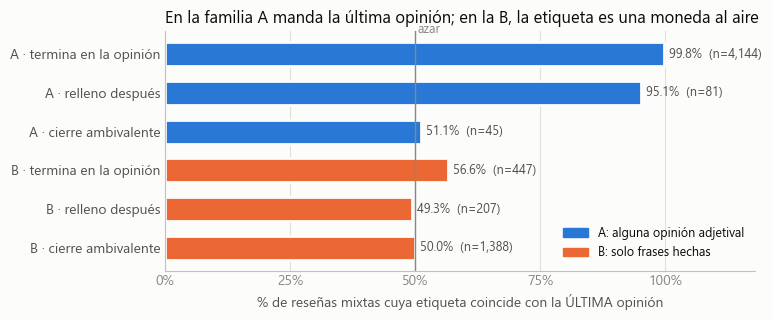

In [24]:
d = (F[F.familia.isin([FAM_A, FAM_B])].groupby(['familia', 'final'])
     .agg(tasa=('gana_ultima', 'mean'), n=('gana_ultima', 'size')).reset_index())
d['orden_final'] = d.final.map({'opinion': 0, 'relleno': 1, 'cierre': 2})
d = d.sort_values(['familia', 'orden_final'], ascending=[False, False])
NOMBRE_FINAL = {'opinion': 'termina en la opinión', 'relleno': 'relleno después', 'cierre': 'cierre ambivalente'}
COLOR_FAMILIA = {FAM_A: AZUL, FAM_B: NARANJA}

fig, ax = plt.subplots(figsize=(7.8, 3.3))
ax.barh(np.arange(len(d)), 100 * d.tasa, height=0.62, color=[COLOR_FAMILIA[f] for f in d.familia],
        edgecolor=SUPERFICIE, linewidth=2)
for yy, (v, n) in enumerate(zip(d.tasa, d.n)):
    ax.text(100 * v + 1, yy, f'{100 * v:.1f}%  (n={n:,})', va='center', fontsize=9, color=TINTA2)
ax.set_yticks(np.arange(len(d)), [('A · ' if f == FAM_A else 'B · ') + NOMBRE_FINAL[fi] for f, fi in zip(d.familia, d.final)])
ax.axvline(50, color=TENUE, linewidth=1)
ax.text(50.5, len(d) - 0.45, 'azar', color=TENUE, fontsize=9)
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('En la familia A manda la última opinión; en la B, la etiqueta es una moneda al aire', color=TINTA)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_FAMILIA.values()],
          labels=['A: alguna opinión adjetival', 'B: solo frases hechas'], loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

In [25]:
# Dos ejemplos tal como los ve el parser
def mostrar_analisis(i):
    a = ANALISIS[i]
    print(f'[{y[i]}]  {X[i]}')
    for o in a['opiniones']:
        fam = 'A' if es_adjetival(o) else 'B'
        print(f"    opinión {fam} {polaridad_semantica(o['clave']):+d}  {o['nucleo']!r:44s} "
              f"conector: {o['conector'] or '-'} ({o['tipo_conector']})")
    final, relleno = tipo_de_final(a)
    print(f"    termina en: {final}" + (f" ({a['cierre'] or a['cierre_en_linea']})" if final == 'cierre' else '') + '\n')

mostrar_analisis(F[(F.familia == FAM_A) & (F.conector == 'aditivo') & (F.final == 'opinion')].index[0])
mostrar_analisis(F[(F.familia == FAM_B) & (F.final == 'cierre')].index[0])

[positivo]  Comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa. La verdad sea dicha, el boton de encendido me parecio incomodo en el uso real, lo he estado usando en la oficina todas las tardes. Aun asi, tuve que escribirles un par de veces por una duda de configuracion y el soporte tecnico se sintio funcional al final de cuentas.
    opinión A -1  'me parecio incomodo'                        conector: - (ninguno)
    opinión A +1  'se sintio funcional'                        conector: y (aditivo)
    termina en: opinion

[negativo]  La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro modelo, pero eso ya es cosa de cada quien. Lo dejo a tu criterio.
    opinión B -1  'fue un error'             

In [26]:
# Techo aproximado: en cada celda (familia B x final) lo mejor que puede hacer una regla es max(p, 1 - p)
B_mix = F[F.familia == FAM_B]
aciertos_max_B = B_mix.groupby('final').gana_ultima.agg(lambda s: len(s) * max(s.mean(), 1 - s.mean())).sum()
errores_min_B = len(B_mix) - aciertos_max_B
techo = 1 - errores_min_B / len(y)
print(f'Mixtas B: {len(B_mix):,} reseñas ({100 * len(B_mix) / len(y):.1f} % del train). '
      f'Aun acertando todo lo demás, cuestan ≥ {errores_min_B:.0f} errores -> techo ≈ {techo:.3f}')

Mixtas B: 2,042 reseñas (17.0 % del train). Aun acertando todo lo demás, cuestan ≥ 990 errores -> techo ≈ 0.917


**Lo que muestran las tablas**
- **Mixtas A.** Si la reseña mezcla opiniones de signo contrario y al menos una es adjetival, la etiqueta es la de la **última opinión** en el 99.8 % de las que terminan en opinión (n = 4 144), y eso vale **con cualquier conector**: 99.6-100 % también con *"y"*, *"además"*, *"por otro lado"* o sin conector (tabla cruzada). Con relleno detrás de la última opinión sigue mandando (95 %); solo las pocas que cierran con una frase ambivalente (n = 45) caen al azar. El aparente azar de los conectores aditivos de la sección 5 se debía a que allí se mezclaban las dos familias.
- **Mixtas B.** Si todas las opiniones son frases hechas, la última opinión gana solo el 51.4 % de las veces (n = 2 042, el 17.0 % del train) y v1 acierta el 53.1 %. En experimentos exploratorios probamos orden, posición, aspecto, intensidad, identidad del cierre, mayoría de opiniones y TF-IDF dentro del subconjunto (LR, árbol y HGB, con pruebas de permutación): todo queda entre 47 % y 53 %, sin significación (sección 16). **Es ruido de etiqueta.** Solo quedan señales débiles y en pocos casos: si la reseña B termina en una opinión, la última gana algo más a menudo (56.6 %), y más aún si la introduce un conector fuerte (81 %, pero n = 27).
- **Techo.** Aunque todo lo demás se acertara, la mejor regla por celda en las mixtas B deja unos 990 errores: el techo práctico de accuracy en validación cruzada ronda **0.9175**, es decir, 0.915–0.92 (no es una cota estricta: un modelo puede exprimir algo las señales débiles, y también sobreajustar ruido).
- **Margen recuperable.** v1 todavía comete 160 errores fuera de las mixtas B, la mayoría en celdas **deterministas**: reseñas coherentes (una opinión o todas del mismo signo) seguidas de relleno o de un cierre, mixtas A que terminan en opinión o con relleno, neutrales. Los componentes nuevos atacan exactamente eso.

## 10. Componente nuevo 1: `estructural` (parser de plantillas → rasgos firmados → HistGradientBoosting)

**Qué hace.** Transforma cada reseña en **59 rasgos numéricos** que describen su estructura según el parser de la sección 9, y los clasifica con un `HistGradientBoostingClassifier`:
- signo de la primera y de la última opinión, de la última opinión adjetival y de la última frase hecha;
- si la reseña es coherente o mixta y, en las mixtas, el signo de la última opinión separado por familia (`signo_mixta_A`, `signo_mixta_B`), por tipo de conector del último cambio de signo y por conector concreto;
- cómo termina la reseña (opinión, relleno o cierre ambivalente), cruzado con el signo de la última opinión;
- conteos de opiniones positivas, negativas, adjetivales y fijas, y número de oraciones.

Los rasgos están **firmados**: valen +1 o −1 según la polaridad de la opinión implicada. Así el árbol aprende reglas generales como *"mixta A → manda la última"* o *"una sola opinión seguida de relleno → su signo"* sin memorizar cada adjetivo.

**Por qué funciona.** La bolsa de palabras ve las palabras, pero no sabe cuál es la última opinión ni a qué familia pertenece; el parser lo hace explícito y el HGB combina esas señales de forma no lineal (familia × final × conector). Corrige sobre todo celdas deterministas donde v1 fallaba.

**Cómo se evita la fuga.** Todo lo que se aprende de los datos ocurre en `fit`, es decir, solo con el fold de entrenamiento:
1. el **vocabulario del corrector de typos** (frecuencias de las palabras de los textos de entrenamiento);
2. la **polaridad de cada clave de opinión** (`modo_polaridad='aprendida'`): la etiqueta mayoritaria de las reseñas de entrenamiento que tienen esa única opinión; con menos de 3 apariciones se usa la polaridad semántica del inventario. En la práctica es un **léxico manual que la mayoría de etiquetas del fold confirma**: en los 10 folds de las dos particiones, 0 de las 1 127 claves aprendidas difieren de la polaridad semántica (sección 13.2);
3. el **HistGradientBoosting** (`learning_rate=0.05`, 200 iteraciones, 15 hojas, `min_samples_leaf=20`; sin *early stopping*, para que el CV y el ajuste final se comporten igual).

El inventario de regex es fijo y no se ajusta a etiquetas, pero lo escribimos a mano mirando reseñas de train: es un sesgo de diseño que discutimos en las limitaciones. (En el experimento original, la versión con polaridad semántica fija, que no usa ninguna etiqueta, dio exactamente el mismo resultado.)

El componente es un `Pipeline` de scikit-learn que recibe **texto crudo**, así que funciona dentro de `cross_val_predict` y de `VotingClassifier` (que le pasan las etiquetas codificadas 0/1/2; `RasgosPlantilla` acepta ambos formatos).

**En v3c** este componente se usa con el **parser robusto** de la sección 10.1: los mismos 59 rasgos y el mismo HistGradientBoosting; solo cambia qué opiniones reconoce el parser. Aquí calculamos la OOF con el **parser original**, que es el del modelo v3b enviado a Kaggle, como referencia (en el código, `estructural_original`).

In [27]:
CONECTORES_RASGO = ['eso si', 'aun asi', 'al final', 'con todo', 'pero', 'a fin de cuentas', 'por otro lado', 'de paso',
                    'por cierto', 'ademas', 'ahora', 'y', '', 'lo que si', 'aunque', 'sin embargo', 'pero al final',
                    'igual', 'en cambio', 'ahora bien', 'aun con eso']


def rasgos_plantilla(analisis, signo=polaridad_semantica):
    """59 rasgos de una reseña, casi todos «firmados»: valen +1 o -1 según la polaridad de la opinión implicada."""
    ops, S, f = analisis['opiniones'], analisis['oraciones'], {}
    n = len(ops)
    signos = [signo(o['clave']) for o in ops]
    f['sin_opinion'] = float(n == 0)
    f['n_opiniones'] = n
    f['n_positivas'] = sum(s == 1 for s in signos)
    f['n_negativas'] = sum(s == -1 for s in signos)
    f['n_adjetivales'] = sum(es_adjetival(o) for o in ops)
    f['n_fijas'] = n - f['n_adjetivales']
    f['signo_mayoria'] = float(np.sign(f['n_positivas'] - f['n_negativas']))
    s_primera = signos[0] if n else 0
    s_ultima = signos[-1] if n else 0
    f['signo_primera'] = s_primera
    f['signo_ultima'] = s_ultima
    coherente = n > 0 and len(set(signos)) == 1
    mixta = len(set(signos)) == 2
    f['coherente'] = float(coherente)
    f['signo_coherente'] = s_ultima if coherente else 0
    f['mixta'] = float(mixta)
    adj = [s for s, o in zip(signos, ops) if es_adjetival(o)]
    fij = [s for s, o in zip(signos, ops) if not es_adjetival(o)]
    f['signo_ultima_adj'] = adj[-1] if adj else 0
    f['signo_primera_adj'] = adj[0] if adj else 0
    f['signo_ultima_fija'] = fij[-1] if fij else 0
    f['signo_mixta_A'] = s_ultima if (mixta and adj) else 0          # mixta con algún adjetivo: manda la última
    f['signo_mixta_B'] = s_ultima if (mixta and not adj) else 0      # mixta solo de frases hechas: ~azar
    # conector del último cambio de signo (o de la última opinión si no hay cambio)
    jc = [j for j in range(1, n) if signos[j] != signos[j - 1]][-1] if mixta else n - 1
    con = ops[jc]['conector'] if n else ''
    tipo = ops[jc]['tipo_conector'] if n else 'ninguno'
    for t in ['fuerte', 'debil', 'aditivo', 'ninguno']:
        f['conector_' + t] = float(tipo == t)
        f['signo_mixta_conector_' + t] = s_ultima if (tipo == t and mixta) else 0
    for c in CONECTORES_RASGO:
        f['signo_mixta_con=' + (c or 'nada')] = s_ultima if (con == c and mixta) else 0
    # cómo termina la reseña
    if n:
        ultima = ops[-1]
        final, relleno = tipo_de_final(analisis)
        f['relleno_despues'] = relleno
        f['cierre'] = float(bool(analisis['cierre']))
        f['cierre_en_linea'] = float(bool(analisis['cierre_en_linea']))
        f['termina_opinion'] = float(final == 'opinion')
        f['termina_relleno'] = float(final == 'relleno')
        f['termina_cierre'] = float(final == 'cierre')
        f['signo_ultima_x_termina_opinion'] = s_ultima * f['termina_opinion']
        f['signo_ultima_x_termina_relleno'] = s_ultima * f['termina_relleno']
        f['signo_ultima_x_termina_cierre'] = s_ultima * f['termina_cierre']
        f['posicion_ultima'] = ultima['oracion'] / max(1, len(S) - 1)
        cola = ultima['resto_fragmento'] + ' ' + ultima['despues']
        f['signo_ultima_eso_si_cola'] = s_ultima * float(bool(re.search(r'\beso si\b', cola)))
        f['signo_ultima_algun_fuerte'] = s_ultima * float(any(o['tipo_conector'] == 'fuerte' for o in ops[1:]))
    else:
        for k in ['relleno_despues', 'cierre', 'cierre_en_linea', 'termina_opinion', 'termina_relleno',
                  'termina_cierre', 'signo_ultima_x_termina_opinion', 'signo_ultima_x_termina_relleno',
                  'signo_ultima_x_termina_cierre', 'posicion_ultima', 'signo_ultima_eso_si_cola',
                  'signo_ultima_algun_fuerte']:
            f[k] = 0.0
    f['n_oraciones'] = len(S)
    return f


def _es_positivo(v):   # acepta etiquetas de texto o codificadas (0 = negativo, 1 = neutral, 2 = positivo)
    return v == 'positivo' or (not isinstance(v, str) and int(v) == 2)


def _es_negativo(v):
    return v == 'negativo' or (not isinstance(v, str) and int(v) == 0)


class RasgosPlantilla(TransformerMixin, BaseEstimator):
    """Texto crudo -> DataFrame de rasgos estructurales. En fit() se ajustan, solo con los textos de entrenamiento,
    el corrector de typos y (modo_polaridad='aprendida') la polaridad de cada clave de opinión: la etiqueta
    mayoritaria de las reseñas de entrenamiento que tienen esa única opinión (con < min_n apariciones se usa la
    polaridad semántica del inventario)."""

    def __init__(self, min_frec=5, modo_polaridad='aprendida', min_n=3):
        self.min_frec = min_frec
        self.modo_polaridad = modo_polaridad
        self.min_n = min_n

    def _ajustar(self, X, y):
        self.corrector_ = CorrectorTypos(self.min_frec).fit([normalizar(t) for t in X])
        self.lexico_ = {}
        analisis = self.analizar(X)
        if self.modo_polaridad == 'aprendida':
            conteo = {}
            for a, v in zip(analisis, y):
                if len(a['opiniones']) != 1 or not (_es_positivo(v) or _es_negativo(v)):
                    continue
                conteo.setdefault(a['opiniones'][0]['clave'], [0, 0])[int(_es_positivo(v))] += 1
            self.lexico_ = {k: (1 if pos > neg else -1) for k, (neg, pos) in conteo.items() if neg + pos >= self.min_n}
        return analisis

    def fit(self, X, y=None):
        self._ajustar(X, y)
        return self

    def fit_transform(self, X, y=None):
        return self._tabla(self._ajustar(X, y))      # analiza el train una sola vez

    def signo(self, clave):
        return self.lexico_.get(clave, polaridad_semantica(clave))

    def analizar(self, X):
        return [analizar_resena(self.corrector_.transform(normalizar(t))) for t in X]

    def _tabla(self, analisis):
        return pd.DataFrame([rasgos_plantilla(a, self.signo) for a in analisis]).astype(float)

    def transform(self, X):
        return self._tabla(self.analizar(X))


def modelo_estructural():
    return Pipeline([('rasgos', RasgosPlantilla(modo_polaridad='aprendida')),
                     ('clf', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                                                            min_samples_leaf=20, early_stopping=False,
                                                            random_state=0))])


print(f'{len(rasgos_plantilla(demo))} rasgos por reseña. El componente:')
print(modelo_estructural())

59 rasgos por reseña. El componente:
Pipeline(steps=[('rasgos', RasgosPlantilla()),
                ('clf',
                 HistGradientBoostingClassifier(early_stopping=False,
                                                learning_rate=0.05,
                                                max_iter=200, max_leaf_nodes=15,
                                                random_state=0))])


In [28]:
# Los 59 rasgos de los dos ejemplos anteriores (polaridad semántica, solo para ilustrar)
ejemplos = [F[(F.familia == FAM_A) & (F.conector == 'aditivo') & (F.final == 'opinion')].index[0],
            F[(F.familia == FAM_B) & (F.final == 'cierre')].index[0]]
R = pd.DataFrame([rasgos_plantilla(ANALISIS[i]) for i in ejemplos], index=['ejemplo A', 'ejemplo B']).T + 0.0
print('Rasgos distintos de cero (de 59):')
R[(R != 0).any(axis=1)].round(2)

Rasgos distintos de cero (de 59):


,ejemplo A,ejemplo B
n_opiniones,2.0,2.0
n_positivas,1.0,1.0
n_negativas,1.0,1.0
n_adjetivales,2.0,0.0
n_fijas,0.0,2.0
signo_primera,-1.0,-1.0
signo_ultima,1.0,1.0
mixta,1.0,1.0
signo_ultima_adj,1.0,0.0
signo_primera_adj,-1.0,0.0


In [29]:
t0 = time.time()
OOF['estructural_original'] = cross_val_predict(modelo_estructural(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
SEGUNDOS['estructural_original'] = time.time() - t0
print(f"estructural (parser original): accuracy OOF = {acc_oof(OOF['estructural_original']):.4f}  "
      f"({SEGUNDOS['estructural_original']:.0f} s)")
print(f"Notebook v3b y experimento original (mismo código y partición): 0.9075 -> diferencia "
      f"{acc_oof(OOF['estructural_original']) - 0.9075:+.4f}")

estructural (parser original): accuracy OOF = 0.9075  (13 s)
Notebook v3b y experimento original (mismo código y partición): 0.9075 -> diferencia +0.0000


### 10.1 Parser robusto: reglas genéricas para giros no vistos

**Motivación (transparencia).** El inventario del parser se escribió leyendo reseñas de `train`, y la prueba de estrés de la sección 13.2 muestra que, si el parser deja de reconocer una opinión, el componente estructural se equivoca **con confianza**. Para saber si ese riesgo era real se hizo, en una auditoría **externa a este notebook**, un diagnóstico de **solo lectura** de la cobertura del parser sobre los textos de `eval.csv`: sin etiquetas (no las tiene), sin entrenar ni ajustar nada, solo contando qué reseñas quedaban con opiniones sin reconocer y qué forma tenían. El diagnóstico mostró que `eval` usa algunos **intensificadores y perífrasis verbales que el inventario no cubría**.

**La corrección no usa ninguna palabra ni frase de `eval`.** En lugar de añadir esos giros al inventario, añadimos tres **reglas morfológicas genéricas del español**, que cubren familias enteras de construcciones, y las validamos **exclusivamente con `train`**: cobertura y falsos positivos en las reseñas neutrales (abajo), accuracy OOF con las particiones 42 y 2024 (en desarrollo también con una tercera, `random_state=7`; sección 16) y una prueba de estrés que reescribe las opiniones de validación de cada fold con esos giros genéricos (sección 13.3). Fuera de esa auditoría, `eval.csv` solo se usa en este notebook para comprobar su formato (sección 2) y para la predicción final (sección 17).

| Regla | Qué reconoce además del inventario | Ejemplo genérico |
|---|---|---|
| **R1** adverbios en *-mente* | hasta 2 adverbios terminados en *-mente* entre el verbo copulativo y el adjetivo, antes o después del modificador | *"la batería se mantuvo **honestamente** buenísima"* |
| **R2** raíces copulativas | los verbos copulativos por su **raíz** (*result-, parec-, sint-/sient-, mant-, qued-, sal-, luc-, volv-, not-*) con cualquier flexión, gerundio o pronombre enclítico, con o sin *me / se / le / te / nos* delante, y la perífrasis ***terminar / acabar* + forma verbal** | *"la cámara **terminó resultando** decepcionante"*, *"el cable se **notaba** frágil"* |
| **R3** respaldo | solo en fragmentos **sin ninguna opinión reconocida**: *artículo + sustantivo (+ hasta 5 palabras) + (muy / bastante / -mente) + adjetivo polar del inventario* cuenta como opinión A; se descarta si hay una negación en medio | *"el teclado de este modelo bastante **cómodo**"* |

**Falsos positivos y fuga.** R3 es la regla más arriesgada, porque un adjetivo del inventario también puede aparecer en una frase de hechos. Por eso, en `fit` y **solo con las reseñas del fold de entrenamiento**, se cuentan los disparos de R3 y se **excluyen los adjetivos cuyo respaldo dispara alguna vez en una reseña neutral** (`max_neutral = 0`). Es la única parte nueva que mira etiquetas. El resto del componente es idéntico al de la sección 10: corrector de typos y polaridad de las claves ajustados en `fit`, los mismos 59 rasgos y el mismo HistGradientBoosting. Para no duplicar código, `analizar_resena` (sección 9) recibe ahora como argumento opcional la función que detecta las opiniones de un fragmento; por defecto es la original, así que el parser original no cambia.

Las reglas se ajustaron con train y se fijaron antes de construir este notebook; aquí no se eligen ni se ajustan con ningún dato de `eval`.

In [30]:
# ---------------------------------------------------------------- parser robusto: reglas genéricas R1-R3
# Ninguna regla contiene palabras ni frases de eval.csv: son patrones morfológicos generales del español sobre el
# mismo inventario de verbos copulativos y adjetivos de la sección 9.
ADJETIVOS_ALT = '|'.join(sorted(ADJETIVOS_POS + ADJETIVOS_NEG, key=len, reverse=True))
COPULAS_ALT = '|'.join(sorted(COPULAS, key=len, reverse=True))
# R1: hasta 2 adverbios terminados en -mente entre el verbo copulativo y el adjetivo (antes o después del modificador)
RX_MENTE = r'(?:[a-z]+mente\s+){0,2}'
# R2: verbos copulativos por su raíz (cualquier flexión, gerundio o pronombre enclítico), con o sin pronombre delante,
#     y perífrasis 'terminar / acabar + forma verbal'
RX_RAICES = (r'(?:(?:me|se|le|te|nos)\s+)?(?:(?:termin|acab)(?:o|a|e|an|aron|aba|ando)\s+)?'
             r'(?:result|parec|pareci|sint|sient|mant|qued|sal|luc|volv|not)\w*')


def regex_adjetivo_robusta(mente=True, raices=True):
    # La regex RE_ADJETIVO de la sección 9 con las reglas R1 y/o R2 activadas
    copulas = COPULAS_ALT + ('|' + RX_RAICES if raices else '')
    adverbios = RX_MENTE if mente else ''
    return re.compile(r'\b(?P<cop>' + copulas + r')\s+' + adverbios + MODIFICADORES + adverbios +
                      r'(?P<adj>' + ADJETIVOS_ALT + r')\b')


# R3: respaldo. En un fragmento sin ninguna opinión reconocida, '<artículo> <sustantivo> (hasta 5 palabras más)
#     (muy / bastante / -mente) <adjetivo polar del inventario>' cuenta como opinión A
RE_RESPALDO = re.compile(r'\b(?:el|la|los|las|lo de la|lo del)\s+[a-z]+(?:\s+[a-z]+){0,5}?\s+(?:muy\s+|bastante\s+|'
                         r'[a-z]+mente\s+)?(?P<adj>' + ADJETIVOS_ALT + r')\b')


def opiniones_fragmento_robusto(f, rx_adjetivo, respaldo, excluidos):
    """Como opiniones_fragmento (sección 9), con la regex de adjetivos de R1-R2 y, si el fragmento no tiene ningún
    núcleo, el respaldo R3 (salvo para los adjetivos excluidos en fit)."""
    hallazgos = []
    for clave, rx in RE_FRASES_FIJAS:
        for m in rx.finditer(f):
            hallazgos.append((clave, m.start(), m.end()))
    for m in rx_adjetivo.finditer(f):
        adj = m.group('adj')
        cop = m.group('cop')
        if adj in ('bien', 'mal') and cop in ('es', 'esta', 'fue', 'sigue'):
            continue
        signo = 'a+' if RE_ADJETIVO_POSITIVO.match(adj) else 'a-'
        mod = m.group('mod') or ''
        if mod in ('poco', 'nada'):
            signo = 'a-' if signo == 'a+' else 'a+'
        elif re.search(r'\bno\s+$', f[max(0, m.start() - 4):m.start()]):
            signo = 'a-' if signo == 'a+' else 'a+'
            mod = 'no'
        base = re.sub(r'[oa]$', '', adj) if ' ' not in adj else adj
        hallazgos.append((f'{signo}:{mod + " " if mod in ("poco", "nada", "no") else ""}{base}', m.start(), m.end()))
    if respaldo and not hallazgos:
        for m in RE_RESPALDO.finditer(f):
            adj = m.group('adj')
            if adj in ('bien', 'mal') or adj in excluidos:
                continue
            if re.search(r'\b(?:no|nunca|ni|sin)\b', f[m.start():m.start('adj')]):
                continue                              # con una negación en medio no se arriesga
            signo = 'a+' if RE_ADJETIVO_POSITIVO.match(adj) else 'a-'
            base = re.sub(r'[oa]$', '', adj) if ' ' not in adj else adj
            hallazgos.append((f'{signo}:{base}', m.start('adj'), m.end()))
    hallazgos.sort(key=lambda h: (h[1], -(h[2] - h[1])))
    salida, fin = [], -1
    for h in hallazgos:
        if h[1] >= fin:
            salida.append(h)
            fin = h[2]
    return salida


class RasgosRobustos(RasgosPlantilla):
    """RasgosPlantilla (sección 10) con las reglas genéricas R1-R3 activables. En fit(), además del corrector de
    typos y de la polaridad de las claves, aprende SOLO con el train del fold los adjetivos excluidos del respaldo R3:
    los que lo disparan en reseñas neutrales en más de max_neutral x (número de disparos) ocasiones."""

    def __init__(self, min_frec=5, modo_polaridad='aprendida', min_n=3, mente=True, raices=True, respaldo=True,
                 max_neutral=0.0):
        super().__init__(min_frec=min_frec, modo_polaridad=modo_polaridad, min_n=min_n)
        self.mente = mente
        self.raices = raices
        self.respaldo = respaldo
        self.max_neutral = max_neutral

    @staticmethod
    def _analizar_texto(t, rx_adjetivo, respaldo, excluidos):
        # t: texto normalizado y corregido; el análisis es el de la sección 9 con el detector robusto
        return analizar_resena(t, lambda f: opiniones_fragmento_robusto(f, rx_adjetivo, respaldo, excluidos))

    def _ajustar(self, X, y):
        self.rx_ = regex_adjetivo_robusta(self.mente, self.raices)
        self.excluidos_ = frozenset()
        if self.respaldo and y is not None:
            # adjetivos cuyo respaldo dispara en reseñas neutrales del train de este fold -> excluidos
            corrector = CorrectorTypos(self.min_frec).fit([normalizar(t) for t in X])
            disparos, en_neutral = {}, {}
            for t, v in zip(X, y):
                es_neutral = not (_es_positivo(v) or _es_negativo(v))
                tc = corrector.transform(normalizar(t))
                sin_respaldo = {o['nucleo'] for o in self._analizar_texto(tc, self.rx_, False, frozenset())['opiniones']}
                for o in self._analizar_texto(tc, self.rx_, True, frozenset())['opiniones']:
                    if o['nucleo'] not in sin_respaldo and o['clave'][:2] in ('a+', 'a-'):
                        adj = o['nucleo'].split()[-1]
                        disparos[adj] = disparos.get(adj, 0) + 1
                        en_neutral[adj] = en_neutral.get(adj, 0) + int(es_neutral)
            self.excluidos_ = frozenset(a for a, n in disparos.items() if en_neutral[a] > self.max_neutral * n)
        return super()._ajustar(X, y)        # corrector, polaridad de las claves y análisis del train

    def analizar(self, X):
        rx = getattr(self, 'rx_', None) or regex_adjetivo_robusta(self.mente, self.raices)
        return [self._analizar_texto(self.corrector_.transform(normalizar(t)), rx, self.respaldo, self.excluidos_)
                for t in X]


def modelo_estructural_robusto(**kw):
    # El mismo componente de la sección 10 (59 rasgos + HistGradientBoosting) con el parser robusto
    return Pipeline([('rasgos', RasgosRobustos(**kw)),
                     ('clf', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                                                            min_samples_leaf=20, early_stopping=False,
                                                            random_state=0))])


print('Parámetros del parser robusto (clonable):', clone(RasgosRobustos()).get_params())

Parámetros del parser robusto (clonable): {'max_neutral': 0.0, 'mente': True, 'min_frec': 5, 'min_n': 3, 'modo_polaridad': 'aprendida', 'raices': True, 'respaldo': True}


In [31]:
# Cobertura del parser en train (diagnóstico con TODO train). Las etiquetas solo se usan para separar neutrales de
# polares al medir y, como en fit, para la polaridad de las claves y la lista de exclusión de R3.
VARIANTES_PARSER = {'original': None,
                    'solo R1 (adverbios en -mente)': dict(mente=True, raices=False, respaldo=False),
                    'solo R2 (raíces copulativas)': dict(mente=False, raices=True, respaldo=False),
                    'solo R3 (respaldo)': dict(mente=False, raices=False, respaldo=True),
                    'robusto (R1 + R2 + R3)': dict(mente=True, raices=True, respaldo=True)}
t0 = time.time()
es_neutral = y == 'neutral'
PARSERS, ANALISIS_PARSER, filas_cobertura = {}, {}, []
for nombre, kw in VARIANTES_PARSER.items():
    PARSERS[nombre] = RasgosPlantilla() if kw is None else RasgosRobustos(**kw)
    ANALISIS_PARSER[nombre] = PARSERS[nombre]._ajustar(X, y)        # ajusta y devuelve el análisis de train
    n_op = np.array([len(a['opiniones']) for a in ANALISIS_PARSER[nombre]])
    filas_cobertura.append({'parser': nombre,
                            'neutrales con opinión (%)': 100 * (n_op[es_neutral] > 0).mean(),
                            'polares sin opinión (%)': 100 * (n_op[~es_neutral] == 0).mean(),
                            'opiniones por polar': n_op[~es_neutral].mean(),
                            'excluidos de R3': len(PARSERS[nombre].excluidos_) if kw and kw['respaldo'] else np.nan})
cobertura = pd.DataFrame(filas_cobertura).set_index('parser')
print(f'Cobertura de cada versión del parser en las {len(y):,} reseñas de train ({time.time() - t0:.0f} s):')
display(cobertura.round({'neutrales con opinión (%)': 2, 'polares sin opinión (%)': 2, 'opiniones por polar': 3}))

claves = lambda a: [o['clave'] for o in a['opiniones']]
cambia = np.array([claves(a) != claves(b) for a, b in zip(ANALISIS_PARSER['original'], ANALISIS_PARSER['robusto (R1 + R2 + R3)'])])
mas_opiniones = np.array([len(b['opiniones']) > len(a['opiniones'])
                          for a, b in zip(ANALISIS_PARSER['original'], ANALISIS_PARSER['robusto (R1 + R2 + R3)'])])
print(f'Reseñas de train cuyo análisis cambia con el parser robusto: {cambia.sum()} ({100 * cambia.mean():.1f} %): '
      f'{(cambia & ~es_neutral).sum()} polares y {(cambia & es_neutral).sum()} neutrales; en {mas_opiniones.sum()} '
      'se reconoce alguna opinión más')
print('Adjetivos excluidos del respaldo R3 (disparan en alguna reseña neutral de train):',
      ', '.join(sorted(PARSERS['robusto (R1 + R2 + R3)'].excluidos_)))

Cobertura de cada versión del parser en las 12,000 reseñas de train (45 s):


,neutrales con opinión (%),polares sin opinión (%),opiniones por polar,excluidos de R3
parser,,,,
original,1.03,0.23,1.800,NaN
solo R1 (adverbios en -mente),1.03,0.23,1.800,NaN
solo R2 (raíces copulativas),1.09,0.21,1.801,NaN
solo R3 (respaldo),1.03,0.19,1.803,10.0
robusto (R1 + R2 + R3),1.09,0.19,1.804,10.0


Reseñas de train cuyo análisis cambia con el parser robusto: 38 (0.3 %): 36 polares y 2 neutrales; en 36 se reconoce alguna opinión más
Adjetivos excluidos del respaldo R3 (disparan en alguna reseña neutral de train): basica, basico, comoda, completa, completo, correcta, correcto, corriente, delicada, mala


In [32]:
# Frases genéricas escritas a mano (no salen de ningún conjunto de datos), vistas por el parser original y el robusto
FRASES_DEMO = ['la bateria se mantuvo honestamente buenisima.',      # R1: adverbio en -mente
               'la camara termino resultando decepcionante.',       # R2: perífrasis terminar + gerundio
               'el cable se notaba fragil.',                         # R2: otra flexión del verbo copulativo
               'el teclado de este modelo bastante comodo.']         # R3: artículo + sustantivo + adjetivo
for frase in FRASES_DEMO:
    print(frase)
    for nombre in ['original', 'robusto (R1 + R2 + R3)']:
        ops = PARSERS[nombre].analizar([frase])[0]['opiniones']
        texto = ', '.join(f"{o['clave']} ({o['nucleo']!r})" for o in ops) or 'ninguna opinión'
        print(f'    {nombre:24s} -> {texto}')

la bateria se mantuvo honestamente buenisima.
    original                 -> ninguna opinión
    robusto (R1 + R2 + R3)   -> a+:buenisim ('se mantuvo honestamente buenisima')
la camara termino resultando decepcionante.
    original                 -> ninguna opinión
    robusto (R1 + R2 + R3)   -> a-:decepcionante ('termino resultando decepcionante')
el cable se notaba fragil.
    original                 -> ninguna opinión
    robusto (R1 + R2 + R3)   -> a-:fragil ('se notaba fragil')
el teclado de este modelo bastante comodo.
    original                 -> ninguna opinión
    robusto (R1 + R2 + R3)   -> a+:comod ('comodo')


In [33]:
t0 = time.time()
OOF['estructural'] = cross_val_predict(modelo_estructural_robusto(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
SEGUNDOS['estructural'] = time.time() - t0
print(f"estructural (parser robusto): accuracy OOF = {acc_oof(OOF['estructural']):.4f}  ({SEGUNDOS['estructural']:.0f} s)")
print(f"Experimento de desarrollo (mismo código y partición): 0.9076 -> diferencia {acc_oof(OOF['estructural']) - 0.9076:+.4f}")
pred_est_robusto, pred_est_original = CLASES[OOF['estructural'].argmax(1)], CLASES[OOF['estructural_original'].argmax(1)]
mc_parser = mcnemar(pred_est_robusto, pred_est_original, y)
print(f"Frente al parser original ({acc_oof(OOF['estructural_original']):.4f}): cambian "
      f"{int((pred_est_robusto != pred_est_original).sum())} predicciones de {len(y):,}; McNemar: el robusto acierta "
      f"{mc_parser['gana']} que el original falla y falla {mc_parser['pierde']} que el original acierta (p = {mc_parser['p']:.2f})")

estructural (parser robusto): accuracy OOF = 0.9076  (29 s)
Experimento de desarrollo (mismo código y partición): 0.9076 -> diferencia -0.0000
Frente al parser original (0.9075): cambian 121 predicciones de 12,000; McNemar: el robusto acierta 61 que el original falla y falla 60 que el original acierta (p = 1.00)


**Resultado en train**
- **Cobertura.** Las reseñas polares sin ninguna opinión reconocida bajan de 0.23 % a 0.19 %, y las neutrales con alguna opinión (falsos positivos) pasan de 1.03 % a 1.09 %. En total cambia el análisis de 38 reseñas de train (0.3 %): 36 polares y 2 neutrales; en 36 se reconoce alguna opinión más.
- **Por regla.** R1 no cambia nada en train: ninguna reseña de train tiene un adverbio en *-mente* entre el verbo copulativo y el adjetivo (lo comprobamos aparte), así que es una regla puramente preventiva. R2 recupera algunas polares (0.21 % quedan sin opinión) y es la responsable del pequeño aumento de falsos positivos en neutrales (1.09 %). R3 recupera otras (0.19 %) sin falsos positivos nuevos en las neutrales, por construcción: al ajustarla con todo train se excluyen los 10 adjetivos que disparaban en alguna neutral (*basica*, *basico*, *comoda*, *completa*, *completo*, *correcta*, *correcto*, *corriente*, *delicada*, *mala*), adjetivos que también aparecen en descripciones de hechos. En la validación cruzada esa lista se aprende en cada fold, solo con su train.
- **Accuracy.** El componente con el parser robusto obtiene 0.9076 de accuracy OOF, igual que en el desarrollo (0.9076), frente a 0.9075 con el parser original (+0.01 pts). Cambian 121 predicciones de 12 000 y el McNemar es neutro: 61 reseñas ganadas frente a 60 perdidas (p = 1.00). Es lo esperable: en train el inventario ya reconoce casi todas las opiniones y las reglas apenas tienen dónde actuar. Su valor está en los giros que train no contiene, y eso lo mide la prueba de estrés de la sección 13.3.

Las cifras de cobertura coinciden con las del desarrollo (neutrales con opinión 1.03 % → 1.09 %, polares sin opinión 0.23 % → 0.19 %, 10 adjetivos excluidos).

## 11. Componentes nuevos 2 y 3: `est_lr` y `stk_nb6_anc`
Los dos componentes de esta sección **no usan el parser** de las secciones 9-10. `est_lr` (11.1) reconoce las opiniones con un clasificador de fragmentos entrenado con supervisión débil, y `stk_nb6_anc` (11.2) con un detector de opinión por cláusula y bolsas de palabras NB-LR. Capturan parte de la misma estructura de plantillas, pero fallan de otra manera que el parser cuando aparece un giro que el inventario no contiene (secciones 13.2 y 13.3): por eso los combinamos.

### 11.1 `est_lr`: polaridad por fragmento con supervisión débil → 80 rasgos → regresión logística


**Qué hace.**
1. **Segmenta** cada reseña en fragmentos (oraciones; comas; *"y el/la…"*; *pero*; *aunque*) y anota el conector que abre cada fragmento: fuerte, *eso sí*, débil, aditivo, *y* o ninguno.
2. Un **clasificador de fragmentos** (regresión logística sobre TF-IDF de palabras 1-3 y caracteres `char_wb` 2-5) asigna a cada fragmento una de 6 clases: sin opinión, cierre ambivalente, A+, A−, F+, F− (F = frase hecha, la familia B). No hay etiquetas por fragmento, así que se entrena con **supervisión débil**:
   - **polaridad A**: una LR auxiliar aprende la polaridad de los adjetivos con los fragmentos que abre un conector **fuerte**, porque ahí la etiqueta de la reseña es la de ese fragmento ~99 % de las veces;
   - **frases hechas y cierres ambivalentes**: léxico escrito a mano con su polaridad semántica (no se ajusta a etiquetas);
   - **sin opinión**: todos los fragmentos de reseñas neutrales.
3. Con las probabilidades de los fragmentos calcula **80 rasgos por reseña**: secuencia de polaridades y familias, conector que introduce la primera, la penúltima y la última opinión, qué viene después de la última, cierre ambivalente, la regla del generador (sin opinión → neutral; coherente → su signo; mixta → la última) y P(neutral) de una LR a nivel de documento.
4. Un **meta-modelo** `StandardScaler + LogisticRegression(C=1)` produce P(negativo, neutral, positivo).

**Por qué funciona.** Generaliza el parser: el clasificador de fragmentos reconoce variantes y typos que las regex no cubren (gracias a los n-gramas de caracteres) y entrega probabilidades en lugar de decisiones duras; la LR final pondera las señales de forma calibrada. Es el mejor componente individual.

**Cómo se evita la fuga (cross-fitting).** Si el meta-modelo se entrenara con probabilidades de fragmento producidas por un clasificador que ya vio esas mismas reseñas, aprendería con señales demasiado limpias y fallaría con reseñas nuevas. Por eso `ComponenteEstLR.fit(X, y)` hace internamente un **cross-fitting de 5 folds**: las probabilidades de cada reseña de entrenamiento salen de un clasificador de fragmentos entrenado con los otros 4/5 del entrenamiento. Después reentrena el clasificador de fragmentos y la LR de P(neutral) con todo el entrenamiento: son los que usa `predict_proba` con reseñas nuevas. El fold de validación externo no participa en nada.

**Semilla interna.** La partición interna del cross-fitting usa `semilla_interna`. Para reproducir exactamente el experimento original, al calcular las OOF usamos `semilla_interna = 1000 + k` en el fold externo `k`; por eso usamos `oof_por_fold` (sección 8), que hace lo mismo que `cross_val_predict` (incluido pasar las etiquetas codificadas 0/1/2) pero permite que el modelo dependa del número de fold. El modelo final usa `semilla_interna = 1000`.

In [34]:
# ---------------------------------------------------------------- 1. segmentación en fragmentos + conector
FR_FUERTES = ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
              'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
              'ahora bien', 'aunque', 'mas alla de eso', 'a pesar de eso', 'a pesar de todo', 'pese a eso',
              'aun con todo', 'despues de todo']
FR_DEBILES = ['igual', 'total', 'en fin', 'en cambio', 'mientras que']
# Marcadores sin contenido que pueden preceder al conector ('la verdad, ...', 'para ser sincero, ...')
FR_MARCADORES = ['la verdad sea dicha', 'la verdad es que', 'la verdad', 'a decir verdad', 'para ser sincero',
                 'para ser sincera', 'para ser honesto', 'para ser honesta', 'siendo honesto', 'siendo sincero',
                 'he de decir que', 'lo cierto es que', 'para mi gusto', 'para mi', 'en mi opinion',
                 'en mi experiencia', 'sinceramente', 'honestamente', 'pues', 'bueno', 'ahora', 'o sea', 'la neta',
                 'asi que', 'entonces']
FR_TIPO = {}
for _c in FR_FUERTES: FR_TIPO[_c] = 'fuerte'
FR_TIPO['eso si'] = 'eso_si'
for _c in FR_DEBILES: FR_TIPO[_c] = 'debil'
for _c in ['por otro lado', 'por otra parte']: FR_TIPO[_c] = 'por_otro_lado'
for _c in ['ademas', 'tambien', 'encima', 'aparte', 'otra cosa', 'en cuanto a']: FR_TIPO[_c] = 'ademas'
for _c in ['de paso', 'por cierto']: FR_TIPO[_c] = 'de_paso'
FR_TIPO['y'] = 'y'
FR_TIPOS_CONECTOR = ['ninguno', 'fuerte', 'eso_si', 'debil', 'por_otro_lado', 'ademas', 'de_paso', 'y']
RE_FR_CONECTOR = re.compile(r'^(?:' + '|'.join(re.escape(c) for c in sorted(FR_TIPO, key=len, reverse=True)) + r')\b')
RE_FR_MARCADOR = re.compile(r'^(?:' + '|'.join(re.escape(c) for c in sorted(FR_MARCADORES, key=len, reverse=True))
                            + r')\b[\s,]*')
RE_FR_ORACION = re.compile(r'(?<=[.!?])\s+')
RE_FR_CORTE = re.compile(r'\s*[,;:]\s*|\s+(?=(?:y (?:el|la|los|las|me|eso|lo)|pero|aunque|mientras que)\b)')


def _solo_marcador(f):
    # True si el trozo es solo conector/marcador ('eso si', 'la verdad'): se pega al fragmento siguiente
    g = f
    for _ in range(3):
        m = RE_FR_CONECTOR.match(g) or RE_FR_MARCADOR.match(g)
        if not m:
            break
        g = g[m.end():].strip(' ,')
    return g.strip(' .!?') == ''


def conector_fragmento(f):
    # (tipo, conector) que abre el fragmento, saltando marcadores iniciales
    g = f
    for _ in range(4):
        m = RE_FR_CONECTOR.match(g)
        if m:
            return FR_TIPO[m.group(0)], m.group(0)
        m = RE_FR_MARCADOR.match(g)
        if not m or m.end() == 0:
            break
        g = g[m.end():].strip(' ,')
    return 'ninguno', ''


def segmentar(t):
    """Texto normalizado -> lista de fragmentos {texto, oracion, tipo_con, conector, ult_oracion}."""
    oraciones_t = [s for s in RE_FR_ORACION.split(t.strip()) if s.strip()] or ['']
    salida = []
    for si, s in enumerate(oraciones_t):
        partes = [p.strip() for p in RE_FR_CORTE.split(s) if p and p.strip()]
        frs, pendiente = [], ''
        for p in partes:
            if _solo_marcador(p):
                pendiente = (pendiente + ' ' + p).strip()
                continue
            frs.append((pendiente + ' ' + p).strip() if pendiente else p)
            pendiente = ''
        if pendiente:
            if frs:
                frs[-1] = frs[-1] + ' ' + pendiente
            else:
                frs.append(pendiente)
        for f in frs:
            tipo, con = conector_fragmento(f)
            salida.append(dict(texto=f, oracion=si, tipo_con=tipo, conector=con,
                               ult_oracion=(si == len(oraciones_t) - 1)))
    return salida


# ---------------------------------------------------------------- 2. léxico escrito a mano (polaridad semántica)
FRASES_POSITIVAS = [
    r'supero (?:todas )?mis expectativas', r'cumple de sobra', r'vale (?:totalmente )?la pena', r'valio la pena',
    r'(?:fue )?todo un acierto', r'me hizo la vida mas facil', r'tal como esperaba', r'tal cual lo esperaba',
    r'me sorprendio para bien', r'de maravilla', r'ni una sola queja', r'sin pensarlo', r'cinco estrellas',
    r'por encima de la media', r'justo lo que (?:estaba buscando|buscaba|necesitaba)',
    r'(?:termine|estoy|quede|quedo|quedamos|ando) (?:muy |bien )?feliz', r'me encant[oa]', r'con los ojos cerrados',
    r'me alegra haber (?:elegido|comprado)', r'(?:quede|estoy|quedo|dejo|dejó|ando) (?:muy )?encantad[oa]',
    r'(?<!no )(?<!no le )me gust[oa]\b', r'no me quejo', r'mejor de lo que (?:me )?imagina', r'mucho mejor de lo que',
    r'(?<!no )(?<!no se )(?:lo|la) recomiendo',
    r'(?<!no )(?<!no le )(?<!no les )(?<!no te )recomiendo (?:el|la|los|las|este|esta)\b',
    r'una maravilla', r'un exito', r'me tiene (?:muy )?content[oa]', r'(?:quede|estoy|quedo|ando) (?:muy )?content[oa]',
    r'nada mal', r'no esta (?:nada )?mal', r'me respondieron (?:muy )?rapido',
    r'(?<!no )(?<!no lo )(?<!no la )volveria a comprar', r'no (?:me )?(?:dio|da|ha dado) (?:ningun )?problema',
    r'excelente compra', r'buena compra', r'gran compra',
]
FRASES_NEGATIVAS = [
    r'defraudo (?:todas )?mis expectativas', r'se queda (?:muy |bastante )?cort[oa]', r'no vale lo que cuesta',
    r'(?:fue )?un error de compra', r'dolor de cabeza', r'me decepciono',
    r'funciona (?:bastante |muy )?mal\b', r'no (?:lo |la |los |las )?volveria a comprar', r'ni regalad[oa]',
    r'una (?:sola )?estrella', r'por debajo de la media', r'no es (?:para nada )?lo que esperaba',
    r'(?:quede|estoy|termine|ando) (?:muy )?molest[oa]', r'arrepentid[oa]', r'me arrepiento', r'tire el dinero',
    r'no pare de tener problemas', r'(?:termine|estoy|quede) harto',
    r'no (?:se )?(?:lo|la|los|las|le|les) recomiendo', r'no me gusto', r'no me gustaron', r'no me convenc',
    r'no me termin[oa] de convencer', r'peor compra', r'dinero tirado', r'perdida de dinero',
    r'deja (?:mucho )?que desear', r'no sirve', r'se (?:me )?dano', r'(?<!no )(?<!no me )(?:me )?(?:dio|da) problemas',
    r'fuente (?:continua )?de problemas', r'nunca (?:me )?funciono', r'no funciona', r'esperaba (?:otra cosa|mas)\b',
    r'se rompio', r'dejo de funcionar', r'me fallo', r'un desastre', r'una decepcion', r'decepcion total',
]
AMBIVALENTES = [
    r'cada quien', r'para gustos', r'sigo con dudas', r'ni fu ni fa', r'criterio', r'sopesa', r'no sabria (?:bien )?que',
    r'ni lo mejor ni lo peor', r'ni tan bueno ni tan malo', r'ahi lo dejo', r'no me decido', r'todavia no me decido',
    r'sentimientos encontrados', r'no me termin[oa] de decidir', r'no se (?:bien )?que pensar', r'sigo pensando',
    r'sigo dudando', r'cuento mi experiencia', r'cada cosa por su lado', r'hay de todo', r'ahi queda', r'ahi me quede',
    r'no se si termino', r'es lo que hay', r'me quedo con la duda', r'no se si recomendar', r'que cada uno',
    r'saque sus conclusiones', r'sacara sus conclusiones', r'ni bueno ni malo', r'ni muy bueno ni muy malo',
    r'tiene sus pros y sus contras', r'pros y contras', r'no se si (?:lo|la) recomendaria', r'juzgue',
]
RE_FRASES_POS = [re.compile(r'\b' + p) for p in FRASES_POSITIVAS]
RE_FRASES_NEG = [re.compile(r'\b' + p) for p in FRASES_NEGATIVAS]
RE_AMBIVALENTE = re.compile(r'\b(?:' + '|'.join(AMBIVALENTES) + r')')
RE_COPULA = re.compile(r'\b(?:se (?:ve|vio|veia|siente|sintio|sentia|mantuvo|mantiene|nota|noto)|resulto|resulta|salio|'
                       r'sale|parecio|parece|quedo|queda|termino siendo|es|fue|esta|estuvo|luce|lucia|era|me dejo)\b')


def contar_frases(t):
    return sum(1 for r in RE_FRASES_POS if r.search(t)), sum(1 for r in RE_FRASES_NEG if r.search(t))


print(f'Léxico: {len(FRASES_POSITIVAS)} frases positivas, {len(FRASES_NEGATIVAS)} negativas y {len(AMBIVALENTES)} '
      f'expresiones ambivalentes; {len(FR_TIPO)} conectores de fragmento')

Léxico: 38 frases positivas, 40 negativas y 35 expresiones ambivalentes; 38 conectores de fragmento


In [35]:
# Ejemplo de segmentación
for d in segmentar(normalizar(X[ejemplos[0]])):
    print(f"  [{d['tipo_con']:>13s}] {d['texto']}")

  [      ninguno] comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa.
  [      ninguno] la verdad sea dicha el boton de encendido me parecio incomodo en el uso real
  [      ninguno] lo he estado usando en la oficina todas las tardes.
  [       fuerte] aun asi tuve que escribirles un par de veces por una duda de configuracion
  [            y] y el soporte tecnico se sintio funcional al final de cuentas.


In [36]:
# ---------------------------------------------------------------- 3. clasificador de fragmentos (6 clases)
CLASES_FRAGMENTO = ['sin_op', 'amb', 'A+', 'A-', 'F+', 'F-']   # sin opinión, cierre ambivalente, plantilla A/B ±


def a_texto(y):
    # Etiquetas de texto aunque lleguen codificadas 0/1/2 (cross_val_predict y VotingClassifier las codifican)
    y = np.asarray(y)
    return CLASES[y] if y.dtype.kind in 'iu' else y.astype(str)


class VectorizadorFragmentos:
    # TF-IDF de palabras (1-3) + caracteres char_wb (2-5): los n-gramas de caracteres absorben los typos
    def __init__(self, char=True, ngramas=(1, 3)):
        self.char, self.ngramas = char, ngramas

    def fit(self, F):
        self.palabras = TfidfVectorizer(ngram_range=self.ngramas, sublinear_tf=True, min_df=2, dtype=np.float32).fit(F)
        if self.char:
            self.caracteres = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3,
                                              dtype=np.float32).fit(F)
        return self

    def transform(self, F):
        A = self.palabras.transform(F)
        if self.char:
            A = hstack([A, self.caracteres.transform(F)]).tocsr()
        return A


class ClasificadorFragmentos:
    """Supervisión débil, todo con las reseñas de entrenamiento:
    - polaridad de la plantilla A: LR sobre los fragmentos que abre un conector FUERTE (ahí la etiqueta de la
      reseña es la de esa opinión ~99 % de las veces) -> puntaje g; un fragmento con verbo copulativo y |g| > 1
      se etiqueta A+ / A-;
    - frases hechas (F±) y cierres ambivalentes: léxico escrito a mano (polaridad semántica, no etiquetas);
    - 'sin_op': todos los fragmentos de reseñas neutrales;
    y con esas etiquetas débiles entrena una LR multiclase de palabras + caracteres que generaliza a variantes."""

    def __init__(self, C=10.0, C_adjetivo=3.0, umbral_adjetivo=1.0, char=True, incluir_polares_sin_op=False):
        self.C, self.C_adjetivo, self.umbral_adjetivo = C, C_adjetivo, umbral_adjetivo
        self.char, self.incluir_polares_sin_op = char, incluir_polares_sin_op

    def puntaje_adjetivo(self, F):
        return self.lr_adjetivo.decision_function(self.vec_adjetivo.transform(F))

    def etiquetar(self, F, g=None):
        if g is None:
            g = self.puntaje_adjetivo(F)
        salida = []
        for t, gi in zip(F, g):
            if RE_AMBIVALENTE.search(t):
                salida.append('amb'); continue
            p, n = contar_frases(t)
            if p or n:
                salida.append('F+' if p > n else ('F-' if n > p else '?')); continue
            if abs(gi) > self.umbral_adjetivo and RE_COPULA.search(t):
                salida.append('A+' if gi > 0 else 'A-'); continue
            salida.append('sin_op')
        return salida

    def fit(self, segmentos, y):
        etiquetas = a_texto(y)
        # (a) polaridad de adjetivos aprendida con los fragmentos introducidos por un conector fuerte
        FA, yA = [], []
        for s, l in zip(segmentos, etiquetas):
            if l == 'neutral':
                continue
            for d in s:
                if d['tipo_con'] == 'fuerte' and not RE_AMBIVALENTE.search(d['texto']):
                    FA.append(d['texto']); yA.append(l == 'positivo')
        self.vec_adjetivo = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2).fit(FA)
        self.lr_adjetivo = LogisticRegression(C=self.C_adjetivo, max_iter=3000).fit(self.vec_adjetivo.transform(FA), yA)
        # (b) etiquetas débiles de todos los fragmentos
        F, z, polar_sin_op = [], [], []
        todos = [d['texto'] for s in segmentos for d in s]
        etiqueta_resena = np.repeat([l for l in etiquetas], [len(s) for s in segmentos])
        for t, l, e in zip(todos, etiqueta_resena, self.etiquetar(todos)):
            if l == 'neutral':
                e = 'sin_op'
            elif e == '?':
                continue
            F.append(t); z.append(CLASES_FRAGMENTO.index(e)); polar_sin_op.append(l != 'neutral' and e == 'sin_op')
        z, polar_sin_op = np.array(z), np.array(polar_sin_op)
        # (c) LR multiclase; los fragmentos 'sin_op' de reseñas polares son dudosos y no se usan para entrenar
        self.vec = VectorizadorFragmentos(self.char).fit(F)
        Xf = self.vec.transform(F)
        m = np.ones(len(z), bool) if self.incluir_polares_sin_op else ~polar_sin_op
        self.clf = LogisticRegression(C=self.C, max_iter=3000).fit(Xf[m], z[m])
        return self

    def predecir_fragmentos(self, F):
        P = np.zeros((len(F), len(CLASES_FRAGMENTO)))
        P[:, self.clf.classes_] = self.clf.predict_proba(self.vec.transform(F))
        return P

    def predecir_resenas(self, segmentos):
        # Para cada reseña: (probabilidades de sus fragmentos, puntaje de adjetivo de cada fragmento)
        F = [d['texto'] for s in segmentos for d in s]
        P, g = self.predecir_fragmentos(F), self.puntaje_adjetivo(F)
        salida, k = [], 0
        for s in segmentos:
            salida.append((P[k:k + len(s)], g[k:k + len(s)]))
            k += len(s)
        return salida


def modelo_neutral():
    # P(neutral) a nivel de reseña: TF-IDF de palabras + LR binaria (neutral frente a polar)
    return make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2),
                         LogisticRegression(C=5, max_iter=5000))


print('Clases de fragmento:', CLASES_FRAGMENTO)
print('Modelo de P(neutral):', modelo_neutral())

Clases de fragmento: ['sin_op', 'amb', 'A+', 'A-', 'F+', 'F-']
Modelo de P(neutral): Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('logisticregression', LogisticRegression(C=5, max_iter=5000))])


In [37]:
# ---------------------------------------------------------------- 4. rasgos por reseña y componente est_lr
N_TIPOS = len(FR_TIPOS_CONECTOR)
ADITIVOS_FR = ('por_otro_lado', 'ademas', 'de_paso')


def one_hot_conector(tipo):
    v = np.zeros(N_TIPOS)
    v[FR_TIPOS_CONECTOR.index(tipo)] = 1
    return v


def regla_estructural(arg, P):
    """Regla del generador sobre las clases de fragmento: sin opinión -> neutral; opiniones del mismo signo -> ese
    signo; mixta -> la última. Devuelve (predicción 0/1/2, categoría): 0 sin opinión, 1 una/coherentes A,
    2 una/coherentes F, 3 una/coherentes A y F, 4 mixta solo A, 5 mixta con alguna F."""
    ops = np.flatnonzero(arg >= 2)
    if len(ops) == 0:
        return 1, 0
    pos = np.isin(arg[ops], (2, 4))
    famA = np.isin(arg[ops], (2, 3))
    if pos.all() or (~pos).all():
        cat = 1 if famA.all() else (2 if (~famA).all() else 3)
        return (2 if pos[0] else 0), cat
    return (2 if pos[-1] else 0), (4 if famA.all() else 5)


def rasgos_fragmentos(seg, P, g, p_neutral):
    """~80 rasgos de una reseña a partir de las probabilidades de sus fragmentos."""
    P = np.asarray(P, dtype=float)
    arg = P.argmax(1)
    p_opinion = P[:, 2:].sum(1)
    s = (P[:, 2] + P[:, 4] - P[:, 3] - P[:, 5]) / np.maximum(p_opinion, 1e-6)    # polaridad en [-1, 1]
    fam_A = (P[:, 2] + P[:, 3]) / np.maximum(p_opinion, 1e-6)                   # 1 = plantilla A, 0 = frase F
    ops = np.flatnonzero(arg >= 2)
    nfr = len(seg)
    nsent = seg[-1]['oracion'] + 1 if seg else 1
    # conteos globales
    f = [p_neutral, nfr, nsent, len(ops), np.isin(arg, (2, 4)).sum(), np.isin(arg, (3, 5)).sum(),
         np.isin(arg, (2, 3)).sum(), np.isin(arg, (4, 5)).sum(), (arg == 2).sum(), (arg == 3).sum(), (arg == 4).sum(),
         (arg == 5).sum(), p_opinion.sum(), p_opinion.max() if nfr else 0, P[:, 1].max() if nfr else 0,
         P[-1, 1] if nfr else 0, (arg == 1).sum()]
    sg = np.sign(s[ops]) if len(ops) else np.array([])
    f += [s[ops].sum() if len(ops) else 0, s[ops].mean() if len(ops) else 0,
          float(len(ops) > 0 and (sg > 0).all() or len(ops) > 0 and (sg < 0).all()),
          float(len(ops) > 0 and (sg > 0).any() and (sg < 0).any())]
    # última opinión: polaridad, familia, conector que la introduce, qué viene después
    for j in ([ops[-1]] if len(ops) else [None]):
        if j is None:
            f += [0, 0, 0] + [0] * N_TIPOS + [0, 0, 0, 0]
        else:
            f += [s[j], fam_A[j], p_opinion[j]] + list(one_hot_conector(seg[j]['tipo_con'])) + [
                nfr - 1 - j, float(seg[j]['ult_oracion']), P[j + 1:, 1].max() if j + 1 < nfr else 0, g[j]]
    # primera opinión
    for j in ([ops[0]] if len(ops) else [None]):
        if j is None:
            f += [0, 0] + [0] * N_TIPOS + [0]
        else:
            f += [s[j], fam_A[j]] + list(one_hot_conector(seg[j]['tipo_con'])) + [nfr - 1 - j]
    # penúltima opinión
    for j in ([ops[-2]] if len(ops) >= 2 else [None]):
        if j is None:
            f += [0, 0] + [0] * N_TIPOS
        else:
            f += [s[j], fam_A[j]] + list(one_hot_conector(seg[j]['tipo_con']))
    # última opinión introducida por cada tipo de conector
    for tipos in [('fuerte',), ('eso_si',), ('debil',), ADITIVOS_FR, ('y',), ('ninguno',)]:
        jj = [j for j in ops if seg[j]['tipo_con'] in tipos]
        f += [s[jj[-1]] if jj else 0, float(bool(jj))]
    en_ultima_oracion = [j for j in ops if seg[j]['ult_oracion']]
    f += [s[en_ultima_oracion[-1]] if en_ultima_oracion else 0, float(bool(en_ultima_oracion))]
    pred, cat = regla_estructural(arg, P)
    f += [pred == 0, pred == 1, pred == 2] + [cat == c for c in range(6)]
    return np.array(f, dtype=np.float32)


def matriz_rasgos(segmentos, Ps, gs, p_neutrales):
    return np.vstack([rasgos_fragmentos(s, P, g, pn) for s, P, g, pn in zip(segmentos, Ps, gs, p_neutrales)])


class ComponenteEstLR(ClassifierMixin, BaseEstimator):
    """est_lr: texto crudo -> fragmentos -> ClasificadorFragmentos -> ~80 rasgos -> StandardScaler + LR.

    fit(X, y) hace el cross-fitting internamente: las probabilidades de fragmento de cada reseña de entrenamiento
    salen de un ClasificadorFragmentos entrenado con los otros (n_folds_internos - 1)/n_folds_internos del
    entrenamiento (partición interna con semilla_interna), de modo que el meta-modelo aprende con probabilidades
    tan 'honestas' como las que verá en reseñas nuevas. Después se reentrenan el clasificador de fragmentos y la LR
    de P(neutral) con todo el entrenamiento: son los que usa predict_proba."""

    def __init__(self, C=1.0, n_folds_internos=5, semilla_interna=1000):
        self.C = C
        self.n_folds_internos = n_folds_internos
        self.semilla_interna = semilla_interna

    @staticmethod
    def _preparar(X):
        textos = [normalizar(t) for t in X]
        return textos, [segmentar(t) for t in textos]

    def fit(self, X, y):
        y = np.asarray(y)
        textos, segs = self._preparar(X)
        n = len(segs)
        P_cf, g_cf, pn_cf = [None] * n, [None] * n, np.zeros(n)
        particion = StratifiedKFold(self.n_folds_internos, shuffle=True, random_state=self.semilla_interna)
        for tr, te in particion.split(np.zeros(n), y):
            frag = ClasificadorFragmentos().fit([segs[i] for i in tr], y[tr])
            for j, (P, g) in zip(te, frag.predecir_resenas([segs[i] for i in te])):
                P_cf[j], g_cf[j] = P.astype(np.float32), g.astype(np.float32)
            neutral = modelo_neutral().fit([textos[i] for i in tr], a_texto(y[tr]) == 'neutral')
            pn_cf[te] = neutral.predict_proba([textos[i] for i in te])[:, 1]
        self.fragmentos_ = ClasificadorFragmentos().fit(segs, y)
        self.neutral_ = modelo_neutral().fit(textos, a_texto(y) == 'neutral')
        self.meta_ = make_pipeline(StandardScaler(), LogisticRegression(C=self.C, max_iter=5000))
        self.meta_.fit(matriz_rasgos(segs, P_cf, g_cf, pn_cf), y)
        self.classes_ = self.meta_.classes_
        return self

    def rasgos(self, X):
        textos, segs = self._preparar(X)
        R = self.fragmentos_.predecir_resenas(segs)
        P = [p.astype(np.float32) for p, _ in R]
        g = [gi.astype(np.float32) for _, gi in R]
        return matriz_rasgos(segs, P, g, self.neutral_.predict_proba(textos)[:, 1])

    def predict_proba(self, X):
        return self.meta_.predict_proba(self.rasgos(X))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]


def modelo_est_lr(semilla_interna=1000):
    return ComponenteEstLR(C=1.0, n_folds_internos=5, semilla_interna=semilla_interna)


print('Parámetros del componente (clonable):', clone(modelo_est_lr()).get_params())

Parámetros del componente (clonable): {'C': 1.0, 'n_folds_internos': 5, 'semilla_interna': 1000}


In [38]:
t0 = time.time()
OOF['est_lr'] = oof_por_fold(lambda k: modelo_est_lr(semilla_interna=1000 + k), X, y, CV)
SEGUNDOS['est_lr'] = time.time() - t0
print(f"est_lr: accuracy OOF = {acc_oof(OOF['est_lr']):.4f}  ({SEGUNDOS['est_lr']:.0f} s)")
print(f"Experimento original (mismo código y partición): 0.9127 -> diferencia {acc_oof(OOF['est_lr']) - 0.9127:+.4f}")

est_lr: accuracy OOF = 0.9126  (150 s)
Experimento original (mismo código y partición): 0.9127 -> diferencia -0.0001


**Reproducibilidad.** El componente estructural (parser original) y `est_lr` se portaron desde los scripts de los experimentos originales (renombrados y comentados en español, y empaquetados como estimadores). Con la partición 42 reproducen sus accuracies OOF: `estructural` 0.9075 (original 0.9075) y `est_lr` 0.9126 (original 0.9127). Las diferencias de accuracy son +0.0000 (estructural) y -0.0001 (est_lr), por debajo de 0.001. En una comprobación aparte, con los mismos hilos de BLAS que el experimento original (16 por proceso), las probabilidades OOF de `est_lr` coinciden también exactamente (diferencia máxima 0). Con los 4 hilos fijos de este notebook, la regresión logística puede terminar en un punto ligeramente distinto y cambiar unas pocas predicciones de `est_lr` (de 12 000) sin alterar la accuracy de forma apreciable: es la razón para fijar los hilos.

### 11.2 `stk_nb6_anc`: stacking de NB-LR sobre bloques anclados en las opiniones
Este componente procede del modelo alternativo **v3a** (notebook `modelo_v3a_estructural_nblr.ipynb`, sección 11; Kaggle público 0.90555), donde acompañaba al estructural. Se porta aquí **sin cambios de comportamiento**: mismas clases, mismos hiperparámetros y mismas semillas internas. El único cambio es de nombre: su regex de cierres ambivalentes se llama `RE_AMBIVALENTE_ANCLADOS`, porque `RE_AMBIVALENTE` ya es aquí la de `est_lr` (sección 11.1), que es distinta; si se reutilizara el nombre, `est_lr` cambiaría sus predicciones sin avisar.

**NB-LR** (Wang y Manning, 2012) es una regresión logística sobre rasgos de bolsa de palabras **binarios escalados por la razón de log-conteos** de Naive Bayes. Para cada clase $c$ (uno contra el resto), con $x \in \{0,1\}^V$ la presencia de cada n-grama:

$$p_c = \alpha + \sum_{i:\,y_i=c} x_i, \qquad q_c = \alpha + \sum_{i:\,y_i\neq c} x_i, \qquad r_c = \log\frac{p_c / \lVert p_c\rVert_1}{q_c / \lVert q_c\rVert_1}$$

y se entrena una regresión logística sobre $x \odot r_c$ (aquí $\alpha = 1$, $C = 0.25$, n-gramas de palabras 1-2). El escalado NB actúa como un *prior* sobre la relevancia de cada palabra: los n-gramas discriminativos llegan con peso grande antes de la regularización. Eso ayuda en bloques cortos y con pocos ejemplos, como `post_fuerte` o la cláusula de la última opinión. Las probabilidades de las 3 regresiones se normalizan para que sumen 1.

**Bloques anclados en las opiniones.** A los 6 bloques de la sección 6 se suman 4 que dependen de **dónde están las opiniones**:

| Bloque | Contenido |
|---|---|
| `op_pri` | primera cláusula con opinión |
| `op_ult` | última cláusula con opinión |
| `cl_fuerte` | la cláusula exacta que sigue al último conector fuerte |
| `ult_no_cierre` | la última oración con opinión que **no** es un cierre ambivalente |

Las cláusulas con opinión las marca un **detector**: una regresión logística (TF-IDF 1-2) entrenada para distinguir reseñas neutrales de polares y aplicada a cada cláusula, que marca opinión si su puntuación supera 3. En la **versión suave**, si ninguna cláusula supera el umbral se toma la de mayor puntuación, para que el bloque nunca quede vacío.

**Stacking.** Un NB-LR por bloque (10 modelos base) y el mismo meta-clasificador HistGradientBoosting del stacking v1, con `StackingClassifier(cv=5)`.

**De dónde viene la ganancia.** En la exploración (partición 42), el mismo stacking con regresión logística TF-IDF por bloque quedó en 0.898, como el stacking v1 en esa ejecución, y con NB-LR en los mismos 6 bloques subió a 0.908: la ganancia del componente viene sobre todo de la **representación NB**. Los bloques anclados añadieron 0.34 puntos de accuracy con la partición 42, pero solo 0.14 con la 2024, del mismo orden que la variación por semillas internas (±0.2–0.3 puntos).

**Cómo se evita la fuga.** Vocabularios, razones NB, detector de opinión y meta-modelo se ajustan solo con el fold de entrenamiento. Además, el detector **se aplica a las reseñas de entrenamiento con *cross-fitting* interno**: los bloques anclados de cada reseña de entrenamiento se calculan con un detector entrenado en los otros 4/5 de ese fold. Sin esto, el detector casi no se equivoca sobre sus propias reseñas de entrenamiento y el modelo aprende que *"bloque de opinión vacío → neutral"*; en la exploración, la categoría "sin opinión detectada" de las reseñas de validación (donde el detector sí falla) se desplomaba entonces a ~30 % de acierto. Con *cross-fitting*, el detector se equivoca igual en entrenamiento que en validación. Para predecir se usa el detector entrenado con todo el fold.

**Selección de la configuración (sesgo).** La configuración final fue la mejor de unas 37 variantes evaluadas con la partición 42: umbral 3, $C = 0.25$, *cross-fitting*, versión suave, el léxico de 15 cierres ambivalentes y 4 bloques anclados elegidos entre 6 candidatos. $C = 0.25$ se eligió con una validación interna en el `train` del primer fold de esa partición; es una fuga leve de selección, de efecto despreciable (eligiendo $C$ dentro de cada ajuste, el stacking NB-LR sin anclar pasa de 0.9079 a 0.9073). Como único componente extra del v1 (modelo v3a), ganaba +0.86 puntos con la partición 42 pero solo +0.30 con la 2024, y una auditoría posterior estimó su aporte sin sesgo de selección en ≈ +0.4 puntos. Las semillas internas (*cross-fitting* 11, CV del stacking 1, HistGradientBoosting 0) están fijas para que el resultado sea reproducible; cambiarlas mueve la accuracy del componente ±0.2–0.3 puntos.

In [39]:
# ---------------------------------------------------------------- NB-LR (uno contra el resto)
class NBLR(ClassifierMixin, BaseEstimator):
    # Regresión logística sobre rasgos binarios escalados por la razón de log-conteos r_c de Naive Bayes
    def __init__(self, C=0.25, alpha=1.0):
        self.C = C
        self.alpha = alpha

    @staticmethod
    def _binarizar(X):
        X = sp.csr_matrix(X, dtype=np.float64).copy()
        X.data = (X.data > 0).astype(np.float64)
        return X

    def fit(self, X, y):
        X, y = self._binarizar(X), np.asarray(y)
        self.classes_ = np.unique(y)
        self.r_, self.lr_ = [], []
        for c in self.classes_:
            m = y == c
            p = self.alpha + np.asarray(X[m].sum(0)).ravel()
            q = self.alpha + np.asarray(X[~m].sum(0)).ravel()
            r = np.log((p / p.sum()) / (q / q.sum()))
            self.r_.append(r)
            self.lr_.append(LogisticRegression(C=self.C, solver='liblinear', max_iter=2000).fit(X @ sp.diags(r), m))
        return self

    def decision_function(self, X):
        X = self._binarizar(X)
        return np.column_stack([lr.decision_function(X @ sp.diags(r)) for r, lr in zip(self.r_, self.lr_)])

    def predict_proba(self, X):
        P = 1.0 / (1.0 + np.exp(-self.decision_function(X)))
        return P / P.sum(1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.decision_function(X).argmax(1)]


print('NBLR es clonable:', clone(NBLR()).get_params())

NBLR es clonable: {'C': 0.25, 'alpha': 1.0}


In [40]:
# ---------------------------------------------------------------- bloques anclados en las opiniones
RE_CORTE_CLAUSULA = re.compile(r',\s*(?=(?:pero|aunque|y|eso si|en cambio|sin embargo|mientras que|aun asi|por otro lado|'
                               r'ademas|de paso|por cierto|igual|total|en fin|al final|con todo|a fin de cuentas|'
                               r'de todos modos|de todas formas|no obstante|lo que si|ahora bien)\b)|;\s*')
RE_AMBIVALENTE_ANCLADOS = re.compile(r'ni tan bueno ni tan malo|ni lo mejor ni lo peor|sentimientos encontrados|no sabria (bien )?que '
                            r'recomendar|sigo con dudas|cada quien|a criterio|sopesalo|para gustos|hay de todo|ahi lo dejo|'
                            r'no me decido|ahi queda|sigo dandole vueltas|dudando')


def clausulas_con_oracion(t):
    # [(texto de la cláusula, índice de su oración)] de un texto normalizado
    return [(c.strip(), i) for i, s in enumerate(oraciones(t)) for c in RE_CORTE_CLAUSULA.split(s) if c.strip()]


def empieza_con_conector_fuerte(clausula):
    # ¿La cláusula empieza con un conector adversativo fuerte (pero, aun así, aunque...)? RE_FUERTE: sección 6
    return RE_FUERTE.match(clausula) is not None


class BloquesAnclados(TransformerMixin, BaseEstimator):
    # Texto crudo -> DataFrame con los 6 bloques de Bloques + op_pri, op_ult, cl_fuerte y ult_no_cierre.
    # fit() entrena el detector de opinión; fit_transform() calcula los bloques de las reseñas de entrenamiento
    # con detectores entrenados fuera de cada parte (cross-fitting con folds_internos partes).
    def __init__(self, umbral=3.0, folds_internos=5, suave=True, clase_neutral='neutral'):
        self.umbral = umbral
        self.folds_internos = folds_internos
        self.suave = suave
        self.clase_neutral = clase_neutral

    def fit(self, X, y):
        y = np.asarray(y)
        # y llega como texto o codificada 0/1/2 en el orden de CLASES (cross_val_predict, StackingClassifier, Voting)
        neutral = self.clase_neutral if y.dtype.kind in 'OUS' else int(np.searchsorted(CLASES, self.clase_neutral))
        polar = y != neutral
        assert len(np.unique(y)) == len(CLASES) and 0.6 < polar.mean() < 0.8, \
            f'codificación de y inesperada: clases {np.unique(y)}, fracción de reseñas polares {polar.mean():.2f}'
        T = [normalizar(t) for t in X]
        self.vectorizador_ = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
        self.detector_ = LogisticRegression(C=5, max_iter=5000).fit(self.vectorizador_.fit_transform(T), polar)
        return self

    def fit_transform(self, X, y=None, **kwargs):
        self.fit(X, y)
        if not self.folds_internos:
            return self.transform(X)
        X, y = np.asarray(X, dtype=object), np.asarray(y)
        partes = []
        for a, b in StratifiedKFold(self.folds_internos, shuffle=True, random_state=11).split(X, y):
            detector_parcial = BloquesAnclados(umbral=self.umbral, folds_internos=0, suave=self.suave,
                                               clase_neutral=self.clase_neutral).fit(X[a], y[a])
            D = detector_parcial.transform(X[b])
            D.index = b
            partes.append(D)
        return pd.concat(partes).sort_index().reset_index(drop=True)

    def transform(self, X):
        T = [normalizar(t) for t in X]
        D = Bloques().transform(X)
        CL = [clausulas_con_oracion(t) for t in T]
        planas = [c for cc in CL for c, _ in cc]
        # puntuación de opinión de cada cláusula (sin el intercepto, que solo refleja la proporción de clases)
        puntaje = self.detector_.decision_function(self.vectorizador_.transform(planas)) - self.detector_.intercept_[0]
        cl_fuerte, op_pri, op_ult, ult_no_cierre = [], [], [], []
        k = 0
        for t, cc in zip(T, CL):
            o = puntaje[k:k + len(cc)]
            k += len(cc)
            textos = [c for c, _ in cc]
            con_opinion = [i for i in range(len(cc)) if o[i] > self.umbral]
            if self.suave and not con_opinion and len(cc):
                con_opinion = [int(np.argmax(o))]
            fuertes = [i for i, c in enumerate(textos) if empieza_con_conector_fuerte(c)]
            cl_fuerte.append(textos[fuertes[-1]] if fuertes else '')
            op_pri.append(textos[con_opinion[0]] if con_opinion else '')
            op_ult.append(textos[con_opinion[-1]] if con_opinion else '')
            ss = oraciones(t)
            oraciones_opinion = sorted({cc[i][1] for i in con_opinion})
            candidatas = [j for j in oraciones_opinion if not RE_AMBIVALENTE_ANCLADOS.search(ss[j])]
            ult_no_cierre.append(ss[candidatas[-1]] if candidatas else '')
        D['op_pri'], D['op_ult'], D['cl_fuerte'], D['ult_no_cierre'] = op_pri, op_ult, cl_fuerte, ult_no_cierre
        return D


BLOQUES_NBLR = BLOQUES_STACKING + ['op_pri', 'op_ult', 'cl_fuerte', 'ult_no_cierre']


def modelo_stk_nb6_anc():
    por_bloque = [(b, Pipeline([('vec', ColumnTransformer([('palabras', CountVectorizer(ngram_range=(1, 2), binary=True,
                                                                                         min_df=2), b)])),
                                ('clf', NBLR(C=0.25))]))
                  for b in BLOQUES_NBLR]
    meta = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          early_stopping=False, random_state=0)
    return Pipeline([('bloques', BloquesAnclados(umbral=3.0, folds_internos=5, suave=True)),
                     ('stack', StackingClassifier(por_bloque, final_estimator=meta, stack_method='predict_proba',
                                                  cv=StratifiedKFold(5, shuffle=True, random_state=1)))])


print(f'{len(BLOQUES_NBLR)} bloques en el stacking NB-LR:', ', '.join(BLOQUES_NBLR))

10 bloques en el stacking NB-LR: completo, post, post_fuerte, post_debil, ultima, penultima, op_pri, op_ult, cl_fuerte, ult_no_cierre


In [41]:
# Ejemplo: los 4 bloques anclados de una reseña mixta B que termina en opinión (detector entrenado aquí con todo train
# solo para ilustrar; en la evaluación se entrena dentro de cada fold)
i_ejemplo_b = int(F[(F.familia == FAM_B) & (F.final == 'opinion') & (train.text.str.len() < 330)].index[0])
print(X[i_ejemplo_b], '\n')
BloquesAnclados(folds_internos=0).fit(X, y).transform([X[i_ejemplo_b]])[['op_pri', 'op_ult', 'cl_fuerte', 'ult_no_cierre']].T.rename(columns={0: 'contenido'})

Lo pedi a principios de mes y me llego en cuatro dias, en su caja normal de siempre. La verdad no pare de teenr problemas con el teclado desde que lo conecte en mi escritorio del cuarto. De paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise. 



,contenido
op_pri,la verdad no pare de teenr problemas con el teclado desde que lo conecte en mi escritorio del cuarto.
op_ult,"de paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise."
cl_fuerte,
ult_no_cierre,"de paso, termine feliz con el ensamblaje, todo venia bien ajustado cuando lo revise."


In [42]:
t0 = time.time()
OOF['stk_nb6_anc'] = cross_val_predict(modelo_stk_nb6_anc(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
SEGUNDOS['stk_nb6_anc'] = time.time() - t0
acc_stk = acc_oof(OOF['stk_nb6_anc'])
print(f"stk_nb6_anc: accuracy OOF = {acc_stk:.4f}  ({SEGUNDOS['stk_nb6_anc']:.0f} s)")
for origen, referencia in [('notebook v3a (mismo código, partición e hilos)', 0.9112),
                           ('experimento de desarrollo (6 hilos de BLAS)', 0.9113)]:
    print(f'  {origen:48s} {referencia:.4f} -> diferencia {acc_stk - referencia:+.4f}'
          + ('  (< 0.001: coincide)' if abs(acc_stk - referencia) < 0.001 else '  (>= 0.001: NO coincide)'))

stk_nb6_anc: accuracy OOF = 0.9112  (40 s)
  notebook v3a (mismo código, partición e hilos)   0.9112 -> diferencia -0.0000  (< 0.001: coincide)
  experimento de desarrollo (6 hilos de BLAS)      0.9113 -> diferencia -0.0001  (< 0.001: coincide)


## 12. Ensemble v3c: 7 componentes con pesos en rejilla
Mismo procedimiento que en la sección 8, ahora con los **7 componentes** de v3c: los 4 de v1, `estructural` con el parser robusto (10.1), `est_lr` (11.1) y `stk_nb6_anc` (11.2). Rejilla de paso 0.1 sobre las OOF de la partición 42 ($\binom{16}{6} = 8008$ combinaciones que suman 1) y validación anidada de la selección de pesos con `StratifiedKFold(5, shuffle=True, random_state=123)`.

Después comparamos v3c con los otros ensembles, todos con el mismo procedimiento y con las OOF de esta ejecución:
- **v3a** (v1 + estructural original + `stk_nb6_anc`) y **v3b** (v1 + estructural original + `est_lr`): los componentes de los dos modelos ya enviados a Kaggle. El v3b enviado usó exactamente este procedimiento; el v3a enviado eligió sus pesos con la media de dos particiones, así que aquí sus pesos pueden diferir de los enviados;
- **v1 + estructural robusto** y **v3b con parser robusto**, para separar lo que aportan el parser robusto y `stk_nb6_anc`.

La **prueba de McNemar** compara reseña a reseña los aciertos de cada variante frente a v1 sobre las mismas OOF: *gana* = reseñas que la variante acierta y v1 no, *pierde* = al revés; el p-valor es el de una binomial exacta de dos colas. Aquí los pesos de cada variante se eligen con todas las OOF, lo que favorece algo a las variantes con más componentes; la versión anidada, más estricta, está en la sección 13.1.

In [43]:
NOMBRES_V3B = NOMBRES_V1 + ['estructural', 'est_lr']                    # v3b con el parser robusto
NOMBRES_V3C = NOMBRES_V1 + ['estructural', 'est_lr', 'stk_nb6_anc']
OOF_V3C = {n: OOF[n] for n in NOMBRES_V3C}
t0 = time.time()
pesos_v3c, oof_v3c, W7, acc_W7 = mejores_pesos(OOF_V3C, y)
mejores = np.argsort(-acc_W7, kind='stable')[:10]
print(f'Combinaciones evaluadas: {len(W7)} ({time.time() - t0:.0f} s). Las 10 mejores:')
display(pd.DataFrame(W7[mejores], columns=NOMBRES_V3C).assign(accuracy_oof=acc_W7[mejores].round(4)))

anidado_v3c = seleccion_anidada(OOF_V3C, y)
print('Validación anidada de la selección de pesos (5 partes):')
display(anidado_v3c.round(4))
pred_v3c = CLASES[prob_ensemble(OOF_V3C, pesos_v3c).argmax(1)]
print(f'Ensemble v3c: accuracy OOF {oof_v3c:.4f} | selección anidada {anidado_v3c.accuracy_parte_no_vista.mean():.4f}')
print('Pesos elegidos:', pesos_v3c)

Combinaciones evaluadas: 8008 (3 s). Las 10 mejores:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,est_lr,stk_nb6_anc,accuracy_oof
0,0.0,0.0,0.1,0.2,0.2,0.3,0.2,0.9192
1,0.0,0.0,0.0,0.3,0.3,0.1,0.3,0.9188
2,0.0,0.0,0.1,0.1,0.3,0.3,0.2,0.9187
3,0.2,0.1,0.0,0.1,0.4,0.1,0.1,0.9186
4,0.0,0.0,0.0,0.3,0.2,0.3,0.2,0.9185
5,0.0,0.0,0.0,0.4,0.3,0.0,0.3,0.9185
6,0.0,0.0,0.2,0.0,0.3,0.3,0.2,0.9185
7,0.0,0.1,0.2,0.0,0.3,0.2,0.2,0.9185
8,0.1,0.1,0.0,0.2,0.3,0.0,0.3,0.9185
9,0.2,0.2,0.0,0.0,0.3,0.2,0.1,0.9185


Validación anidada de la selección de pesos (5 partes):


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,est_lr,stk_nb6_anc,accuracy_parte_no_vista
0,0.0,0.0,0.1,0.2,0.2,0.3,0.2,0.9150
1,0.0,0.0,0.1,0.2,0.2,0.3,0.2,0.9217
2,0.0,0.0,0.0,0.4,0.3,0.0,0.3,0.9171
3,0.0,0.0,0.1,0.2,0.2,0.3,0.2,0.9208
4,0.0,0.0,0.0,0.3,0.3,0.1,0.3,0.9100


Ensemble v3c: accuracy OOF 0.9192 | selección anidada 0.9169
Pesos elegidos: {'stacking': 0.0, 'lr_palabras': 0.0, 'lr_pal_car': 0.1, 'svc_pal_car': 0.2, 'estructural': 0.2, 'est_lr': 0.3, 'stk_nb6_anc': 0.2}


In [44]:
VARIANTES_12 = {
    'v1 (4 componentes)': NOMBRES_V1,
    'v3a: v1 + estructural original + stk_nb6_anc': NOMBRES_V1 + ['estructural_original', 'stk_nb6_anc'],
    'v3b: v1 + estructural original + est_lr': NOMBRES_V1 + ['estructural_original', 'est_lr'],
    'v1 + estructural robusto': NOMBRES_V1 + ['estructural'],
    'v3b con parser robusto': NOMBRES_V3B,
    'v3c = v3b robusto + stk_nb6_anc': NOMBRES_V3C,
}


def comparar_variantes(P, pred_ref):
    # Para cada variante: pesos de la rejilla con todas las OOF, selección anidada y McNemar frente a pred_ref (v1)
    filas, predicciones = [], {}
    for nombre, comps in VARIANTES_12.items():
        Pv = {n: P[n] for n in comps}
        pesos, acc, _, _ = mejores_pesos(Pv, y)
        anid = seleccion_anidada(Pv, y).accuracy_parte_no_vista.mean()
        predicciones[nombre] = CLASES[prob_ensemble(Pv, pesos).argmax(1)]
        mc = mcnemar(predicciones[nombre], pred_ref, y)
        filas.append({'variante': nombre, 'accuracy_oof': acc, 'seleccion_anidada': anid,
                      'mcnemar_gana': mc['gana'], 'mcnemar_pierde': mc['pierde'], 'p_valor': mc['p'],
                      'pesos': ' · '.join(f'{n} {w:.1f}' for n, w in pesos.items() if w > 0)})
    return pd.DataFrame(filas).set_index('variante'), predicciones


t0 = time.time()
variantes_42, PRED_VARIANTES_42 = comparar_variantes(OOF, pred_v1)
pred_v3b_original = PRED_VARIANTES_42['v3b: v1 + estructural original + est_lr']      # el v3b enviado a Kaggle
print(f'Variantes con la partición 42 ({time.time() - t0:.0f} s):')
display(variantes_42.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}', 'p_valor': '{:.1e}'}))

Variantes con la partición 42 (60 s):


,accuracy_oof,seleccion_anidada,mcnemar_gana,mcnemar_pierde,p_valor,pesos
variante,,,,,,
v1 (4 componentes),0.9069,0.9067,0,0,1.0e+00,stacking 0.5 · lr_palabras 0.4 · svc_pal_car 0.1
v3a: v1 + estructural original + stk_nb6_anc,0.9183,0.9160,360,223,1.5e-08,svc_pal_car 0.4 · estructural_original 0.3 · stk_nb6_anc 0.3
v3b: v1 + estructural original + est_lr,0.9180,0.9169,259,126,1.1e-11,stacking 0.2 · lr_palabras 0.3 · estructural_original 0.3 · est_lr 0.2
v1 + estructural robusto,0.9143,0.9110,203,114,6.6e-07,stacking 0.3 · lr_palabras 0.3 · estructural 0.4
v3b con parser robusto,0.9181,0.9161,276,142,5.3e-11,stacking 0.2 · lr_palabras 0.3 · estructural 0.2 · est_lr 0.3
v3c = v3b robusto + stk_nb6_anc,0.9192,0.9169,384,237,4.0e-09,lr_pal_car 0.1 · svc_pal_car 0.2 · estructural 0.2 · est_lr 0.3 · stk_nb6_anc 0.2


**Interpretación**
- **Pesos.** La rejilla reparte el peso entre los tres componentes nuevos (70 % en total) y los dos modelos lineales con n-gramas de caracteres: **lr_pal_car 0.1 · svc_pal_car 0.2 · estructural 0.2 · est_lr 0.3 · stk_nb6_anc 0.2**. El stacking v1 y `lr_palabras` quedan con peso 0: lo que aportaban lo cubren `stk_nb6_anc`, que usa los mismos bloques, y `est_lr`. El estructural recibe 0.2, menos que en v3b (*stacking 0.2 · lr_palabras 0.3 · estructural_original 0.3 · est_lr 0.2*): v3c depende menos del parser.
- **La superficie es muy plana.** Las 10 mejores combinaciones están a 0.07 pts de la mejor, y en la validación anidada solo 3 de las 5 partes eligen los mismos pesos que la rejilla completa. La distancia entre la accuracy OOF y la anidada (0.9192 frente a 0.9169, 0.23 pts) es mayor que en v3b: con 7 componentes y 8 008 combinaciones, elegir los pesos sobreajusta algo más.
- **Frente a v1** la selección anidada sube de 0.9067 a **0.9169** (**+1.02 pts**, unas 122 reseñas de 12 000), con McNemar 384 / 237 (p = 4.0·10<sup>-9</sup>).
- **Frente a los otros ensembles con componentes nuevos, v3c no se separa.** Con esta partición empata con el v3b enviado (0.9169, 0.00 pts) y queda a menos de 0.1 pts de v3a (0.9160) y de v3b con el parser robusto (0.9161): diferencias por debajo del ruido de la selección de pesos y del ruido numérico (sección 8). *v1 + estructural robusto* solo gana +0.43 pts con esta partición: con un único componente nuevo, la ganancia depende mucho de la partición y de la semilla (sección 13.1).

## 13. Verificación con una segunda partición (`random_state=2024`) y robustez
Los pesos y casi todas las decisiones de diseño de los componentes se eligieron mirando la partición 42. Para comprobar que la mejora no es un artefacto de esa partición repetimos **todo** con otra: recalculamos las OOF de los 7 componentes (y del estructural con el parser original, como referencia) con `StratifiedKFold(5, shuffle=True, random_state=2024)`, volvemos a elegir pesos con la rejilla y repetimos la validación anidada. Además aplicamos directamente a esas OOF los pesos elegidos con la partición 42. (Desactivable con `VERIFICAR_2024 = False`.)

La primera tabla compara la accuracy OOF de cada componente con la de ejecuciones anteriores del mismo código: los notebooks v3b y v3a (mismos hilos que este) y, para el parser robusto, el experimento de desarrollo.

Matiz: la variante final del componente `estructural` (inventario v2 + HistGradientBoosting) se eligió entre unas 9 variantes mirando la selección anidada de **las dos** particiones, y las tres reglas del parser robusto se compararon, por separado y juntas, con las particiones 42, 2024 y 7 (sección 16). Para ese componente la partición 2024 es una verificación, no una prueba independiente.

In [45]:
# Accuracy OOF de los mismos componentes en ejecuciones anteriores, para comprobar que el código portado las reproduce:
# notebooks v3b y v3a (mismos hilos que este) y, para el parser robusto, el experimento de desarrollo
REFERENCIA = {SEED: {'stacking': 0.9012, 'lr_palabras': 0.8951, 'lr_pal_car': 0.8981, 'svc_pal_car': 0.8998,
                     'estructural': 0.9076, 'est_lr': 0.9126, 'stk_nb6_anc': 0.9112, 'estructural_original': 0.9075},
              SEED_VERIFICACION: {'stacking': 0.9004, 'lr_palabras': 0.8939, 'lr_pal_car': 0.8962, 'svc_pal_car': 0.8998,
                                  'estructural': 0.9111, 'est_lr': 0.9116, 'stk_nb6_anc': 0.9094,
                                  'estructural_original': 0.9096}}
ORIGEN_REFERENCIA = {'estructural': 'desarrollo', 'stk_nb6_anc': 'notebook v3a'}
NOMBRES_COMPONENTES = NOMBRES_V3C + ['estructural_original']
SEGUNDOS_2024 = {}
if VERIFICAR_2024:
    CV_2024 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_VERIFICACION)
    OOF_2024 = {}
    t0 = time.time()
    for nombre, fabrica in {**FABRICAS_V1, 'estructural': modelo_estructural_robusto,
                            'estructural_original': modelo_estructural, 'stk_nb6_anc': modelo_stk_nb6_anc}.items():
        OOF_2024[nombre] = cross_val_predict(fabrica(), X, y, cv=CV_2024, method='predict_proba', n_jobs=N_JOBS)
    OOF_2024['est_lr'] = oof_por_fold(lambda k: modelo_est_lr(semilla_interna=1000 + k), X, y, CV_2024)
    SEGUNDOS_2024['oof'] = time.time() - t0
    print(f'OOF de los 8 componentes con la partición 2024 en {SEGUNDOS_2024["oof"]:.0f} s')

tabla_componentes = pd.DataFrame(index=NOMBRES_COMPONENTES)
for p, P in {SEED: OOF, **({SEED_VERIFICACION: OOF_2024} if VERIFICAR_2024 else {})}.items():
    tabla_componentes[f'partición {p}'] = [acc_oof(P[n]) for n in NOMBRES_COMPONENTES]
    tabla_componentes[f'referencia {p}'] = [REFERENCIA[p][n] for n in NOMBRES_COMPONENTES]
    tabla_componentes[f'diferencia {p} (pts)'] = 100 * (tabla_componentes[f'partición {p}'] - tabla_componentes[f'referencia {p}'])
tabla_componentes['origen de la referencia'] = [ORIGEN_REFERENCIA.get(n, 'notebook v3b') for n in NOMBRES_COMPONENTES]
tabla_componentes.index = [n + (' (parser robusto)' if n == 'estructural' else '') for n in NOMBRES_COMPONENTES]
print('Accuracy OOF de cada componente y diferencia con la referencia:')
display(tabla_componentes.round({c: 4 if not c.startswith('diferencia') else 2 for c in tabla_componentes.columns[:-1]}))

if VERIFICAR_2024:
    pesos_v1_2024, _, _, _ = mejores_pesos({n: OOF_2024[n] for n in NOMBRES_V1}, y)
    pred_v1_2024 = CLASES[prob_ensemble({n: OOF_2024[n] for n in NOMBRES_V1}, pesos_v1_2024).argmax(1)]
    variantes_2024, PRED_VARIANTES_2024 = comparar_variantes(OOF_2024, pred_v1_2024)
    display(variantes_2024.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}', 'p_valor': '{:.1e}'}))

    acc_pesos42_en_2024 = acc_oof(prob_ensemble(OOF_2024, pesos_v3c))
    acc_v1_enviado_2024 = acc_oof(prob_ensemble(OOF_2024, PESOS_ENVIADOS))
    print(f'Pesos de la partición 42 aplicados a las OOF 2024: v3c {acc_pesos42_en_2024:.4f} '
          f'| v1 con los pesos enviados {acc_v1_enviado_2024:.4f}')
else:
    print('Verificación con la partición 2024 desactivada (VERIFICAR_2024 = False).')

OOF de los 8 componentes con la partición 2024 en 409 s
Accuracy OOF de cada componente y diferencia con la referencia:


,partición 42,referencia 42,diferencia 42 (pts),partición 2024,referencia 2024,diferencia 2024 (pts),origen de la referencia
stacking,0.9012,0.9012,-0.0,0.9004,0.9004,0.0,notebook v3b
lr_palabras,0.8951,0.8951,-0.0,0.8939,0.8939,0.0,notebook v3b
lr_pal_car,0.8981,0.8981,-0.0,0.8962,0.8962,0.0,notebook v3b
svc_pal_car,0.8998,0.8998,-0.0,0.8998,0.8998,-0.0,notebook v3b
estructural (parser robusto),0.9076,0.9076,-0.0,0.9111,0.9111,-0.0,desarrollo
est_lr,0.9126,0.9126,-0.0,0.9116,0.9116,-0.0,notebook v3b
stk_nb6_anc,0.9112,0.9112,-0.0,0.9094,0.9094,0.0,notebook v3a
estructural_original,0.9075,0.9075,0.0,0.9096,0.9096,-0.0,notebook v3b


,accuracy_oof,seleccion_anidada,mcnemar_gana,mcnemar_pierde,p_valor,pesos
variante,,,,,,
v1 (4 componentes),0.9076,0.9043,0,0,1.0e+00,stacking 0.4 · lr_pal_car 0.1 · svc_pal_car 0.5
v3a: v1 + estructural original + stk_nb6_anc,0.9170,0.9153,309,196,5.6e-07,lr_palabras 0.3 · lr_pal_car 0.1 · estructural_original 0.3 · stk_nb6_anc 0.3
v3b: v1 + estructural original + est_lr,0.9176,0.9145,321,201,1.7e-07,lr_palabras 0.3 · lr_pal_car 0.1 · estructural_original 0.4 · est_lr 0.2
v1 + estructural robusto,0.9171,0.9171,237,123,1.9e-09,stacking 0.2 · lr_palabras 0.3 · svc_pal_car 0.1 · estructural 0.4
v3b con parser robusto,0.9179,0.9155,300,176,1.4e-08,lr_palabras 0.4 · svc_pal_car 0.1 · estructural 0.4 · est_lr 0.1
v3c = v3b robusto + stk_nb6_anc,0.9179,0.9155,300,176,1.4e-08,lr_palabras 0.4 · svc_pal_car 0.1 · estructural 0.4 · est_lr 0.1


Pesos de la partición 42 aplicados a las OOF 2024: v3c 0.9134 | v1 con los pesos enviados 0.9071


**Resultado de la verificación**
- **Componentes.** Todos reproducen la accuracy OOF de referencia con las dos particiones (las diferencias de la tabla, de 0.00 pts, solo reflejan el redondeo de la referencia a 4 decimales): los notebooks v3b y v3a para los componentes que ya existían y el desarrollo para el parser robusto. En particular, `stk_nb6_anc` da 0.9112 con la partición 42 y 0.9094 con la 2024, igual que en el notebook v3a; frente al desarrollo (6 hilos de BLAS) la diferencia es de 0.0001 con la partición 42 (0.9113) y nula con la 2024 (0.9094), por debajo del límite de 0.001 que nos fijamos. En una comprobación aparte, sus probabilidades OOF con la partición 42 coinciden exactamente con las del notebook v3a (diferencia máxima 0, 0 predicciones distintas), y las del parser robusto con las del desarrollo en las dos particiones.
- **Ensemble.** Con la partición 2024 la selección anidada pasa de 0.9043 (v1) a **0.9155** (v3c), **+1.12 pts**, con McNemar 300 / 176 (p = 1.4·10<sup>-8</sup>). Los pesos elegidos con la partición 42 aplicados tal cual a las OOF 2024 dan 0.9134, frente a 0.9071 de v1 con sus pesos enviados. **La mejora de ~1 punto sobre v1 se mantiene.**
- **El reparto de pesos, no.** Con la 2024 la rejilla elige *lr_palabras 0.4 · svc_pal_car 0.1 · estructural 0.4 · est_lr 0.1*: `stk_nb6_anc` queda con peso 0 y v3c coincide exactamente con *v3b con parser robusto*. Es la misma inestabilidad que ya mostraba `stk_nb6_anc` en v3a: su aporte depende de la partición. Con esta partición el mejor ensemble es *v1 + estructural robusto* (0.9171), al revés que con la 42, y v3a (0.9153) y v3b (0.9145) quedan a ±0.1 pts de v3c. Las diferencias entre ensembles con componentes nuevos (±0.2 pts) están dentro del ruido; la sección 13.1 lo mide con más semillas.

### 13.1 Robustez: más semillas de selección y aporte marginal de cada componente
Las cifras anteriores usan una sola semilla (123) para repartir las filas en la selección anidada, y el McNemar de la sección 12 compara predicciones con pesos elegidos con todas las OOF, lo que favorece a los ensembles con más componentes. Aquí repetimos la selección anidada con **3 semillas** (123, 7 y 99) en las **2 particiones** y hacemos un **McNemar anidado**: cada reseña se predice con los pesos elegidos sin ella.

Comparamos v1, *v1 + estructural*, v3b y v3c (todos con el parser robusto) y medimos el **aporte marginal** de cada componente nuevo, es decir, v3c frente a v3c sin ese componente, y el del **parser robusto**: v3c frente al mismo ensemble con el parser original.

In [46]:
# Robustez de la mejora: 3 semillas de la selección anidada x 2 particiones, con McNemar ANIDADO
# (cada reseña se predice con pesos elegidos sin ella, así que la prueba no favorece al ensemble con más componentes)
SEMILLAS_ANIDADO = [123, 7, 99]
VARIANTES = {'v1': NOMBRES_V1,
             'v1 + estructural': NOMBRES_V1 + ['estructural'],
             'v3b': NOMBRES_V3B,                                               # parser robusto
             'v1 + estructural + stk_nb6_anc': NOMBRES_V1 + ['estructural', 'stk_nb6_anc'],
             'v1 + est_lr + stk_nb6_anc': NOMBRES_V1 + ['est_lr', 'stk_nb6_anc'],
             'v3c': NOMBRES_V3C,
             'v3c con parser original': NOMBRES_V1 + ['estructural_original', 'est_lr', 'stk_nb6_anc']}
COMPARACIONES = {'v3c frente a v1': ('v3c', 'v1'),
                 'stk_nb6_anc (v3c frente a v3b)': ('v3c', 'v3b'),
                 'est_lr (v3c frente a v1 + estructural + stk)': ('v3c', 'v1 + estructural + stk_nb6_anc'),
                 'estructural (v3c frente a v1 + est_lr + stk)': ('v3c', 'v1 + est_lr + stk_nb6_anc'),
                 'parser robusto (v3c frente a v3c con el original)': ('v3c', 'v3c con parser original')}


def pesos_anidados(P, y, semilla, paso=0.1):
    # Para cada una de las 5 partes de la selección anidada: (filas de la parte, pesos elegidos con las otras 4/5)
    return [(b, mejores_pesos(P, y, a, paso)[0])
            for a, b in StratifiedKFold(5, shuffle=True, random_state=semilla).split(y, y)]


def predecir_anidado(P, partes):
    # Cada parte se predice con los pesos elegidos sin ella
    pred = np.empty(len(y), dtype=object)
    for b, pesos in partes:
        pred[b] = CLASES[prob_ensemble({n: np.asarray(P[n])[b] for n in pesos}, pesos).argmax(1)]
    return pred


def acc_anidada(pred, partes):
    # Media de la accuracy de las 5 partes (la misma definición que seleccion_anidada)
    return float(np.mean([accuracy_score(y[b], pred[b]) for b, _ in partes]))


OOF_PARTICION = {SEED: OOF, **({SEED_VERIFICACION: OOF_2024} if VERIFICAR_2024 else {})}
t0 = time.time()
PARTES, PRED_ANIDADA, ACC_ANIDADA = {}, {}, {}
filas_delta, filas_mcnemar = [], []
for particion, P in OOF_PARTICION.items():
    for semilla in SEMILLAS_ANIDADO:
        for v, comps in VARIANTES.items():
            clave = (particion, semilla, v)
            PARTES[clave] = pesos_anidados({n: P[n] for n in comps}, y, semilla)
            PRED_ANIDADA[clave] = predecir_anidado(P, PARTES[clave])
            ACC_ANIDADA[clave] = acc_anidada(PRED_ANIDADA[clave], PARTES[clave])
        acc = {v: ACC_ANIDADA[particion, semilla, v] for v in VARIANTES}
        filas_delta.append({'partición': particion, 'semilla anidada': semilla, 'v1 (anidado)': acc['v1'],
                            **{f'{v} − v1': 100 * (acc[v] - acc['v1']) for v in ['v1 + estructural', 'v3b', 'v3c']},
                            'aporte de stk_nb6_anc': 100 * (acc['v3c'] - acc['v3b']),
                            'aporte de est_lr': 100 * (acc['v3c'] - acc['v1 + estructural + stk_nb6_anc']),
                            'aporte de estructural': 100 * (acc['v3c'] - acc['v1 + est_lr + stk_nb6_anc']),
                            'aporte del parser robusto': 100 * (acc['v3c'] - acc['v3c con parser original'])})
        for nombre, (a, b) in COMPARACIONES.items():
            mc = mcnemar(PRED_ANIDADA[particion, semilla, a], PRED_ANIDADA[particion, semilla, b], y)
            filas_mcnemar.append({'partición': particion, 'semilla anidada': semilla, 'comparación': nombre,
                                  'gana': mc['gana'], 'pierde': mc['pierde'], 'p': mc['p']})

# coherencia con las secciones 12 y 13: la semilla 123 reproduce la selección anidada ya calculada
assert abs(ACC_ANIDADA[SEED, 123, 'v3c'] - anidado_v3c.accuracy_parte_no_vista.mean()) < 1e-12
assert abs(ACC_ANIDADA[SEED, 123, 'v1'] - anidado_v1.accuracy_parte_no_vista.mean()) < 1e-12

print(f'{len(OOF_PARTICION) * len(SEMILLAS_ANIDADO) * len(VARIANTES)} selecciones anidadas en {time.time() - t0:.0f} s')
robustez = pd.DataFrame(filas_delta).set_index(['partición', 'semilla anidada'])
COLUMNAS_DELTA = [c for c in robustez.columns if c != 'v1 (anidado)']
print('Accuracy anidada de v1 y diferencias en puntos porcentuales (selección anidada de pesos):')
display(robustez.style.format({'v1 (anidado)': '{:.4f}', **{c: '{:+.2f}' for c in COLUMNAS_DELTA}}))
resumen_robustez = robustez[COLUMNAS_DELTA].agg(['mean', 'min', 'max']).T
resumen_robustez.columns = ['media', 'mínimo', 'máximo']
print(f'Resumen sobre las {len(robustez)} combinaciones (partición x semilla de la selección anidada), en puntos:')
display(resumen_robustez.round(2))

mcnemar_anidado = pd.DataFrame(filas_mcnemar)
print('McNemar ANIDADO (gana / pierde, p-valor) para cada comparación:')
display(mcnemar_anidado.assign(resultado=lambda d: d.gana.astype(str) + ' / ' + d.pierde.astype(str)
                               + '  (p = ' + d.p.map('{:.1g}'.format) + ')')
        .pivot_table(index=['partición', 'semilla anidada'], columns='comparación', values='resultado', aggfunc='first', sort=False)
        [list(COMPARACIONES)])

42 selecciones anidadas en 505 s
Accuracy anidada de v1 y diferencias en puntos porcentuales (selección anidada de pesos):


Resumen sobre las 6 combinaciones (partición x semilla de la selección anidada), en puntos:


,media,mínimo,máximo
v1 + estructural − v1,0.89,0.43,1.28
v3b − v1,1.03,0.84,1.14
v3c − v1,0.99,0.76,1.12
aporte de stk_nb6_anc,-0.04,-0.20,0.08
aporte de est_lr,-0.00,-0.11,0.07
aporte de estructural,0.09,-0.21,0.39
aporte del parser robusto,0.05,-0.08,0.16


McNemar ANIDADO (gana / pierde, p-valor) para cada comparación:


comparación                        v3c frente a v1  \
partición semilla anidada                            
42        123               371 / 248  (p = 9e-07)   
          7                 356 / 255  (p = 5e-05)   
          99                361 / 229  (p = 6e-08)   
2024      123               289 / 155  (p = 2e-10)   
          7                 340 / 206  (p = 1e-08)   
          99               324 / 233  (p = 0.0001)   

comparación               stk_nb6_anc (v3c frente a v3b)  \
partición semilla anidada                                  
42        123                       176 / 166  (p = 0.6)   
          7                         165 / 189  (p = 0.2)   
          99                          169 / 171  (p = 1)   
2024      123                             0 / 0  (p = 1)   
          7                           44 / 47  (p = 0.8)   
          99                          54 / 64  (p = 0.4)   

comparación               est_lr (v3c frente a v1 + estructural + stk)  \
partición semilla anidada                                                
42        123                                     108 / 114  (p = 0.7)   
          7                                       109 / 122  (p = 0.4)   
          99                                      112 / 104  (p = 0.6)   
2024      123                                     128 / 120  (p = 0.7)   
          7                                       160 / 156  (p = 0.9)   
          99                                      165 / 168  (p = 0.9)   

comparación               estructural (v3c frente a v1 + est_lr + stk)  \
partición semilla anidada                                                
42        123                                       125 / 126  (p = 1)   
          7                                       106 / 131  (p = 0.1)   
          99                                      118 / 120  (p = 0.9)   
2024      123                                    276 / 229  (p = 0.04)   
          7                                       241 / 212  (p = 0.2)   
          99                                      244 / 226  (p = 0.4)   

comparación               parser robusto (v3c frente a v3c con el original)  
partición semilla anidada                                                    
42        123                                            31 / 23  (p = 0.3)  
          7                                              34 / 25  (p = 0.3)  
          99                                             42 / 51  (p = 0.4)  
2024      123                                          131 / 112  (p = 0.2)  
          7                                              88 / 91  (p = 0.9)  
          99                                           117 / 105  (p = 0.5)

**Resultado** (puntos porcentuales de accuracy con selección anidada; media y rango sobre las 6 combinaciones de partición y semilla):
- **v3c frente a v1: +0.99 pts de media** (entre +0.76 y +1.12), con McNemar anidado favorable y significativo en las 6 combinaciones (p ≤ 1.3·10<sup>-4</sup>). La mejora sobre v1 no depende de la partición ni de la semilla.
- **v3b (con el parser robusto): +1.03 pts** (entre +0.84 y +1.14) y ***v1 + estructural*: +0.89** (entre +0.43 y +1.28: +0.57 de media con la partición 42 y +1.22 con la 2024). Con dos o más componentes nuevos la ganancia es estable; con uno solo depende mucho de la partición.
- **Aportes marginales dentro de v3c: ninguno se distingue de cero.** `stk_nb6_anc` -0.04 pts (entre -0.20 y +0.08), `est_lr` 0.00 (entre -0.11 y +0.07), el estructural +0.09 (entre -0.21 y +0.39; -0.08 de media con la partición 42 y +0.26 con la 2024) y el parser robusto +0.05 (entre -0.08 y +0.16). El McNemar anidado no es significativo en ninguna de las 6 combinaciones para `stk_nb6_anc`, `est_lr` ni el parser robusto; para el estructural, solo en 1 (p = 0.041).
- **Lectura.** Los tres componentes nuevos capturan casi la misma estructura de plantillas: cualquiera puede salir de v3c sin que la accuracy de validación cruzada cambie de forma apreciable, y v3c rinde en CV lo mismo que v3b (+0.99 frente a +1.03 pts). **En validación cruzada no hay evidencia de que v3c sea mejor que v3b, ni de que sea peor.** El argumento para v3c no es el CV, sino la robustez frente a los fallos del parser (secciones 13.2 y 13.3).

### 13.2 Prueba de estrés 1: ¿qué pasa si el parser no reconoce una opinión?
El componente estructural solo «ve» las opiniones que reconoce su parser. En reseñas nuevas puede aparecer una construcción que ni el inventario ni las reglas genéricas de la sección 10.1 cubren: el parser pierde esa opinión y el componente se equivoca **con confianza**. Para medir cuánto depende la mejora de esa cobertura simulamos el fallo **usando solo train**. En cada fold reajustamos el componente (con el parser robusto, el de v3c) con el fold de entrenamiento y, en el de validación:
- **(a)** quitamos la última opinión a reseñas cuyas dos últimas opiniones son adjetivales de signo contrario (justo la que decide la etiqueta);
- **(b)** quitamos la única opinión a reseñas que tienen una sola.

Dos niveles: **leve** (a: 2 % y b: 1 % de cada fold de validación) y **severo** (a: 4 % y b: 2 %). Los pesos del ensemble se eligen con las OOF intactas, como en el despliegue, y se aplican a las perturbadas. Solo se perturba el parser del componente estructural: al predecir, `est_lr` y `stk_nb6_anc` usan su propia segmentación, un detector de opinión y modelos de n-gramas (el léxico de frases de `est_lr` solo genera las etiquetas débiles con las que se entrena). Es un escenario pesimista y genérico: no dice qué giro falla, solo que el parser pierde la opinión.

In [47]:
# Prueba de estrés 1 (solo con train). En cada fold se ajusta el componente estructural (parser robusto) con el fold de
# entrenamiento; en el de validación se simula que el parser NO reconoce una opinión escrita con palabras que no
# están en su inventario: (a) pierde la última opinión en reseñas cuyas dos últimas opiniones son adjetivales de
# signo contrario (justo la opinión que decide la etiqueta) y (b) pierde la única opinión de reseñas con una sola.
# Los pesos del ensemble se eligen con las OOF intactas (como en el despliegue) y se aplican a las perturbadas.
NIVELES_ESTRES = {'leve': (0.02, 0.01), 'severo': (0.04, 0.02)}   # fracción del fold de validación: (a), (b)


def estres_un_fold(entrenamiento, validacion, semilla):
    y_cod = LabelEncoder().fit(CLASES).transform(y)                   # igual que cross_val_predict
    modelo = modelo_estructural_robusto().fit(X[entrenamiento], y_cod[entrenamiento])
    rasgos, hgb = modelo.named_steps['rasgos'], modelo.named_steps['clf']
    analisis = rasgos.analizar(X[validacion])
    salida = {'intacto': hgb.predict_proba(rasgos._tabla(analisis))}
    rng = np.random.RandomState(semilla)
    inversion = rng.permutation([j for j, a in enumerate(analisis) if len(a['opiniones']) >= 2
                                 and all(es_adjetival(o) for o in a['opiniones'][-2:])
                                 and rasgos.signo(a['opiniones'][-1]['clave']) != rasgos.signo(a['opiniones'][-2]['clave'])])
    una_opinion = rng.permutation([j for j, a in enumerate(analisis) if len(a['opiniones']) == 1])
    perturbadas = {}
    for nivel, (f_ultima, f_todas) in NIVELES_ESTRES.items():      # el nivel severo contiene al leve
        sel_ultima = inversion[:int(round(f_ultima * len(validacion)))]
        sel_todas = una_opinion[:int(round(f_todas * len(validacion)))]
        modificado = list(analisis)
        for j in sel_ultima:
            modificado[j] = dict(analisis[j], opiniones=analisis[j]['opiniones'][:-1])
        for j in sel_todas:
            modificado[j] = dict(analisis[j], opiniones=[])
        salida[nivel] = hgb.predict_proba(rasgos._tabla(modificado))
        perturbadas[nivel] = validacion[np.concatenate([sel_ultima, sel_todas]).astype(int)]
    # ¿la polaridad «aprendida» en el fold difiere de la semántica del inventario?
    discrepancias = sum(v != polaridad_semantica(k) for k, v in rasgos.lexico_.items())
    return validacion, salida, perturbadas, discrepancias, len(rasgos.lexico_)


t0 = time.time()
CV_PARTICION = {SEED: CV, **({SEED_VERIFICACION: CV_2024} if VERIFICAR_2024 else {})}
P_ESTRES, MASCARA_ESTRES, filas_estres, polaridad_folds, SEGUNDOS_ESTRES_1 = {}, {}, [], [], {}
for particion, cv_p in CV_PARTICION.items():
    t_p = time.time()
    tareas = (delayed(estres_un_fold)(a, b, particion + k) for k, (a, b) in enumerate(cv_p.split(X, y)))
    P_ESTRES[particion] = {n: np.zeros((len(y), len(CLASES))) for n in ['intacto', *NIVELES_ESTRES]}
    MASCARA_ESTRES[particion] = {n: np.zeros(len(y), bool) for n in NIVELES_ESTRES}
    for validacion, salida, perturbadas, discrepancias, n_claves in Parallel(n_jobs=N_JOBS)(tareas):
        for n, Pk in salida.items():
            P_ESTRES[particion][n][validacion] = Pk
        for n, idx in perturbadas.items():
            MASCARA_ESTRES[particion][n][idx] = True
        polaridad_folds.append({'partición': particion, 'claves con polaridad aprendida': n_claves,
                                'distintas de la semántica': discrepancias})
    SEGUNDOS_ESTRES_1[particion] = time.time() - t_p
    # el componente reajustado fold a fold reproduce exactamente la OOF de la sección 10.1 / 13
    dif = np.abs(P_ESTRES[particion]['intacto'] - OOF_PARTICION[particion]['estructural']).max()
    print(f'partición {particion}: max |OOF reconstruida - OOF original| = {dif:.1e}; reseñas perturbadas: '
          + ', '.join(f'{n} {MASCARA_ESTRES[particion][n].sum()} ({100 * MASCARA_ESTRES[particion][n].mean():.1f} %)'
                      for n in NIVELES_ESTRES))
    for semilla in SEMILLAS_ANIDADO:
        acc_v1 = ACC_ANIDADA[particion, semilla, 'v1']
        fila = {'partición': particion, 'semilla anidada': semilla}
        for v in ['v1 + estructural', 'v3b', 'v3c']:
            for n in ['intacto', *NIVELES_ESTRES]:
                P_pert = {**OOF_PARTICION[particion], 'estructural': P_ESTRES[particion][n]}
                pred = predecir_anidado(P_pert, PARTES[particion, semilla, v])
                fila[f'{v} · {n}'] = 100 * (acc_anidada(pred, PARTES[particion, semilla, v]) - acc_v1)
        filas_estres.append(fila)
print(f'({time.time() - t0:.0f} s)')

estres = pd.DataFrame(filas_estres).set_index(['partición', 'semilla anidada'])
print('\nGanancia sobre v1 con selección anidada (puntos) con el parser intacto y perturbado:')
display(estres.style.format('{:+.2f}'))
resumen_estres = estres.agg(['mean', 'min']).T
resumen_estres.columns = ['media', 'mínimo']
display(resumen_estres.round(2))

# Accuracy en las reseñas perturbadas (partición 42, nivel leve, semilla anidada 123)
mascara_leve = MASCARA_ESTRES[SEED]['leve']
P_leve = {**OOF, 'estructural': P_ESTRES[SEED]['leve']}
acc_perturbadas = {'estructural solo': (
    accuracy_score(y[mascara_leve], CLASES[OOF['estructural'][mascara_leve].argmax(1)]),
    accuracy_score(y[mascara_leve], CLASES[P_ESTRES[SEED]['leve'][mascara_leve].argmax(1)]))}
for v in ['v1 + estructural', 'v3b', 'v3c']:
    acc_perturbadas[v] = (accuracy_score(y[mascara_leve], PRED_ANIDADA[SEED, 123, v][mascara_leve]),
                          accuracy_score(y[mascara_leve], predecir_anidado(P_leve, PARTES[SEED, 123, v])[mascara_leve]))
acc_perturbadas['v1 (no usa el parser)'] = (accuracy_score(y[mascara_leve], PRED_ANIDADA[SEED, 123, 'v1'][mascara_leve]),) * 2
print(f'Accuracy en las {mascara_leve.sum()} reseñas perturbadas (partición {SEED}, nivel leve, semilla anidada 123):')
display(pd.DataFrame(acc_perturbadas, index=['parser intacto', 'parser perturbado']).T.round(3))
polaridad_folds = pd.DataFrame(polaridad_folds)
print('Polaridad aprendida en cada fold frente a la semántica del inventario: '
      f'{polaridad_folds["distintas de la semántica"].sum()} claves distintas de '
      f'{polaridad_folds["claves con polaridad aprendida"].sum()} en {len(polaridad_folds)} folds')

partición 42: max |OOF reconstruida - OOF original| = 0.0e+00; reseñas perturbadas: leve 360 (3.0 %), severo 720 (6.0 %)


partición 2024: max |OOF reconstruida - OOF original| = 0.0e+00; reseñas perturbadas: leve 360 (3.0 %), severo 720 (6.0 %)


(61 s)

Ganancia sobre v1 con selección anidada (puntos) con el parser intacto y perturbado:


,media,mínimo
v1 + estructural · intacto,0.89,0.43
v1 + estructural · leve,0.49,-0.39
v1 + estructural · severo,0.13,-1.24
v3b · intacto,1.03,0.84
v3b · leve,0.90,0.60
v3b · severo,0.80,0.46
v3c · intacto,0.99,0.76
v3c · leve,0.88,0.57
v3c · severo,0.80,0.46


Accuracy en las 360 reseñas perturbadas (partición 42, nivel leve, semilla anidada 123):


,parser intacto,parser perturbado
estructural solo,0.994,0.008
v1 + estructural,0.997,0.722
v3b,0.997,0.981
v3c,1.000,0.994
v1 (no usa el parser),0.983,0.983


Polaridad aprendida en cada fold frente a la semántica del inventario: 0 claves distintas de 1127 en 10 folds


**Resultado** (ganancia sobre v1 en puntos, media sobre las 6 combinaciones de partición y semilla; entre paréntesis, el mínimo):
- En las 360 reseñas perturbadas (partición 42, nivel leve), el componente estructural pasa de acertar el 99.4 % al 0.8 %: cuando el parser pierde la opinión decisiva, se equivoca **con confianza**. *v1 + estructural* cae del 99.7 % al 72.2 %, v3b del 99.7 % al 98.1 % y v3c del 100.0 % al 99.4 % (v1, que no usa el parser, acierta el 98.3 %).
- *v1 + estructural* pierde buena parte de su ventaja: de +0.89 pts a +0.49 (-0.39) con el nivel leve y +0.13 (-1.24) con el severo.
- **v3b y v3c la conservan:** v3b pasa de +1.03 a +0.90 (+0.60) y +0.80 (+0.46); v3c, de +0.99 a +0.88 (+0.57) y +0.80 (+0.46). Con la partición 42, donde la rejilla da peso a `stk_nb6_anc`, v3c apenas pierde (0.01 pts de media con el nivel leve y 0.04 con el severo, frente a 0.03 y 0.10 de v3b); con la 2024, donde `stk_nb6_anc` queda con peso 0, v3c coincide con v3b y los dos pierden casi lo mismo (0.21 y 0.35 pts, frente a 0.23 y 0.37).
- La polaridad «aprendida» de las claves (con el parser robusto) coincide con la semántica del inventario en las 1 127 claves de los 10 folds (0 discrepancias): en la práctica es un léxico manual que la mayoría de etiquetas del fold confirma.

**Conclusión.** La ganancia del CV es una **cota optimista**: con reseñas cuyo vocabulario no cubra el parser cabe esperar menos. Lo que amortigua el fallo es combinar el estructural con componentes que no dependen del parser (`est_lr`, `stk_nb6_anc`, la bolsa de palabras); usar el estructural como único componente nuevo sería la configuración más frágil.

### 13.3 Prueba de estrés 2: giros genéricos que el inventario no contiene
La prueba 13.2 quita opiniones al azar. Esta simula el fallo concreto que motivó el parser robusto (sección 10.1): opiniones A escritas con un **intensificador** o una **perífrasis verbal** que el inventario no tiene. Usamos **solo train**. En cada fold se entrenan el estructural **original** y el **robusto** con el fold de entrenamiento sin tocar y, en el fold de validación, se reescriben **todas** las opiniones A que reconoce el parser original:
- **(a) adverbio en *-mente*:** se inserta entre el verbo copulativo y el adjetivo un adverbio terminado en *-mente* elegido al azar del vocabulario del **train de ese fold** (los que aparecen al menos 3 veces y tienen más de 7 letras): *"la batería se mantuvo buenísima"* → *"la batería se mantuvo ⟨adverbio⟩ buenísima"*;
- **(b) perífrasis *terminar* + gerundio:** cada verbo copulativo del inventario que la admite se reescribe con la morfología regular del español (*"resultó"* → *"terminó resultando"*, *"se ve"* → *"termina viéndose"*, *"me pareció"* → *"terminó pareciéndome"*); los demás (*es, está, fue…*) se dejan igual.

Los demás componentes usan sus OOF limpias, para **aislar el efecto del parser**, y los pesos de cada ensemble se eligen con las OOF limpias (todas las filas, como en el despliegue) y se aplican sin cambios. Comparamos el componente solo y los ensembles **tipo v3b** (v1 + estructural + `est_lr`) y **tipo v3c** (+ `stk_nb6_anc`), con el parser original y con el robusto, en todas las reseñas y en las afectadas. Como referencia se da también la accuracy de v1, que no usa el parser, en esas mismas reseñas (sin perturbar).

Dos advertencias: R1 y R2 se escribieron precisamente para familias de giros como estas, así que la prueba mide **cuánto riesgo había y cuánto se elimina**, no la capacidad de generalizar a giros arbitrarios (eso lo aproxima la sección 13.2); y la perífrasis (b) no siempre cae dentro de R2 (por ejemplo *"termina viéndose"*: la raíz *ve-* no está en la lista), lo que también se ve en el resultado.

In [48]:
# Prueba de estrés 2 (solo con train): las opiniones A se reescriben con giros genéricos que el inventario no contiene.
# (a) un adverbio en -mente tomado del vocabulario del train de ESE fold; (b) la perífrasis 'terminar + gerundio'
# aplicada con la morfología regular del español a los verbos copulativos del inventario. Se perturban TODAS las
# opiniones A que reconoce el parser original. Los demás componentes conservan sus OOF limpias (se aísla el parser).
PERIFRASIS_ESTRES = {
    'me parecio': 'termino pareciendome', 'me resulto ser': 'termino resultandome', 'me resulto': 'termino resultandome',
    'resulto ser': 'termino resultando', 'resulto': 'termino resultando', 'quedo': 'termino quedando',
    'me quedo': 'termino quedandome', 'se ve': 'termina viendose', 'se siente': 'termina sintiendose',
    'se sintio': 'termino sintiendose', 'se mantuvo': 'termino manteniendose', 'me salio': 'termino saliendome',
    'salio': 'termino saliendo', 'luce': 'termina luciendo', 'se nota': 'termina notandose',
    'se volvio': 'termino volviendose', 'me parece': 'termina pareciendome', 'parece': 'termina pareciendo',
    'me resulta': 'termina resultandome', 'resulta': 'termina resultando', 'queda': 'termina quedando'}
MODOS_GIROS = {'limpio': 'sin perturbar', 'mente': '(a) adverbio en -mente', 'perifrasis': '(b) perífrasis'}
PARSERS_ESTRES = {'original': modelo_estructural, 'robusto': modelo_estructural_robusto}


def perturbar_opiniones_A(texto, modo, adverbios, rng):
    """Reescribe TODAS las opiniones A que reconoce el parser original (RE_ADJETIVO, sección 9) en el texto
    normalizado. Devuelve (texto perturbado, número de opiniones reescritas)."""
    t = normalizar(texto)
    cambios = 0

    def sustituir(m):
        nonlocal cambios
        cop, adj, mod = m.group('cop'), m.group('adj'), m.group('mod')
        medio = (mod + ' ') if mod else ''
        if modo == 'mente':
            cambios += 1
            return f'{cop} {rng.choice(adverbios)} {medio}{adj}'
        if modo == 'perifrasis' and cop in PERIFRASIS_ESTRES:
            cambios += 1
            return f'{PERIFRASIS_ESTRES[cop]} {medio}{adj}'
        return m.group(0)
    return RE_ADJETIVO.sub(sustituir, t), cambios


def estres_giros_un_fold(entrenamiento, validacion):
    y_cod = LabelEncoder().fit(CLASES).transform(y)                   # igual que cross_val_predict
    # adverbios en -mente del train de este fold (al menos 3 apariciones y más de 7 letras)
    frecuencia = collections.Counter(w for t in X[entrenamiento] for w in re.findall(r'[a-z]+mente\b', normalizar(t)))
    adverbios = sorted(w for w, k in frecuencia.items() if k >= 3 and len(w) > 7)
    modelos = {k: f().fit(X[entrenamiento], y_cod[entrenamiento]) for k, f in PARSERS_ESTRES.items()}
    salida = {}
    for modo in MODOS_GIROS:
        rng = np.random.default_rng(0)
        if modo == 'limpio':
            Xb, afectadas = X[validacion], np.zeros(len(validacion), bool)
        else:
            pares = [perturbar_opiniones_A(t, modo, adverbios, rng) for t in X[validacion]]
            Xb = np.array([p[0] for p in pares], dtype=object)
            afectadas = np.array([p[1] > 0 for p in pares])
        salida[modo] = ({k: m.predict_proba(Xb) for k, m in modelos.items()}, afectadas)
    return validacion, salida, len(adverbios)


TIPOS_ENSEMBLE = {'tipo v3b': NOMBRES_V3B, 'tipo v3c': NOMBRES_V3C}
PESOS_V1_PARTICION = {SEED: pesos_v1, **({SEED_VERIFICACION: pesos_v1_2024} if VERIFICAR_2024 else {})}
t0 = time.time()
filas_giros, AFECTADAS_GIROS, P_GIROS, SEGUNDOS_ESTRES_2, PESOS_GIROS = [], {}, {}, {}, {}
for particion, cv_p in CV_PARTICION.items():
    t_p = time.time()
    resultados = Parallel(n_jobs=N_JOBS)(delayed(estres_giros_un_fold)(a, b) for a, b in cv_p.split(X, y))
    SEGUNDOS_ESTRES_2[particion] = time.time() - t_p
    P_g = {(m, k): np.zeros((len(y), len(CLASES))) for m in MODOS_GIROS for k in PARSERS_ESTRES}
    afectadas = {m: np.zeros(len(y), bool) for m in MODOS_GIROS}
    n_adverbios = []
    for validacion, salida, n_adv in resultados:
        n_adverbios.append(n_adv)
        for m, (probas, af) in salida.items():
            afectadas[m][validacion] = af
            for k, Pk in probas.items():
                P_g[m, k][validacion] = Pk
    P_GIROS[particion], AFECTADAS_GIROS[particion] = P_g, afectadas
    # los modelos limpios reajustados fold a fold reproducen exactamente las OOF de las secciones 10, 10.1 y 13
    oof_p = OOF_PARTICION[particion]
    dif = max(np.abs(P_g['limpio', 'original'] - oof_p['estructural_original']).max(),
              np.abs(P_g['limpio', 'robusto'] - oof_p['estructural']).max())
    print(f'partición {particion}: max |OOF limpia reconstruida - OOF de la sección 10| = {dif:.1e}; adverbios '
          f'disponibles por fold: {n_adverbios}; reseñas afectadas: '
          + ', '.join(f'{MODOS_GIROS[m]} {afectadas[m].sum():,} ({100 * afectadas[m].mean():.1f} %)' for m in ['mente', 'perifrasis']))
    pred_v1_p = CLASES[prob_ensemble({n: oof_p[n] for n in NOMBRES_V1}, PESOS_V1_PARTICION[particion]).argmax(1)]
    for k in PARSERS_ESTRES:
        # pesos de cada ensemble elegidos con las OOF limpias (todas las filas) y aplicados sin cambios a las perturbadas
        pesos_k = {t: mejores_pesos({**{n: oof_p[n] for n in comps}, 'estructural': P_g['limpio', k]}, y)[0]
                   for t, comps in TIPOS_ENSEMBLE.items()}
        PESOS_GIROS[particion, k] = pesos_k
        for m in MODOS_GIROS:
            af = afectadas[m]
            fila = {'partición': particion, 'giro': MODOS_GIROS[m], 'parser': k, 'reseñas afectadas': int(af.sum())}
            pred = CLASES[P_g[m, k].argmax(1)]
            fila['estructural solo · todas'] = accuracy_score(y, pred)
            fila['estructural solo · afectadas'] = accuracy_score(y[af], pred[af]) if af.any() else np.nan
            for t, comps in TIPOS_ENSEMBLE.items():
                pred = CLASES[prob_ensemble({**{n: oof_p[n] for n in comps}, 'estructural': P_g[m, k]}, pesos_k[t]).argmax(1)]
                fila[f'{t} · todas'] = accuracy_score(y, pred)
                fila[f'{t} · afectadas'] = accuracy_score(y[af], pred[af]) if af.any() else np.nan
            fila['v1 · afectadas (referencia)'] = accuracy_score(y[af], pred_v1_p[af]) if af.any() else np.nan
            filas_giros.append(fila)
print(f'({time.time() - t0:.0f} s)')
giros = pd.DataFrame(filas_giros).set_index(['partición', 'giro', 'parser'])
print('\nAccuracy con el parser original y con el robusto, en todas las reseñas y en las afectadas por el giro '
      '(pesos de cada ensemble elegidos con las OOF limpias):')
display(giros.round(3))
print('Pesos de cada ensemble (elegidos con las OOF limpias de cada partición):')
display(pd.DataFrame({(p, k, t): w for (p, k), pesos_k in PESOS_GIROS.items() for t, w in pesos_k.items()}).T
        .rename_axis(['partición', 'parser', 'ensemble']).fillna(0))

partición 42: max |OOF limpia reconstruida - OOF de la sección 10| = 0.0e+00; adverbios disponibles por fold: [17, 16, 18, 18, 16]; reseñas afectadas: (a) adverbio en -mente 5,590 (46.6 %), (b) perífrasis 4,994 (41.6 %)


partición 2024: max |OOF limpia reconstruida - OOF de la sección 10| = 0.0e+00; adverbios disponibles por fold: [17, 17, 18, 18, 17]; reseñas afectadas: (a) adverbio en -mente 5,590 (46.6 %), (b) perífrasis 4,994 (41.6 %)


(113 s)

Accuracy con el parser original y con el robusto, en todas las reseñas y en las afectadas por el giro (pesos de cada ensemble elegidos con las OOF limpias):


reseñas afectadas  \
partición giro                   parser                        
42        sin perturbar          original                  0   
          (a) adverbio en -mente original               5590   
          (b) perífrasis         original               4994   
          sin perturbar          robusto                   0   
          (a) adverbio en -mente robusto                5590   
          (b) perífrasis         robusto                4994   
2024      sin perturbar          original                  0   
          (a) adverbio en -mente original               5590   
          (b) perífrasis         original               4994   
          sin perturbar          robusto                   0   
          (a) adverbio en -mente robusto                5590   
          (b) perífrasis         robusto                4994   

                                           estructural solo · todas  \
partición giro                   parser                               
42        sin perturbar          original                     0.908   
          (a) adverbio en -mente original                     0.482   
          (b) perífrasis         original                     0.555   
          sin perturbar          robusto                      0.908   
          (a) adverbio en -mente robusto                      0.906   
          (b) perífrasis         robusto                      0.904   
2024      sin perturbar          original                     0.910   
          (a) adverbio en -mente original                     0.485   
          (b) perífrasis         original                     0.558   
          sin perturbar          robusto                      0.911   
          (a) adverbio en -mente robusto                      0.910   
          (b) perífrasis         robusto                      0.907   

                                           estructural solo · afectadas  \
partición giro                   parser                                   
42        sin perturbar          original                           NaN   
          (a) adverbio en -mente original                         0.055   
          (b) perífrasis         original                         0.143   
          sin perturbar          robusto                            NaN   
          (a) adverbio en -mente robusto                          0.967   
          (b) perífrasis         robusto                          0.980   
2024      sin perturbar          original                           NaN   
          (a) adverbio en -mente original                         0.057   
          (b) perífrasis         original                         0.144   
          sin perturbar          robusto                            NaN   
          (a) adverbio en -mente robusto                          0.968   
          (b) perífrasis         robusto                          0.979   

                                           tipo v3b · todas  \
partición giro                   parser                       
42        sin perturbar          original             0.918   
          (a) adverbio en -mente original             0.912   
          (b) perífrasis         original             0.913   
          sin perturbar          robusto              0.918   
          (a) adverbio en -mente robusto              0.918   
          (b) perífrasis         robusto              0.918   
2024      sin perturbar          original             0.918   
          (a) adverbio en -mente original             0.894   
          (b) perífrasis         original             0.896   
          sin perturbar          robusto              0.918   
          (a) adverbio en -mente robusto              0.917   
          (b) perífrasis         robusto              0.917   

                                           tipo v3b · afectadas  \
partición giro                   parser                           
42        sin perturbar          original                   NaN   
          (a) ad

Pesos de cada ensemble (elegidos con las OOF limpias de cada partición):


stacking  lr_palabras  lr_pal_car  svc_pal_car  \
partición parser   ensemble                                                   
42        original tipo v3b       0.2          0.3         0.0          0.0   
                   tipo v3c       0.0          0.0         0.1          0.2   
          robusto  tipo v3b       0.2          0.3         0.0          0.0   
                   tipo v3c       0.0          0.0         0.1          0.2   
2024      original tipo v3b       0.0          0.3         0.1          0.0   
                   tipo v3c       0.0          0.3         0.1          0.0   
          robusto  tipo v3b       0.0          0.4         0.0          0.1   
                   tipo v3c       0.0          0.4         0.0          0.1   

                             estructural  est_lr  stk_nb6_anc  
partición parser   ensemble                                    
42        original tipo v3b          0.3     0.2          0.0  
                   tipo v3c          0.2     0.3          0.2  
          robusto  tipo v3b          0.2     0.3          0.0  
                   tipo v3c          0.2     0.3          0.2  
2024      original tipo v3b          0.4     0.2          0.0  
                   tipo v3c          0.4     0.2          0.0  
          robusto  tipo v3b          0.4     0.1          0.0  
                   tipo v3c          0.4     0.1          0.0

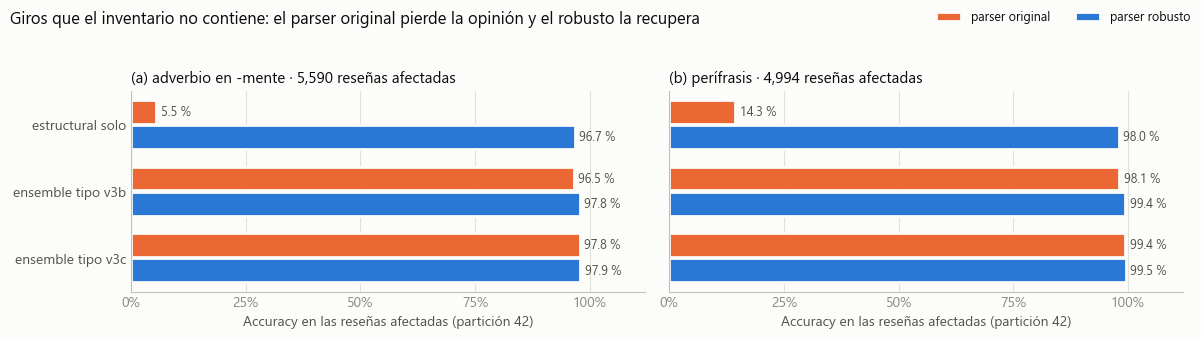

In [49]:
# Accuracy en las reseñas afectadas (partición 42): parser original frente a robusto, para cada giro
COLOR_PARSER = {'original': NARANJA, 'robusto': AZUL}
FILAS_GRAFICA = [('estructural solo', 'estructural solo · afectadas'), ('ensemble tipo v3b', 'tipo v3b · afectadas'),
                 ('ensemble tipo v3c', 'tipo v3c · afectadas')]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, m in zip(axes, ['mente', 'perifrasis']):
    yy = np.arange(len(FILAS_GRAFICA))[::-1]
    for desplazamiento, k in [(0.19, 'original'), (-0.19, 'robusto')]:
        vals = [100 * giros.loc[(SEED, MODOS_GIROS[m], k), col] for _, col in FILAS_GRAFICA]
        ax.barh(yy + desplazamiento, vals, height=0.36, color=COLOR_PARSER[k], label=f'parser {k}',
                edgecolor=SUPERFICIE, linewidth=2)
        for yi, v in zip(yy + desplazamiento, vals):
            ax.text(v + 1, yi, f'{v:.1f} %', va='center', fontsize=9, color=TINTA2)
    n_af = int(giros.loc[(SEED, MODOS_GIROS[m], 'original'), 'reseñas afectadas'])
    ax.set_title(f'{MODOS_GIROS[m]} · {n_af:,} reseñas afectadas', color=TINTA, fontsize=11)
    ax.set_yticks(yy, [nombre for nombre, _ in FILAS_GRAFICA])
    ax.set_xlim(0, 112); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
    ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
    ax.set_xlabel('Accuracy en las reseñas afectadas (partición 42)')
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper right', ncol=2, frameon=False, fontsize=9)
fig.suptitle('Giros que el inventario no contiene: el parser original pierde la opinión y el robusto la recupera', x=0.01,
             ha='left', fontsize=12, color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

**Resultado** (accuracy; partición 42 y, entre paréntesis, 2024):
- **El componente solo, con el parser original, se hunde.** Con adverbios en *-mente* acierta 0.4816 (0.4847) de todas las reseñas y el 5.5 % de las 5 590 afectadas; con la perífrasis, 0.5554 (0.5582). Al no reconocer la opinión decisiva, sus rasgos describen otra reseña y el HistGradientBoosting se equivoca con confianza. **Con el parser robusto** se queda en 0.9065 (0.9104) con los adverbios y 0.9038 (0.9069) con la perífrasis, casi como sin perturbar (0.9076); la perífrasis le cuesta algo más porque formas como *"termina viéndose"* no entran en R2 (la raíz *ve-* no está en la lista) y solo las recupera R3 cuando el aspecto está en el mismo fragmento.
- **Ensembles con el parser original.** El tipo v3b pierde 0.57 pts (2.38) con los adverbios y 0.52 (2.12) con la perífrasis; en las reseñas afectadas por los adverbios baja al 96.5 % (92.8 %), al nivel de v1, que no usa el parser (96.5 %), o por debajo. El daño depende del peso que la rejilla da al estructural: 0.3 con la partición 42 y 0.4 con la 2024. El tipo v3c con el parser original resiste con la 42 (pierde 0.10 y 0.02 pts), porque ahí `stk_nb6_anc` tiene peso 0.2 y, junto con `est_lr`, compensa al estructural; con la 2024 la rejilla le da peso 0 y pierde lo mismo que el tipo v3b (2.38 y 2.12 pts).
- **Ensembles con el parser robusto.** Ni el tipo v3b ni el tipo v3c pierden más de 0.10 pts en ningún caso: v3c queda en 0.9185 (0.9169) con los adverbios y 0.9191 (0.9173) con la perífrasis, frente a 0.9192 (0.9179) sin perturbar.
- **Comparación con el desarrollo.** Coinciden las cifras del componente (original con adverbios ≈ 0.48; robusto 0.907 / 0.910 con los adverbios y 0.904 / 0.907 con la perífrasis) y las de v3c robusto (0.919 / 0.917), y también la del tipo v3b con el parser original en la partición 2024 (0.894). Con la 42 esta última difiere (desarrollo: 0.903; aquí 0.9123) porque allí la rejilla daba 0.4 de peso al estructural: el stacking del arnés de desarrollo, calculado con otros hilos de BLAS, era algo peor (sección 8) y cambia el reparto.

**Conclusión.** El parser robusto elimina el modo de fallo concreto que motivó el cambio, sin costar nada en train (sección 10.1) y con cualquier reparto de pesos; la diversidad de componentes de v3c es una segunda protección, que depende de cómo caigan los pesos. Recordatorio: R1 y R2 se escribieron para estas familias de giros, así que la prueba mide el riesgo eliminado, no la generalización a giros arbitrarios (para eso está la sección 13.2).

## 14. ¿Dónde mejora v3c? Errores por familia de plantilla
Usamos las familias de la sección 9 (definidas con el parser original) para ver en qué reseñas cambian los aciertos (OOF, partición 42). *Coherente* = una sola opinión o todas del mismo signo; para ellas y para las mixtas A se separa además cómo termina la reseña. La tabla incluye el v3b enviado (parser original, pesos de la sección 12) como referencia.

In [50]:
F['acierto_v3c'] = pred_v3c == y
F['acierto_v3b'] = pred_v3b_original == y            # v3b enviado (parser original)
F['acierto_base'] = pred_base == y
CORTO = {FAM_A: 'mixta A', FAM_B: 'mixta B', FAM_COH: 'coherente', 'neutral': 'neutral',
         'sin opinión detectada': 'sin opinión detectada'}
grupo = [CORTO[f] + (f' · {NOMBRE_FINAL[fi]}' if f in (FAM_A, FAM_COH) else '') for f, fi in zip(F.familia, F.final)]
errores = (pd.DataFrame({'grupo': grupo, 'v1': ~F.acierto_v1, 'v3b': ~F.acierto_v3b, 'v3c': ~F.acierto_v3c})
           .groupby('grupo').agg(n=('v1', 'size'), errores_v1=('v1', 'sum'), errores_v3b=('v3b', 'sum'),
                                 errores_v3c=('v3c', 'sum')))
errores['cambio_v3c_frente_a_v1'] = errores.errores_v3c - errores.errores_v1
errores = errores.sort_values('errores_v1', ascending=False)
errores.loc['TOTAL'] = errores.sum()
display(errores)
n_err_B = int((~F.acierto_v3c & (F.familia == FAM_B)).sum())
print(f'Errores de v3c en mixtas B: {n_err_B} de {int((~F.acierto_v3c).sum())} '
      f'({100 * n_err_B / (~F.acierto_v3c).sum():.0f} %)')

,n,errores_v1,errores_v3b,errores_v3c,cambio_v3c_frente_a_v1
grupo,,,,,
mixta B,2042,957,927,923,-34
coherente · relleno después,370,54,12,8,-46
mixta A · termina en la opinión,4144,27,8,8,-19
coherente · termina en la opinión,1690,26,2,4,-22
mixta A · cierre ambivalente,45,22,23,17,-5
mixta A · relleno después,81,11,4,2,-9
coherente · cierre ambivalente,33,10,5,5,-5
neutral,3576,9,2,2,-7
sin opinión detectada,19,1,1,1,0


Errores de v3c en mixtas B: 923 de 970 (95 %)


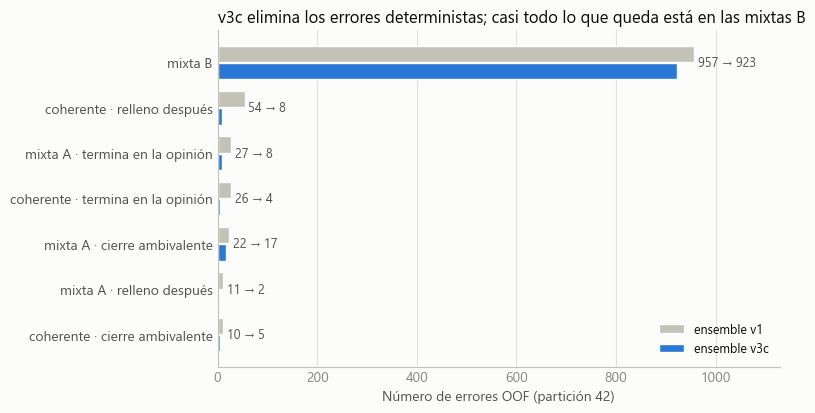

In [51]:
d = errores.drop('TOTAL')
d = d[(d.errores_v1 >= 10) | (d.errores_v3c >= 10)].sort_values('errores_v1')
fig, ax = plt.subplots(figsize=(8, 0.42 * len(d) + 1.3))
yy = np.arange(len(d))
ax.barh(yy + 0.19, d.errores_v1, height=0.36, color=GRIS, label='ensemble v1', edgecolor=SUPERFICIE, linewidth=1)
ax.barh(yy - 0.19, d.errores_v3c, height=0.36, color=AZUL, label='ensemble v3c', edgecolor=SUPERFICIE, linewidth=1)
for i, (a, b) in enumerate(zip(d.errores_v1, d.errores_v3c)):
    ax.text(max(a, b) + 8, i, f'{a} → {b}', va='center', fontsize=9, color=TINTA2)
ax.set_yticks(yy, d.index)
ax.set_xlim(0, d[['errores_v1', 'errores_v3c']].values.max() * 1.18)
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('Número de errores OOF (partición 42)')
ax.set_title('v3c elimina los errores deterministas; casi todo lo que queda está en las mixtas B', color=TINTA)
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

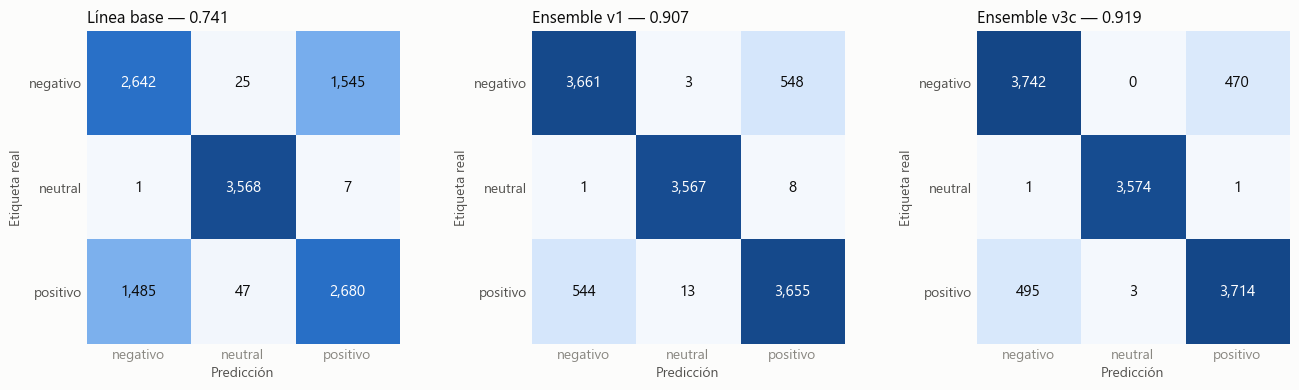

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
graficar_confusion(axes[0], y, pred_base, f'Línea base — {accuracy_score(y, pred_base):.3f}')
graficar_confusion(axes[1], y, pred_v1, f'Ensemble v1 — {accuracy_score(y, pred_v1):.3f}')
graficar_confusion(axes[2], y, pred_v3c, f'Ensemble v3c — {accuracy_score(y, pred_v3c):.3f}')
plt.tight_layout(); plt.show()

La mejora sobre v1 viene sobre todo de celdas deterministas, igual que en v3b: reseñas coherentes seguidas de relleno (54 → 8 errores; v3b: 12), coherentes que terminan en opinión (26 → 4; v3b: 2), mixtas A que terminan en opinión (27 → 8) o con relleno (11 → 2) y neutrales (9 → 2). Con los pesos de la sección 12, v3c comete 970 errores OOF frente a 984 de v3b y 1117 de v1; la diferencia con v3b se reparte entre celdas pequeñas (coherentes con relleno: 12 → 8; mixtas A con cierre ambivalente: 23 → 17; mixtas A con relleno: 4 → 2) y las mixtas B (927 → 923), que se comportan como ruido. Después de v3c, el **95 %** de los errores restantes está en las mixtas B.

## 15. Iteraciones del modelo
Resumen de todo el recorrido con los números de esta ejecución (accuracy OOF de la partición 42; para los ensembles, también la selección anidada). Las filas 9 y 10 son los componentes de los modelos v3a y v3b ya enviados a Kaggle, con los pesos elegidos aquí con el procedimiento de la sección 12 (el v3a enviado eligió los suyos con la media de dos particiones: *svc_pal_car 0.4 · estructural 0.3 · stk_nb6_anc 0.3*). La columna de Kaggle es la accuracy pública de cada envío.

,accuracy_oof,seleccion_anidada,kaggle_publico
modelo,,,
0. Línea base: TF-IDF texto completo + LR,0.7408,,
1. Bloques + palabras + LR (lr_palabras),0.8951,,
2. Bloques + palabras y caracteres + LR,0.8981,,
3. Bloques + palabras y caracteres + SVM,0.8998,,
4. Stacking por bloques + HGB,0.9012,,
5. Ensemble v1 (4 componentes),0.9069,0.9067,0.90111
"6. Componente estructural, parser original (solo)",0.9075,,
7. Componente est_lr (solo),0.9126,,
8. Componente stk_nb6_anc (solo),0.9112,,


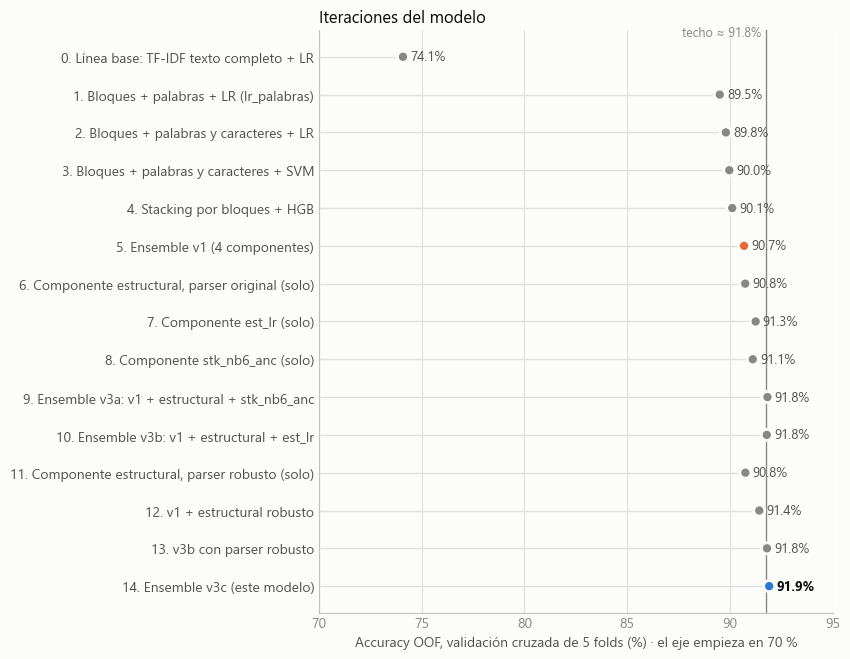

In [53]:
def fila_variante(nombre):
    return variantes_42.loc[nombre, 'accuracy_oof'], variantes_42.loc[nombre, 'seleccion_anidada']


iteraciones = [
    ('0. Línea base: TF-IDF texto completo + LR', acc_oof(P_base), np.nan, ''),
    ('1. Bloques + palabras + LR (lr_palabras)', acc_oof(OOF['lr_palabras']), np.nan, ''),
    ('2. Bloques + palabras y caracteres + LR', acc_oof(OOF['lr_pal_car']), np.nan, ''),
    ('3. Bloques + palabras y caracteres + SVM', acc_oof(OOF['svc_pal_car']), np.nan, ''),
    ('4. Stacking por bloques + HGB', acc_oof(OOF['stacking']), np.nan, ''),
    ('5. Ensemble v1 (4 componentes)', oof_v1, anidado_v1.accuracy_parte_no_vista.mean(), '0.90111'),
    ('6. Componente estructural, parser original (solo)', acc_oof(OOF['estructural_original']), np.nan, ''),
    ('7. Componente est_lr (solo)', acc_oof(OOF['est_lr']), np.nan, ''),
    ('8. Componente stk_nb6_anc (solo)', acc_oof(OOF['stk_nb6_anc']), np.nan, ''),
    ('9. Ensemble v3a: v1 + estructural + stk_nb6_anc', *fila_variante('v3a: v1 + estructural original + stk_nb6_anc'), '0.90555'),
    ('10. Ensemble v3b: v1 + estructural + est_lr', *fila_variante('v3b: v1 + estructural original + est_lr'), '0.90777'),
    ('11. Componente estructural, parser robusto (solo)', acc_oof(OOF['estructural']), np.nan, ''),
    ('12. v1 + estructural robusto', *fila_variante('v1 + estructural robusto'), ''),
    ('13. v3b con parser robusto', *fila_variante('v3b con parser robusto'), ''),
    ('14. Ensemble v3c (este modelo)', oof_v3c, anidado_v3c.accuracy_parte_no_vista.mean(), '(por enviar)'),
]
tabla_iteraciones = pd.DataFrame(iteraciones, columns=['modelo', 'accuracy_oof', 'seleccion_anidada', 'kaggle_publico']).set_index('modelo')
display(tabla_iteraciones.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}'}, na_rep=''))

fig, ax = plt.subplots(figsize=(8.6, 0.36 * len(tabla_iteraciones) + 1.3))
ypos = np.arange(len(tabla_iteraciones))[::-1]
vals = tabla_iteraciones.accuracy_oof.values
colores = [AZUL if 'v3c' in m else (NARANJA if 'v1 (' in m else TENUE) for m in tabla_iteraciones.index]
ax.hlines(ypos, 0, 100 * vals, color=REJILLA, linewidth=1)
ax.scatter(100 * vals, ypos, s=64, color=colores, zorder=3, edgecolor=SUPERFICIE, linewidth=2)
for yy, v, m in zip(ypos, vals, tabla_iteraciones.index):
    ax.text(100 * v + 0.35, yy, f'{100 * v:.1f}%', va='center', fontsize=9.5,
            color=TINTA if 'v3c' in m else TINTA2, fontweight='bold' if 'v3c' in m else 'normal')
inicio = 5 * np.floor((100 * vals.min() - 2) / 5)
ax.axvline(100 * techo, color=TENUE, linewidth=1)
ax.text(100 * techo - 0.2, ypos[0] + 0.55, f'techo ≈ {100 * techo:.1f}%', color=TENUE, fontsize=9, ha='right')
ax.set_yticks(ypos, tabla_iteraciones.index)
ax.set_xlim(inicio, 95); ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel(f'Accuracy OOF, validación cruzada de 5 folds (%) · el eje empieza en {inicio:.0f} %')
ax.set_title('Iteraciones del modelo', color=TINTA)
plt.tight_layout(); plt.show()

## 16. Experimentos que no funcionaron
Todos medidos con la misma validación cruzada (partición 42) y, para los ensembles, con la selección anidada de pesos. Se resumen para documentar el proceso; ninguno forma parte del modelo final.

| Experimento | Resultado | Conclusión |
|---|---|---|
| Otros clasificadores sobre los mismos bloques de palabras | LinearSVC 0.896 · LR 0.895 · Ridge 0.895 · SGD 0.888 · MultinomialNB 0.871 · ComplementNB 0.837 · kNN coseno 0.779 · ExtraTrees 0.783 (0.827 con χ² k=3000) · RandomForest 0.743 (0.777) · HGB denso χ² k=3000 0.888 · árbol de decisión 0.652 · LSA(300)+HGB 0.767 · LSA+LR 0.776 | Los lineales dominan sobre TF-IDF disperso; los árboles necesitan pocos rasgos densos (por eso funcionan como meta-modelo o sobre rasgos estructurales) |
| SMOTE implementado a mano (punto sintético = interpolación entre una reseña y un vecino de su clase en el espacio TF-IDF; sonda: LR sobre bloques = 0.8951), en dos variantes: balancear las clases y añadir +50 % de sintéticos por clase | balancear: 0.8942 · +50 % de sintéticos: 0.8927 | Empeora: las clases ya están casi balanceadas y los puntos sintéticos mezclan n-gramas de reseñas distintas |
| Variantes de preprocesamiento (sonda: LR sobre bloques = 0.8951) | mantener tildes 0.8877 · corregir typos 0.8953 · stemming 0.8950 · typos + stemming 0.8956 · quitar stopwords 0.8911 · marcar negación 0.8928 · números → token 0.8952 · TF-IDF binario 0.8937 · sin IDF 0.8878 · sin `sublinear_tf` 0.8947 · `min_df` 1 / 5: 0.8948 / 0.8938 · `max_df` 0.5: 0.8942 · norma L1 0.868 | Diferencias ≤ 0.05 pts o peores: los n-gramas de caracteres ya cubren typos y morfología |
| Quitar del train las reseñas con etiqueta sospechosa (*confident learning*, umbrales 0.15 / 0.3 / 0.45) | 0.891 / 0.890 / 0.885 | Empeora: el ruido (mixtas B) también está en `eval` y no se puede "limpiar" |
| Búsqueda aleatoria de hiperparámetros de los 3 lineales (87 configuraciones) | ±0.1 pts | Los valores elegidos ya eran óptimos |
| HGB ajustado como meta-modelo del stacking (lr 0.03, 150 iteraciones, `max_features` 0.7) | el stacking solo sube de 0.898 a 0.9025, pero el ensemble no mejora: OOF 0.9061–0.9062 y anidado 0.9038–0.9052 (v1: 0.9064) | El HGB ajustado no mejora el ensemble: mejorar un miembro no mejora la mezcla |
| v2: stacking + ~15 rasgos estructurales del detector de cláusulas antiguo | ensemble 0.9067 OOF / 0.9052 anidado | Rasgos demasiado ruidosos; la versión buena es `est_lr` |
| Meta-modelo de 2.º nivel (LR / HGB) sobre las OOF + conector + tipo de cierre | 0.900–0.906 | No supera al voto ponderado |
| Árboles sobre rasgos seleccionados con χ² (ExtraTrees 0.827, RandomForest 0.777, HGB denso hasta 0.888 con k=3000) y el mejor (HGB) como miembro extra del ensemble | peso óptimo 0 en la rejilla (anidado 0.9037) | No aportan información que no tengan ya los lineales y el stacking |
| kNN / paráfrasis | similitud coseno mediana con el vecino más cercano 0.27; 1-NN acierta 50 % en las mixtas difíciles | No hay reseñas casi duplicadas que aprovechar |
| Rasgos aspecto × polaridad en mixtas aditivas | ~53 % | Azar (luego explicado: son mixtas B) |
| Autoentrenamiento del clasificador de cláusulas desde la etiqueta del documento | colapsó: regla "conector fuerte → última opinión" 0.694 frente a 0.861 del detector antiguo | La etiqueta del documento solo coincide ~72 % con la de la cláusula |
| Una ronda de autoentrenamiento sobre el clasificador de fragmentos de `est_lr` | sin cambio (fold 0: 0.9021 → 0.9021) | La supervisión débil ya cubre casi todo |
| `est_lr` con HGB en lugar de LR como meta-modelo | componente 0.9093 (LR: 0.9127); ensemble +0.43 pts (LR: +0.52) | Sobreajusta el grupo aleatorio |
| Hipótesis para predecir las mixtas B: orden, posición, aspecto, intensidad, identidad del cierre, mayoría, TF-IDF dentro del subconjunto (LR, árbol, HGB; 100 permutaciones) | 0.47–0.53; permutaciones p = 0.22–0.96; "gana la última" 49.9 % en las que terminan en relleno o cierre | Ruido de etiqueta: no hay señal que aprender |
| NB-LR (Wang & Manning) como componente plano | 0.9000 solo (el mejor lineal), pero ensemble anidado −0.20 pts | Muy correlacionado con los lineales existentes |
| Tokens conjuntados con el conector o la posición · pares de palabras entre cláusulas (hashing) · rangos de n-gramas por bloque | ensemble anidado −0.08 a −0.27 · −0.27 · −0.07 pts | Sobreajustan |
| Reglas del parser robusto por separado (desarrollo: ensemble tipo v3c, 3 particiones × selección anidada) | ganancia media sobre v1: parser original +0.92 pts · solo R1 +0.92 (en train no cambia nada) · solo R2 +0.83 · solo R3 +0.90 · las tres +1.01 | Ninguna regla mejora por separado; juntas, +0.09 pts, dentro del ruido. Se adoptan por la robustez ante giros nuevos (sección 13.3), no por el CV |

## 17. Modelo final: entrenamiento con todo `train`, guardado y recarga
El modelo final es un `VotingClassifier(voting='soft')` con los pesos elegidos en la sección 12. Incluye solo los componentes con peso mayor que cero y se entrena con las 12 000 reseñas de `train`. Todo el preprocesamiento (normalización, bloques, parser robusto, corrector, segmentación, bloques anclados, TF-IDF y bolsas binarias) está dentro de los estimadores, así que el objeto guardado recibe **texto crudo**. `est_lr` usa `semilla_interna = 1000` para su cross-fitting interno y `stk_nb6_anc` sus semillas fijas (cross-fitting 11, CV del stacking 1, HGB 0). `eval.csv` no se usa en ningún momento del entrenamiento. El modelo se guarda con `joblib` (`compress=3`) y se recarga para comprobar que reproduce exactamente las predicciones.

In [54]:
FABRICAS = {**FABRICAS_V1, 'estructural': modelo_estructural_robusto, 'est_lr': modelo_est_lr,
            'stk_nb6_anc': modelo_stk_nb6_anc}
PESOS = {n: w for n, w in pesos_v3c.items() if w > 0}
miembros = [(n, FABRICAS[n]()) for n in PESOS]
modelo_final = VotingClassifier(miembros, voting='soft', weights=list(PESOS.values()), n_jobs=N_JOBS)

t0 = time.time()
modelo_final.fit(X, y)
segundos_ajuste = time.time() - t0
print(f'Entrenado en {segundos_ajuste:.0f} s con miembros {list(PESOS)} y pesos {list(PESOS.values())}')

joblib.dump(modelo_final, 'modelo_v3c.joblib', compress=3)
tamano_mb = os.path.getsize('modelo_v3c.joblib') / 2**20
print(f'Modelo guardado en modelo_v3c.joblib ({tamano_mb:.1f} MB)')

Entrenado en 95 s con miembros ['lr_pal_car', 'svc_pal_car', 'estructural', 'est_lr', 'stk_nb6_anc'] y pesos [0.1, 0.2, 0.2, 0.3, 0.2]


Modelo guardado en modelo_v3c.joblib (15.5 MB)


In [55]:
pred_eval = modelo_final.predict(evaluacion.text.values)
proba_eval = modelo_final.predict_proba(evaluacion.text.values)

modelo_cargado = joblib.load('modelo_v3c.joblib')
pred_recarga = modelo_cargado.predict(evaluacion.text.values)
assert (pred_recarga == pred_eval).all()
assert np.allclose(modelo_cargado.predict_proba(evaluacion.text.values), proba_eval)
print('El modelo recargado reproduce exactamente las predicciones (y probabilidades) de eval.csv')
modelo_cargado.predict(['La batería es excelente, pero la cámara resultó decepcionante.',
                        'La cámara resultó decepcionante. Aun así, la batería es excelente.',
                        'Me llegó en tres días. Trae garantía de un año y usa dos pilas AA.'])

El modelo recargado reproduce exactamente las predicciones (y probabilidades) de eval.csv


array(['negativo', 'positivo', 'neutral'], dtype=object)

**Cómo cargar `modelo_v3c.joblib` en otra sesión.** `joblib` guarda referencias a las funciones, clases y tablas globales del notebook, no su código. Antes de `joblib.load('modelo_v3c.joblib')` hay que ejecutar, en este orden y **enteras**, las 15 celdas de definiciones (en los metadatos del notebook llevan la etiqueta `definiciones`); todas tardan unos segundos y ninguna entrena modelos:

| Sección | Celda (primera línea o contenido) |
|---|---|
| 1 | configuración: `import os` … (hilos, importaciones, `CLASES`, `CV`) |
| 2 | carga de datos: `train = pd.read_csv(…)` (también lee `eval.csv` y `sample_submission.csv`) |
| 3 | `def normalizar(texto)` |
| 5 | definiciones de conectores: `FUERTES = […]`, `oraciones`, `clausulas` (la celda que sigue, el análisis, no hace falta) |
| 6 | `def _regex_conectores(lista)` … `class Bloques` |
| 7 | `def tfidf_palabras()` … fábricas de v1 |
| 9 | corrector de typos e inventario (`# ---- corrector de typos …`) y parser (`def oraciones_plantilla(t)` …) |
| 10 | `CONECTORES_RASGO = […]` … `class RasgosPlantilla`, `modelo_estructural` |
| 10.1 | `# ---- parser robusto: reglas genéricas R1-R3` … `class RasgosRobustos` |
| 11.1 | las 3 celdas de `est_lr`: segmentación y léxico, clasificador de fragmentos, rasgos y `ComponenteEstLR` |
| 11.2 | `# ---- NB-LR (uno contra el resto)` y `# ---- bloques anclados en las opiniones` |

Hay que ejecutarlas **enteras**: si falta una entrada de una tabla global (por ejemplo `FR_TIPO` o `RE_AMBIVALENTE_ANCLADOS`), el modelo no da error, sino que cambia sus predicciones sin avisar. Lo comprobamos aparte en un proceso nuevo: ejecutando solo esas 15 celdas, el modelo recargado reproduce exactamente `submission_v3c.csv`. (Alternativa más lenta: ejecutar el notebook hasta el final de la sección 11.2 con `VERIFICAR_2024 = False`.)

**Cómo ve el modelo una reseña.** Para la sustentación es útil abrir la caja: probabilidades de cada componente y clase de cada fragmento según el clasificador de fragmentos del modelo final.

In [56]:
def explicar(texto):
    print(texto, '\n')
    probas = {n: est.predict_proba([texto])[0] for n, est in zip(PESOS, modelo_final.estimators_)}
    probas['ENSEMBLE v3c'] = modelo_final.predict_proba([texto])[0]
    display(pd.DataFrame(probas, index=CLASES).T.round(3))
    if 'est_lr' in PESOS:
        est_lr_final = modelo_final.estimators_[list(PESOS).index('est_lr')]
        segs = segmentar(normalizar(texto))
        Pf = est_lr_final.fragmentos_.predecir_fragmentos([d['texto'] for d in segs])
        for d, p in zip(segs, Pf):
            print(f"  {CLASES_FRAGMENTO[p.argmax()]:>6s} ({p.max():.2f})  [{d['tipo_con']}] {d['texto']}")

explicar(X[ejemplos[0]])

Comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa. La verdad sea dicha, el boton de encendido me parecio incomodo en el uso real, lo he estado usando en la oficina todas las tardes. Aun asi, tuve que escribirles un par de veces por una duda de configuracion y el soporte tecnico se sintio funcional al final de cuentas. 



,negativo,neutral,positivo
lr_pal_car,0.019,0.000,0.981
svc_pal_car,0.046,0.000,0.954
estructural,0.000,0.000,1.000
est_lr,0.041,0.001,0.959
stk_nb6_anc,0.000,0.000,1.000
ENSEMBLE v3c,0.023,0.000,0.977


  sin_op (1.00)  [ninguno] comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa.
      A- (0.98)  [ninguno] la verdad sea dicha el boton de encendido me parecio incomodo en el uso real
  sin_op (1.00)  [ninguno] lo he estado usando en la oficina todas las tardes.
  sin_op (0.95)  [fuerte] aun asi tuve que escribirles un par de veces por una duda de configuracion
      A+ (0.99)  [y] y el soporte tecnico se sintio funcional al final de cuentas.


## 18. Submission
Archivo `submission_v3c.csv` con el formato `id,answer` de `sample_submission.csv`. Validamos columnas, número de filas, ids (mismo orden) y valores, y comparamos con los envíos anteriores: `submission_v3b.csv` (v3b, **0.90777** en la tabla pública) y `submission.csv` (v1, **0.90111**). Los archivos anteriores solo se leen.

In [57]:
submission = pd.DataFrame({'id': evaluacion.id, 'answer': pred_eval})
assert list(submission.columns) == list(muestra.columns) == ['id', 'answer']
assert len(submission) == len(muestra) == 3000
assert (submission.id.values == muestra.id.values).all() and submission.id.is_unique
assert submission.answer.isin(CLASES).all() and submission.answer.notna().all()
submission.to_csv('submission_v3c.csv', index=False)
print('submission_v3c.csv generado:', submission.shape)

distribucion = pd.DataFrame({'eval (predicho v3c)': submission.answer.value_counts(normalize=True),
                             'train (real)': train.label.value_counts(normalize=True)}).round(3)
display(distribucion)

CAMBIOS, CRUCES = {}, {}
for archivo, version in [('submission_v3b.csv', 'v3b'), ('submission.csv', 'v1')]:
    anterior = pd.read_csv(archivo)                   # envíos anteriores: solo se leen para comparar
    assert (anterior.id.values == submission.id.values).all()
    CAMBIOS[version] = anterior.answer.values != submission.answer.values
    print(f'Predicciones que cambian respecto a {archivo} ({version}): {CAMBIOS[version].sum()} de {len(submission)} '
          f'({100 * CAMBIOS[version].mean():.1f} %)')
    CRUCES[version] = pd.crosstab(pd.Series(anterior.answer.values, name=f'{archivo} ({version})'),
                                  pd.Series(submission.answer.values, name='submission_v3c.csv'))
    display(CRUCES[version])
submission.head()

submission_v3c.csv generado: (3000, 2)


,eval (predicho v3c),train (real)
negativo,0.363,0.351
neutral,0.276,0.298
positivo,0.361,0.351


Predicciones que cambian respecto a submission_v3b.csv (v3b): 88 de 3000 (2.9 %)


submission_v3c.csv,negativo,neutral,positivo
submission_v3b.csv (v3b),,,
negativo,1053,0,51
neutral,0,828,1
positivo,36,0,1031


Predicciones que cambian respecto a submission.csv (v1): 182 de 3000 (6.1 %)


submission_v3c.csv,negativo,neutral,positivo
submission.csv (v1),,,
negativo,1001,1,85
neutral,2,822,3
positivo,86,5,995


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Respecto de `submission_v3b.csv` cambian **88** de las 3 000 predicciones (2.9 %), casi todas entre `positivo` y `negativo` (87 de 88: 51 pasan de negativo a positivo y 36 al revés); respecto de `submission.csv` (v1) cambian 182 (6.1 %; 171 entre las dos clases polares). Es lo esperable: v3c y v3b deciden casi igual, y los dos se separan de v1 en las reseñas mixtas. En las OOF de train, v3c y v3b discrepan en acierto en 334 reseñas de 12 000 (2.8 %) y v3c y v1 en 621 (5.2 %), proporciones del mismo orden. La distribución de clases predicha es parecida a la de train, con algo menos de neutrales (27.6 % frente a 29.8 %).

**Ojo con la tabla pública de Kaggle:** solo usa el 30 % de `eval` (900 reseñas), con un error estándar de ≈ ±1 punto de accuracy. Si los 88 cambios frente a v3b se reparten al azar, en la parte pública caerán unos 26: el resultado público de v3c quedará muy cerca del de v3b (0.90777) y no servirá para distinguirlos. La validación cruzada con dos particiones y las pruebas de estrés son la evidencia más fiable.

## 19. Cumplimiento de las reglas del proyecto
La celda siguiente recorre el modelo final ya entrenado, lista **todas** las clases que contiene y comprueba que solo hay estimadores y transformadores de scikit-learn o código propio de este notebook (reglas, regex, léxicos), y que no se cargó ninguna librería prohibida.

In [58]:
def clases_del_modelo(objeto):
    vistos, tipos = set(), set()
    def recorrer(o):
        if id(o) in vistos or isinstance(o, (str, bytes, int, float, bool, type(None), np.ndarray, np.generic)):
            return
        vistos.add(id(o))
        modulo = type(o).__module__
        if modulo.startswith('sklearn') or modulo == '__main__':
            tipos.add(f'{modulo}.{type(o).__name__}')
            for v in getattr(o, '__dict__', {}).values():     # objetos compilados (Cython) no tienen __dict__
                recorrer(v)
        elif isinstance(o, (list, tuple, set)):
            for v in o:
                recorrer(v)
        elif isinstance(o, dict):
            for v in list(o.values())[:1000]:       # los vocabularios (palabra -> índice) no contienen objetos
                recorrer(v)
    recorrer(objeto)
    return sorted(tipos)

tipos = clases_del_modelo(modelo_cargado)
print('Clases presentes en el modelo final:')
for t in tipos:
    print('  ', t)

PROHIBIDAS = ['torch', 'tensorflow', 'keras', 'transformers', 'sentence_transformers', 'gensim', 'fasttext', 'spacy',
              'stanza', 'flair', 'xgboost', 'lightgbm', 'catboost', 'sklearn.neural_network']
assert all(t.startswith('sklearn.') or t.startswith('__main__.') for t in tipos)
assert not any('MLP' in t or 'neural' in t.lower() for t in tipos)
cargadas = [m for m in PROHIBIDAS if m in sys.modules]
assert not cargadas, cargadas
print('\nNinguna librería prohibida está cargada:', ', '.join(PROHIBIDAS))

Clases presentes en el modelo final:
   __main__.Bloques
   __main__.BloquesAnclados
   __main__.ClasificadorFragmentos
   __main__.ComponenteEstLR
   __main__.CorrectorTypos
   __main__.NBLR
   __main__.RasgosRobustos
   __main__.VectorizadorFragmentos
   sklearn._loss.link.Interval
   sklearn._loss.link.MultinomialLogit
   sklearn._loss.loss.HalfMultinomialLoss
   sklearn.calibration.CalibratedClassifierCV
   sklearn.calibration._CalibratedClassifier
   sklearn.calibration._SigmoidCalibration
   sklearn.compose._column_transformer.ColumnTransformer
   sklearn.ensemble._hist_gradient_boosting.binning._BinMapper
   sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier
   sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor
   sklearn.ensemble._stacking.StackingClassifier
   sklearn.ensemble._voting.VotingClassifier
   sklearn.feature_extraction.text.CountVectorizer
   sklearn.feature_extraction.text.TfidfTransformer
   sklearn.feature_ext

**Lista de verificación**
- ✅ **Solo ML clásico de scikit-learn:** `TfidfVectorizer` y `CountVectorizer` (bolsa de palabras y n-gramas de palabras y caracteres), `LogisticRegression`, `LinearSVC` + `CalibratedClassifierCV`, `HistGradientBoostingClassifier`, `StackingClassifier`, `VotingClassifier`, `StandardScaler`, `ColumnTransformer`, `Pipeline`. NB-LR (`NBLR`) es código propio: una `LogisticRegression` sobre rasgos binarios escalados con las razones de log-conteos de Naive Bayes. El resto es ingeniería de rasgos propia: regex, reglas morfológicas, léxicos escritos a mano y un corrector de typos por distancia de edición.
- ✅ **Sin redes neuronales** (tampoco `MLPClassifier`), deep learning, transformers, embeddings preentrenados, modelos de lenguaje ni xgboost / lightgbm / catboost (comprobado arriba).
- ✅ **`eval.csv` no se usa para entrenar, ajustar ni analizar nada en este notebook:** se lee en la sección 2 solo para comprobar su formato y en las secciones 17-18 solo para predecir. Vocabularios, IDF, razones NB, léxicos aprendidos (polaridad de claves, polaridad de adjetivos, adjetivos excluidos del respaldo R3), detector de opinión, corrector de typos y todos los modelos se ajustan solo con `train` (y, en la validación cruzada, solo con el fold de entrenamiento).
- ✅ **Validación sin fuga:** todas las OOF salen de `cross_val_predict` o de `oof_por_fold` (equivalente); `est_lr` y `stk_nb6_anc` hacen su cross-fitting dentro de `fit`; los pesos del ensemble se validan con selección anidada y con una segunda partición.
- ⚠️ **Sesgo de diseño declarado:** el inventario del parser y el léxico de frases se escribieron a mano mirando reseñas de train (sección 20).
- ⚠️ **Transparencia sobre el parser robusto:** su motivación vino de un diagnóstico de solo lectura de la cobertura del parser en los textos de `eval` hecho fuera de este notebook (sección 10.1). La corrección no contiene ninguna palabra ni frase de `eval`: son reglas morfológicas genéricas validadas solo con train (secciones 10.1, 13 y 13.3).

## 20. Conclusiones y limitaciones

**Conclusiones**
- **De 0.7408 a 0.9192 de accuracy OOF sin salir del ML clásico.** Las mejoras no vinieron de cambiar de clasificador, sino de **entender cómo se generaron los datos** y llevar esa estructura a la representación: primero el orden respecto a los conectores (bloques, v1), después la familia de plantilla de cada opinión (v3a, v3b) y, por último, la robustez del parser ante giros que train no contiene (v3c).
- **v3c mejora a v1 de forma consistente:** +1.02 pts de accuracy con selección anidada en la partición 42 y +1.12 en la 2024 (semilla 123), y +0.99 pts de media (entre +0.76 y +1.12) sobre 2 particiones × 3 semillas de selección, con McNemar anidado significativo en las 6 combinaciones (sección 13.1).
- **En validación cruzada, v3c empata con v3b.** Su selección anidada es igual con la partición 42 y +0.10 pts mayor con la 2024, y su ganancia media sobre v1 es +0.99 pts frente a +1.03 de v3b con el mismo parser. Los tres componentes nuevos son redundantes: ninguno tiene un aporte marginal distinguible de cero dentro de v3c, y el reparto de pesos cambia con la partición (con la 2024, `stk_nb6_anc` queda con peso 0).
- **Lo que aporta v3c es robustez.** El parser robusto apenas cambia el resultado en train (0.9076 frente a 0.9075 de accuracy OOF del componente), pero cuando las opiniones llevan un adverbio en *-mente* o una perífrasis verbal evita que el componente estructural se hunda (de 0.4816 a 0.9065 de accuracy con los adverbios) y que arrastre al ensemble: el tipo v3b con el parser original pierde hasta 2.38 pts y v3c con el robusto, como mucho 0.10 (sección 13.3). Además, el modelo final (pesos elegidos con la partición 42) reparte el peso entre más componentes que fallan de forma distinta (el estructural pesa 0.2), lo que lo protege también cuando el parser pierde opiniones (sección 13.2).
- **Lo que queda es casi todo ruido:** tras v3c, el 95 % de los errores están en las mixtas B.
- **Qué esperar en `eval`.** La ganancia del CV es una cota optimista: con el parser algo degradado (prueba de estrés 1, nivel leve) baja a +0.88 pts, y el sesgo de diseño y el ruido numérico restan unas décimas más. En la tabla pública, v3b ganó +0.67 pts a v1 (0.90777 frente a 0.90111), dentro de la estimación prudente de +0.6 a +0.9 pts que se hizo para él. Para v3c cabe esperar lo mismo dentro del ruido de las 900 reseñas públicas, con menos riesgo si `eval` contiene giros que el inventario original no cubre.

**Limitaciones**
- **Ruido irreducible de la plantilla B.** El 17.0 % del train son reseñas mixtas con frases hechas cuya etiqueta es ~50/50. Ningún método que solo vea el texto puede acertarlas, así que el techo práctico en validación cruzada ronda **0.915–0.92** (sección 9), y v3c (0.9169 anidado con la partición 42, 0.9155 con la 2024) ya está en ese nivel. Diferencias de menos de ~0.3 pts entre ensembles son sobre todo ruido de ese grupo o ruido numérico.
- **Sesgo de diseño.** El inventario del parser (cópulas, adjetivos, frases hechas, conectores, cierres) y el léxico del clasificador de fragmentos se escribieron **a mano mirando reseñas de train**, incluidas tasas por etiqueta. La versión 2 del inventario se amplió leyendo errores OOF de la partición 42, y 35 de los 59 rasgos del componente estructural (las interacciones) se diseñaron mirando tablas por celda con etiquetas y con las OOF de v1. Todo lo que se ajusta a datos se entrena dentro de cada fold, pero esas decisiones de diseño no están anidadas en el CV, así que las estimaciones son optimistas. En el notebook v3b se acotó el efecto con análisis de sensibilidad hechos aparte (quitar las entradas añadidas a partir de errores, las de poco soporte o las interacciones): el sesgo inflaba la ganancia del estructural en unas 0.1–0.25 pts, sin explicarla. La configuración de `stk_nb6_anc` se eligió entre unas 37 variantes con la partición 42 (sección 11.2) y las reglas del parser robusto se compararon con tres particiones (sección 16): también son decisiones de diseño no anidadas.
- **Motivación del parser robusto.** Las reglas R1-R3 se escribieron después de un diagnóstico de **solo lectura** de la cobertura del parser en los textos de `eval`, hecho fuera de este notebook (sección 10.1). No contienen ninguna palabra ni frase de `eval` y se validaron solo con train, pero saber que `eval` tenía giros no cubiertos influyó en la decisión de escribirlas: es una forma leve de sesgo de diseño, y la declaramos. El parser robusto se fijó antes de construir este notebook y no se ha modificado después.
- **Cobertura del inventario.** Aun con las reglas genéricas, una reseña puede usar una construcción que el parser no reconoce (por ejemplo, perífrasis con verbos cuya raíz no está en R2). La prueba de estrés 1 (sección 13.2) mide ese riesgo de forma genérica: con el nivel leve, la ganancia de v3c sobre v1 baja de +0.99 a +0.88 pts, y con el severo a +0.80. Por eso en `eval` cabe esperar algo menos de mejora que en el CV.
- **Selección con la partición 42.** Los pesos y casi todas las decisiones de diseño se eligieron mirando esa partición; la 2024 es una verificación, no una prueba totalmente independiente. El reparto exacto de pesos no es estable (partición 42: *lr_pal_car 0.1 · svc_pal_car 0.2 · estructural 0.2 · est_lr 0.3 · stk_nb6_anc 0.2*; partición 2024: *lr_palabras 0.4 · svc_pal_car 0.1 · estructural 0.4 · est_lr 0.1*) y con 7 componentes la selección es más ruidosa que con 6 (sección 12): lo estable es que los componentes nuevos reciben la mitad o más del peso.
- **Reproducibilidad numérica.** El notebook fija 4 hilos y se reproduce exactamente en esta máquina (las celdas heredadas de v3b dan exactamente las mismas salidas que en ese notebook), pero con otra CPU o librería BLAS los decimales cambian: la OOF del stacking varió entre 0.8973 y 0.9012 según los hilos (sección 8), y eso basta para mover unas décimas la ganancia de los ensembles. Con las OOF del arnés de desarrollo (stacking con 6 hilos de BLAS) la selección anidada de v3c ganaba +1.13 pts a v1 con la partición 42, +0.87 con la 2024 y +1.04 con una tercera (`random_state=7`); aquí gana +1.02 y +1.12 pts. Incluso cambiar unas pocas predicciones de `est_lr` por los hilos movió en una prueba aparte la selección anidada de v3c con la partición 42 en 0.2 pts. Diferencias de menos de ~0.3 pts entre ensembles no son concluyentes.
- **Kaggle.** La tabla pública usa 900 reseñas (error estándar ≈ ±1 pt): no sirve para distinguir mejoras de menos de un punto. Resultados obtenidos: v1 0.90111, v3a 0.90555 y v3b 0.90777; v3c está por enviar. La clasificación final depende del 70 % privado.
- **Generalización.** El parser está hecho a la medida del generador de este corpus. Con reseñas reales (otras plantillas, ironía, opiniones sin marcadores) perdería buena parte de su ventaja: el orden y la estructura se inyectan "a mano" con reglas, una limitación de la bolsa de palabras que motiva los modelos secuenciales de la Parte 2.

In [59]:
# Resumen numérico de esta ejecución (los textos del notebook citan estos valores)
import json


def pts(a, b):
    return round(100 * (a - b), 2)


def tabla_json(df, decimales=4):
    # DataFrame -> dict JSON (claves de texto; los índices múltiples se unen con '/')
    salida = {}
    for k, fila in df.iterrows():
        clave = '/'.join(map(str, k)) if isinstance(k, tuple) else str(k)
        salida[clave] = {c: (round(float(v), decimales) if isinstance(v, (float, np.floating)) else
                             int(v) if isinstance(v, (int, np.integer)) else v) for c, v in fila.items()}
    return salida


an_v1, an_v3c = anidado_v1.accuracy_parte_no_vista.mean(), anidado_v3c.accuracy_parte_no_vista.mean()
mc42 = mcnemar(pred_v3c, pred_v1, y)
fam_A_op = F[(F.familia == FAM_A) & (F.final == 'opinion')]
RESUMEN = {
    'n_train': len(y), 'acc_linea_base': round(acc_oof(P_base), 4),
    'acc_componentes': {n: round(acc_oof(OOF[n]), 4) for n in NOMBRES_COMPONENTES},
    'oof_v1': round(oof_v1, 4), 'anidado_v1': round(an_v1, 4), 'pesos_v1': pesos_v1,
    'oof_v1_enviado': round(oof_v1_enviado, 4),
    'oof_v3c': round(oof_v3c, 4), 'anidado_v3c': round(an_v3c, 4), 'pesos_v3c': pesos_v3c,
    'anidado_v3c_partes': [round(float(v), 4) for v in anidado_v3c.accuracy_parte_no_vista],
    'pesos_anidado_v3c': [{n: float(fila[n]) for n in NOMBRES_V3C} for _, fila in anidado_v3c.iterrows()],
    'top10_v3c': [round(float(acc_W7[i]), 4) for i in np.argsort(-acc_W7, kind='stable')[:10]],
    'n_combinaciones_v3c': len(W7),
    'delta_42': pts(an_v3c, an_v1), 'mcnemar_42': mc42,
    'variantes_42': tabla_json(variantes_42),
    # sección 9 (parser original)
    'n_A_op': len(fam_A_op), 'pct_A_ultima_op': round(100 * fam_A_op.gana_ultima.mean(), 1),
    'n_B': len(B_mix), 'pct_B_train': round(100 * len(B_mix) / len(y), 1),
    'pct_B_ultima': round(100 * B_mix.gana_ultima.mean(), 1),
    'pct_B_ultima_op': round(100 * B_mix[B_mix.final == 'opinion'].gana_ultima.mean(), 1),
    'acc_v1_B': round(100 * B_mix.acierto_v1.mean(), 1), 'errores_min_B': int(round(errores_min_B)),
    'techo': round(techo, 3),
    'errores_v1_fuera_B': int((~F.acierto_v1 & (F.familia != FAM_B)).sum()),
    # sección 10.1 (parser robusto)
    'cobertura': tabla_json(cobertura),
    'cambia_analisis': {'total': int(cambia.sum()), 'polares': int((cambia & ~es_neutral).sum()),
                        'neutrales': int((cambia & es_neutral).sum()), 'mas_opiniones': int(mas_opiniones.sum())},
    'excluidos_respaldo': sorted(PARSERS['robusto (R1 + R2 + R3)'].excluidos_),
    'parser_predicciones_distintas': int((pred_est_robusto != pred_est_original).sum()), 'mcnemar_parser': mc_parser,
    # sección 14
    'errores': tabla_json(errores),
    'errores_v1': int((~F.acierto_v1).sum()), 'errores_v3b': int((~F.acierto_v3b).sum()),
    'errores_v3c': int((~F.acierto_v3c).sum()),
    'pct_errores_B': round(100 * n_err_B / (~F.acierto_v3c).sum()),
    # secciones 17 y 18
    'miembros_finales': list(PESOS), 'pesos_finales': PESOS, 'tamano_mb': round(tamano_mb, 1),
    'segundos_ajuste': round(segundos_ajuste),
    'cambios': {v: [int(c.sum()), round(100 * c.mean(), 1)] for v, c in CAMBIOS.items()},
    'cruces': {v: {f'{a}->{b}': int(c.loc[a, b]) for a in c.index for b in c.columns} for v, c in CRUCES.items()},
    'distribucion_eval': {k: int(v) for k, v in submission.answer.value_counts().items()},
    'distribucion_eval_pct': {k: round(100 * float(v), 1) for k, v in submission.answer.value_counts(normalize=True).items()},
    'discrepan_oof': int(((pred_v3c == y) != (pred_v1 == y)).sum()),
    'discrepan_oof_v3b': int(((pred_v3c == y) != (pred_v3b_original == y)).sum()),
    'segundos_componentes': {n: round(s) for n, s in SEGUNDOS.items()},
}
if VERIFICAR_2024:
    an1 = variantes_2024.loc['v1 (4 componentes)', 'seleccion_anidada']
    an3 = variantes_2024.loc['v3c = v3b robusto + stk_nb6_anc', 'seleccion_anidada']
    RESUMEN.update({
        'acc_componentes_2024': {n: round(acc_oof(OOF_2024[n]), 4) for n in NOMBRES_COMPONENTES},
        'anidado_v1_2024': round(an1, 4), 'anidado_v3c_2024': round(an3, 4), 'delta_2024': pts(an3, an1),
        'variantes_2024': tabla_json(variantes_2024),
        'acc_pesos42_en_2024': round(acc_pesos42_en_2024, 4), 'acc_v1_enviado_2024': round(acc_v1_enviado_2024, 4),
    })
RESUMEN['robustez'] = tabla_json(resumen_robustez, 2)
RESUMEN['robustez_filas'] = tabla_json(robustez, 4)
RESUMEN['mcnemar_anidado'] = {f"{r['partición']}/{r['semilla anidada']} {r['comparación']}": [int(r['gana']), int(r['pierde']), float(r['p'])]
                              for _, r in mcnemar_anidado.iterrows()}
RESUMEN['estres'] = tabla_json(resumen_estres, 2)
RESUMEN['estres_filas'] = tabla_json(estres, 2)
RESUMEN['acc_perturbadas_leve_42'] = {k: [round(a, 3), round(b, 3)] for k, (a, b) in acc_perturbadas.items()}
RESUMEN['n_perturbadas_leve_42'] = int(mascara_leve.sum())
RESUMEN['polaridad_folds'] = [int(polaridad_folds['distintas de la semántica'].sum()),
                              int(polaridad_folds['claves con polaridad aprendida'].sum()), len(polaridad_folds)]
RESUMEN['giros'] = tabla_json(giros, 4)
RESUMEN['pesos_giros'] = {f'{p}/{k}': v for (p, k), v in PESOS_GIROS.items()}
RESUMEN['segundos_2024'] = round(SEGUNDOS_2024.get('oof', 0) + SEGUNDOS_ESTRES_1.get(SEED_VERIFICACION, 0)
                                 + SEGUNDOS_ESTRES_2.get(SEED_VERIFICACION, 0))
RESUMEN['minutos_ejecucion'] = round((time.time() - T_INICIO) / 60, 1)
print(json.dumps(RESUMEN, ensure_ascii=False, indent=1, default=float))

{
 "n_train": 12000,
 "acc_linea_base": 0.7408,
 "acc_componentes": {
  "stacking": 0.9012,
  "lr_palabras": 0.8951,
  "lr_pal_car": 0.8981,
  "svc_pal_car": 0.8998,
  "estructural": 0.9076,
  "est_lr": 0.9126,
  "stk_nb6_anc": 0.9112,
  "estructural_original": 0.9075
 },
 "oof_v1": 0.9069,
 "anidado_v1": 0.9067,
 "pesos_v1": {
  "stacking": 0.5,
  "lr_palabras": 0.4,
  "lr_pal_car": 0.0,
  "svc_pal_car": 0.1
 },
 "oof_v1_enviado": 0.9054,
 "oof_v3c": 0.9192,
 "anidado_v3c": 0.9169,
 "pesos_v3c": {
  "stacking": 0.0,
  "lr_palabras": 0.0,
  "lr_pal_car": 0.1,
  "svc_pal_car": 0.2,
  "estructural": 0.2,
  "est_lr": 0.3,
  "stk_nb6_anc": 0.2
 },
 "anidado_v3c_partes": [
  0.915,
  0.9217,
  0.9171,
  0.9208,
  0.91
 ],
 "pesos_anidado_v3c": [
  {
   "stacking": 0.0,
   "lr_palabras": 0.0,
   "lr_pal_car": 0.1,
   "svc_pal_car": 0.2,
   "estructural": 0.2,
   "est_lr": 0.3,
   "stk_nb6_anc": 0.2
  },
  {
   "stacking": 0.0,
   "lr_palabras": 0.0,
   "lr_pal_car": 0.1,
   "svc_pal_car": 0.